# Improved ΔQ Model for Linear Leios EB Diffusion

*Self-contained, standalone interactive analysis notebook.*  All analysis code
is inlined and plots render inline.  Key parameter blocks are marked `# === edit ===` — change
them and re-run the cell to explore the numbers.

## 1. Executive Summary

This notebook presents a corrected and extended ΔQ analysis of Endorser Block (EB)
diffusion in Linear Leios. It fixes three structural bugs in the previous
analysis, introduces a proper numerical (discretized CDF) backend, re-derives
the per-transaction timing constants from the empirical `block-edf.csv` dataset,
and instantiates the model under **two TCP congestion-control models** —
**Reno** (via the Mathis equation) and **CUBIC** — to bound the
network-induced sensitivity.

*Why TCP congestion control matters here.*  Cardano peer-to-peer diffusion of
blocks, EBs, and EB-closure transactions runs over long-lived TCP connections
between SPO nodes.  Effective throughput on each connection is determined not
by raw link capacity but by the **TCP congestion-control algorithm** running
in the sender's kernel.  Reno (RFC 5681, the legacy AIMD reference) and CUBIC
(RFC 8312, the modern Linux default since 2.6.19) respond differently to
packet loss: their steady-state throughput scales as $p^{-1/2}$ (Reno/Mathis)
vs $p^{-3/4}$ (CUBIC), giving CUBIC ~11× more throughput at $p = 10^{-4}$.
Because EB diffusion deadlines are tight (7 s for voters, 14 s for the full
round), the choice of throughput model could in principle determine whether
a 12 MB closure certifies or fails the quorum threshold — so we evaluate
both and report whether the gap matters in the empirically-supported
operating regime.

**Key findings (corrected per-tx timing, both network models, $p = 10^{-4}$,
prior-model default $\pi_1 = 1/6$, RTTs taken from the original Praos paper's
Table 1; see §5.5 for the empirical $\pi_1 \approx 0.06$
update).**

**F1. CPU is not the binding constraint at any closure size ≤ 12 MB.**
Single-core voter CPU completes in $< 2$ s for the 12 MB case
($\mu_{\text{eff}} = 0.143$ ms/tx).  The **1-hop missing-closure fetch** is
the dominant network step, and it completes well within the 7 s voter
deadline at every CIP-target size under either throughput model — so
$P_{\text{cert}}$ sits at the Praos cap ($\approx 0.497$) across the entire
1–12 MB sweep, under both Mathis and CUBIC.

Under **Mathis** ($T \propto p^{-1/2}$, the conservative Reno/AIMD model),
the 2 MB missing-closure fetch at 12 MB takes ≈ 4.4 s over long-haul
(134 ms OWD → 268 ms RTT) links — comfortably within the 7 s voter
deadline.  $P_{\text{validating}} = 0.948$, $P_{\text{quorum}} \approx 1.000$,
and $P_{\text{cert}}$ stays at the Praos cap of ≈ 0.497.  Under **CUBIC**
($T \propto p^{-3/4}$), the same fetch completes in ≈ 2.0 s.
$P_{\text{validating}} = 0.992$, $P_{\text{quorum}} \approx 1.000$, and
$P_{\text{cert}}$ is also at ≈ 0.497.

**F2. The 12 MB CIP target is robustly feasible under both throughput
models.**  Under the 1-hop approximation and the Praos paper's RTT
values, the Mathis-vs-CUBIC distinction is immaterial at every tested
size.  The 1-hop assumption itself is the remaining load-bearing input;
see §5.3 and the `network_model_comparison` chart (§5.4).

**F3. The empirical TxCache miss rate $\pi_1 \approx 0.06$, roughly 3×
lower than the prior Haskell model's default.**  Extracting $\pi_1$
empirically from the `post-cip/mempool-measurements` dataset (three AWS
regions during the BAU window) gives:

- Cross-region mean: **$\pi_1 \approx 0.06$**
- Cross-region worst-pair: $\pi_1 \approx 0.085$
- Empirical range: $\pi_1 \in [0.02,\,0.09]$

The prior model fixed $\pi_1 = 1/6 \approx 0.167$ via a hand-chosen
Markov chain.  See `pi1_derivation.ipynb` for the derivation.

**F4. The 12 MB feasibility verdict is unchanged across the entire
empirical $\pi_1$ range and at the prior $1/6$ default.**  Both Mathis
and CUBIC give $P_{\text{cert}} \approx 0.497$ at every closure size up
to 12 MB across the empirical $\pi_1$ range, and the conclusion is
unchanged at $\pi_1 = 1/6$.  Sensitivity to $\pi_1$ appears only in
the extreme tail (Mathis fails at $\pi_1 = 0.50$, 12 MB; CUBIC remains
feasible across the full sweep).  See §5.5 and the `pi1_sensitivity` chart.

**F5. The Praos leader schedule caps the certification probability at
≈ 50%.**  $P_{\text{cert}}$ cannot exceed $\approx 0.497$ whenever quorum
is met — a fundamental property of the protocol, independent of the
throughput model.

**F6. The 1-hop approximation is the remaining load-bearing assumption.**
It holds only when transactions have already pre-diffused via
tx-submission.  Without pre-diffusion the full closure must traverse
the blended multi-hop network, with two distinct failure modes at
12 MB:

- *Mathis* delivers within 14 s only 13.9% of the time, and the 7 s
  voter deadline plus 75% quorum threshold collapse $P_{\text{cert}}$
  to ≈ 0.
- *CUBIC* delivers within 14 s ≈ 99% of the time, but only 31% of
  voters complete the full pipeline in 7 s, so quorum still fails
  and $P_{\text{cert}}$ is again ≈ 0.

See §5.3 "Full-blended worst case"
for the full derivation.  Operationally the effective $P_{\text{cert}}$
is $\alpha \cdot P_{\text{cert,1-hop}}$ where $\alpha$ is the probability
that pre-diffusion is operating normally — at $\alpha \to 1$ the 1-hop
result is correct, and the full-blended scenario only becomes relevant
during catastrophic protocol failure (an out-of-scope question for this
report).


## 2. Protocol Recap

Linear Leios extends Ouroboros Praos by adding Endorser Blocks (EBs).  The
relevant timing pipeline (one round) is:

```
  slot:  |---L_hdr---|---L_hdr---|---L_hdr---|---L_vote---|---L_diff---|
             (1) RB    (2) EB      (3) cert    voting wdw   EB body
             header    header      header                   + cert
             diffuses  diffuses    diffuses                 diffuses
  total: 3×L_hdr + L_vote + L_diff = 3+4+7 = 14 slots
```

An EB is certified when the committee votes collected within the voting window
(by slot $3 L_\text{hdr}+L_\text{vote}=7$) carry at least a fraction τ of the
**total active stake** — $\sum_{v\in\text{votes}}\text{stake}(v)\ge\tau\cdot
\text{stake}_\text{total-active}$, with τ = 75% (CIP-0164).  The quorum is on
**stake, not a head-count of voters**.  The voting committee is
**deterministic**, not sampled by sortition: pools are ordered by active stake
(descending) and selected until their cumulative stake reaches a target σ_c
(equivalently the truncation error falls below ε_c = 1 − σ_c); the set is fixed
for the epoch and every member may vote on every EB (no per-EB lottery, no
non-persistent voters).  If certified, the next ranking block (RB) carries the
EB certificate rather than transactions.

*Illustrative parameters used throughout this analysis* — $L_\text{hdr}=1$,
$L_\text{vote}=4$, $L_\text{diff}=7$ (⇒ 14 slots), committee cover σ_c ≈ 0.99 —
are example values consistent with the CIP's constraints (e.g.
$3 L_\text{hdr}+L_\text{vote}>\Delta_\text{EB}^{O}$); the CIP fixes none of
them, they are governance-tunable.

**RB structure (critical):** An RB contains *either* an EB certificate
(certRB) *or* transactions (txRB), never both simultaneously.  The prior
analysis forced both paths in parallel — this is incorrect.


## 3. Bugs Fixed in the Prior Analysis

### 3.1 RB path structure

Original code (`DeltaQ/Leios.hs`, line 128):
```haskell
processRBandEB = processRB ./\. processEB   -- WRONG: forces both paths
```
Fixed: use a probabilistic choice weighted by $P_{certified}$:
```
cdf_validate_rb(p_cert) = p_cert × certRB_path + (1-p_cert) × txRB_path
```

**Where does $p_{\text{cert}}$ come from, and why is it the right
weight?**

1. Where does $p_{\text{cert}}$ come from?  It is not a free
   parameter we choose — it is a derived quantity from the model.
   `compute_p_certified` (defined in §4.6)
   runs the voter pipeline, computes $P_{\text{validating}}$ against
   the 7 s voter deadline, derives $P_{\text{quorum}}$ via the
   stake-weighted quorum over the deterministic stake-truncated
   committee (§4.6), multiplies by
   $(1 - P_{\text{interrupted}})$ from the Praos slot schedule, and
   returns the result.  `cdf_validate_rb` then consumes that derived
   $p_{\text{cert}}$ as the mixture weight.  The dataflow is one-way:
   voter side → $p_{\text{cert}}$ → receiver side.  No circularity,
   no a-priori assumed value, and the value changes across the
   $S_{EB-tx}$ sweep as larger closures depress
   $P_{\text{validating}}$ (and through it $P_{\text{quorum}}$ and
   $p_{\text{cert}}$).

2. Why is $p_{\text{cert}}$ the correct weight (rather than, say,
   $P(\text{EB exists})$)?  `cdf_validate_rb` models the
   *receiver-side* processing of an RB.  By protocol an RB is either
   a **certRB** (carries the cert; receiver does the full EB-body +
   missing-closure + reapply pipeline) or a **txRB** (carries
   transactions directly; receiver just applies them) — never both,
   never neither.  A certRB only exists if certification succeeded,
   so the choice probability is exactly $P_{\text{cert}}$.  In a
   round where an EB was produced but failed to certify, the next
   slot leader cannot include a cert and produces a txRB instead;
   the receiver in that case sees a txRB and does no EB processing.

The separate work that voters do during the voting window (validating
the EB regardless of whether the eventual cert succeeds) is modelled
in `cdf_validate_eb_for_voter` and rolled up into
$P_{\text{validating}} \to P_{\text{quorum}} \to P_{\text{cert}}$.
There is no double-counting: voter EB-validation and receiver
RB-processing live in different parts of the model and trade on
different probabilities — $P(\text{EB exists}) \approx 1$ for the
former, $P_{\text{cert}}$ for the latter.

Concretely, per round there are *three* distinct work streams:

1. **Voter EB validation** of this round's EB.  Triggered by
   $P(\text{EB exists}) \approx 1$.  Captured in
   `cdf_validate_eb_for_voter` and rolled up into
   $P_{\text{validating}} \to P_{\text{quorum}} \to P_{\text{cert}}$.
2. **Receiver RB processing** of this round's RB.  By protocol the RB
   is mutually exclusively either a certRB (probability $P_{\text{cert}}$)
   or a txRB (probability $1 - P_{\text{cert}}$) — never both, never
   neither.  Captured in `cdf_validate_rb`.  Forcing $P(\text{EB exists})$
   here would put every RB on the certRB path, which the protocol
   forbids: in failed-cert rounds the slot leader literally cannot
   include a cert (it does not exist) and emits a txRB instead.
3. **Non-voter EB body diffusion** within the round.  Modelled
   explicitly under the *eager* assumption: non-voters pre-fetch the
   EB body (and missing closure) during the diffusion window in
   parallel with voter activity, mirroring how real Cardano nodes
   operate under tx-submission gossip.  Triggered by
   $P(\text{EB exists}) \approx 1$, independent of $P_{\text{cert}}$.  Captured in
   `cdf_process_cert_rb`, which models the non-voter completion time
   as the parallel of the pre-fetch pipeline
   (`cdf_validate_eb_for_voter`) and the certRB body fetch.

Because the certRB body is ~8 kB the pre-fetch dominates in practice
— by the time the certRB arrives only a small cert-verify step
(~1 ms) remains.

### 3.2 EB closure size

The original model had no parametric EB closure size. The block size used for
diffusion was a fixed uniform choice {1, 64, 256, 512} kB, and the reapply
distribution used a hardcoded N=2500 transactions.

Fixed: the EB closure is parameterised by $S_{EB-tx}$, the total closure size,
and `reapply_txs_cdf(s_eb_tx_kb)` derives the correct number of transactions:

$$N_{txs} = \min\left(\lfloor S_{EB-tx} / \overline{t_x} \rfloor,\; 16000\right)$$

where $\overline{t_x}$ = 1 kB (average transaction size) and 16 000 is the
maximum number of transaction references a 512 kB EB body can hold.

### 3.3 Scale mixture vs. fixed-N distribution for reapplication

The original model used a *scale mixture* for the reapply CDF:

$$F_\text{mix}(t) = \frac{1}{N}\sum_{k=1}^{N} \Phi\!\left(\frac{t - k\mu}{\sqrt{k}\,\sigma}\right)$$

This models a block of *random* size $k \sim \mathcal{U}(1, N)$ – appropriate
for the Praos `applyTxs` path where the block size is unknown, but **wrong** for
EB closure validation where the validator must process *all* $N$ transactions.

Fixed: use the CLT approximation for the *fixed-N* case:

$$F_\text{fixed}(t) = \Phi\!\left(\frac{t - N\mu}{\sqrt{N}\,\sigma}\right)$$

This is significantly more pessimistic for large $N$:

| $S_{EB-tx}$ | $N_{txs}$ | Mix model mean | Fixed-N mean (correct) |
|-------------|-----------|----------------|------------------------|
| 1 MB        | 1 024     | 73 ms          | 147 ms                 |
| 2 MB        | 2 048     | 147 ms         | 293 ms                 |
| 4 MB        | 4 096     | 293 ms         | 587 ms                 |
| 12 MB       | 12 288    | 879 ms         | 1.76 s                 |

The scale mixture underestimates the mean by exactly 2×: under $k \sim
\mathcal{U}(1, N)$ the expected work is $E[k]\mu = (N/2)\mu$ versus $N\mu$
for the fixed-N case.  With the corrected per-tx constants
($\mu_\text{eff} = 0.143$ ms/tx), the Fixed-N times are well under the
7-second voter deadline for all sizes shown, so the 2× factor no longer
changes the feasibility conclusion — but the fixed-N model is still the
correct one to use.

**Clarification on what is and is not random across validators.**
A natural question: if a validator already has all closure transactions in
its mempool, does it have less work to do — and does that make the number
of transactions processed a random variable, justifying the scale mixture?

The answer is no, for two reasons:

1. *All N transactions must be processed regardless of mempool state.*
   Even a transaction the validator has seen before must be re-checked against
   the *current* ledger state via `reapplyTx`.  Ledger state at certification
   time may differ from when the transaction first arrived.  A correct
   implementation cannot skip transactions it happens to have cached.

2. *The scale mixture models the wrong quantity as random.*
   `scaleMixtureDQ N` treats the *count* of transactions as $k \sim
   \mathcal{U}(1, N)$, implying the validator randomly skips a fraction of
   the closure.  The actual source of variability across validators is the
   *cost per transaction*, not the number of transactions: a cache hit pays
   $\mu_\text{reapply}$ while a cache miss pays $\mu_\text{apply}$.  This
   per-transaction randomness is captured correctly by the effective mean
   $\mu_\text{eff} = \pi_1 \mu_\text{apply} + \pi_2 \mu_\text{reapply}$
   (§4.5), with N fixed.

The number of transactions *fetched* over the network does vary across
validators (approximately $\pi_1 N$ on average), but this affects only the
network fetch step, which is modelled separately in
`cdf_fetch_missing_eb_closure`.

## 4. Model Description

### 4.1 Numerical Backend

Discretized CDF on a fixed time grid.

- Grid: $N = 4000$ points, $\Delta t = 10$ ms, $T_\text{max} = 40$ s
- Sequential composition: FFT-based convolution — $O(N \log N)$
- All other operators (last-to-finish, first-to-finish, choice): pointwise

This is equivalent in design to the `Discretized` Haskell module proposed in
the `deltaq/mw/approx` branch.  The 10 ms resolution is sufficient for this
analysis (timing differences relevant to the protocol are on the order of
100 ms or larger).


In [1]:
%matplotlib inline
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

# ---------------------------------------------------------------------------
# GLOBAL GRID PARAMETERS
# ---------------------------------------------------------------------------

T_MAX = 40.0  # seconds – covers all realistic completion times
N = 4000  # number of grid points
DT = T_MAX / N  # = 0.010 s per step  (10 ms resolution)

TIMES = np.arange(1, N + 1) * DT  # [DT, 2DT, ..., T_MAX]


# ---------------------------------------------------------------------------
# DISCRETIZED CDF PRIMITIVES
# ---------------------------------------------------------------------------


def cdf_never() -> np.ndarray:
    """Outcome that never finishes: CDF = 0 everywhere."""
    return np.zeros(N)


def cdf_wait(t: float) -> np.ndarray:
    """Deterministic wait: P(X <= t') = 1 if t' >= t, else 0."""
    return np.where(TIMES >= t, 1.0, 0.0)


def cdf_uniform(a: float, b: float) -> np.ndarray:
    """Uniform distribution on [a, b]."""
    if a >= b:
        return cdf_wait(a)
    return np.clip((TIMES - a) / (b - a), 0.0, 1.0)


def cdf_choice(p: float, cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Probabilistic choice: p * cdf1 + (1-p) * cdf2."""
    return p * cdf1 + (1.0 - p) * cdf2


def cdf_choices(weighted: list) -> np.ndarray:
    """choices [(w1, cdf1), (w2, cdf2), ...]  (weights unnormalised)."""
    total = sum(w for w, _ in weighted)
    result = np.zeros(N)
    for w, cdf in weighted:
        result += (w / total) * cdf
    return result


def _to_pdf(cdf: np.ndarray) -> np.ndarray:
    """CDF → PDF (first differences)."""
    pdf = np.empty(N)
    pdf[0] = cdf[0]
    pdf[1:] = np.diff(cdf)
    return pdf


def cdf_sequential(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Sequential composition (convolution of PDFs) via FFT."""
    pdf1 = _to_pdf(cdf1)
    pdf2 = _to_pdf(cdf2)
    n2 = 2 * N
    conv = np.fft.irfft(np.fft.rfft(pdf1, n2) * np.fft.rfft(pdf2, n2), n2)[:N]
    conv = np.maximum(conv, 0.0)  # clamp FFT artefacts
    result = np.cumsum(conv)
    return np.minimum(result, 1.0)  # clamp to [0, 1]


def cdf_last_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Last-to-finish (max): P(max(X,Y) <= t) = F_X(t) * F_Y(t)."""
    return cdf1 * cdf2


def cdf_first_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """First-to-finish (min): P(min(X,Y) <= t) = 1-(1-F_X)(1-F_Y)."""
    return cdf1 + cdf2 - cdf1 * cdf2


def success_within(cdf: np.ndarray, t: float) -> float:
    """P(X <= t)."""
    if t <= 0.0:
        return 0.0
    idx = min(int(t / DT) - 1, N - 1)
    return float(cdf[idx]) if idx >= 0 else 0.0


def quantile_of(cdf: np.ndarray, p: float) -> float:
    """Smallest t such that P(X <= t) >= p."""
    if p <= 0.0:
        return 0.0
    idx = int(np.searchsorted(cdf, p, side="left"))
    return float("inf") if idx >= N else (idx + 1) * DT


def failure_prob(cdf: np.ndarray) -> float:
    """P(X never completes within T_MAX)."""
    return 1.0 - float(cdf[-1])



### 4.2 Network Model

Path-length distribution (multi-hop diffusion) from the Praos model
(regular random graph, 2500 nodes, degree 10):

| Path length | Probability (%) |
|-------------|-----------------|
| 1           | 0.40            |
| 2           | 3.91            |
| 3           | 31.06           |
| 4           | 61.85           |
| 5           | 2.78            |

**Single-hop transfer time** is modelled using **TCP slow start** with a
selectable steady-state congestion-control model.

| Parameter     | Value      |
|---------------|-----------|
| MSS           | 1460 B    |
| Initial cwnd  | 10 MSS    |
| Loss rate $p$ | $10^{-4}$ |
| Link cap      | 1 Gbit/s  |
| OWD short     | 6 ms (RTT 12 ms)   |
| OWD medium    | 34.5 ms (RTT 69 ms) |
| OWD long      | 134 ms (RTT 268 ms) |

**OWD provenance.** The one-way delays are derived from Table 1 of the
original Praos report (`docs/deltaq_PraosModel.pdf` §3), whose "RTT"
column gives round-trip times of 12 / 69 / 268 ms for short / medium /
long distances; we halve those to get one-way delays.  (Prior versions
of this file used the Praos RTT values as OWDs, effectively doubling
the RTT; Log 023 documents the convention fix.)

**Common TCP assumptions:**
- Persistent TCP connection (no handshake overhead).
- Slow start from $\text{cwnd}_0 = 10\,\text{MSS}$; cwnd doubles each RTT.
- Throughput cap: 1 Gbit/s interface (125 MB/s).
- Packet loss $p = 10^{-4}$ (default; can be parameterised).

Steady-state windows:

| Model    | $W_\text{ss}$                                                   | $W_\text{ss}$ at $p = 10^{-4}$ |
|----------|-----------------------------------------------------------------|--------------------------------|
| Mathis   | $\text{MSS}/\sqrt{p}$                                            | 146 000 B (≈ 146 kB)           |
| CUBIC    | $\text{MSS}\cdot(C(4-\beta)/(4\beta))^{1/4}\cdot p^{-3/4}$ ($C=0.4$, $\beta=0.3$) | 1 538 590 B (≈ 1.54 MB) |

Steady-state throughputs at $p = 10^{-4}$ (Mathis: $\text{MSS}/(\text{RTT}\cdot\sqrt{p})$;
CUBIC follows the formula above; rounded to 2 sig figs):

| Distance       | RTT     | Mathis     | CUBIC                     |
|----------------|---------|------------|---------------------------|
| short          | 12 ms   | ~97 Mbps   | ~1.0 Gbps (link-capped)   |
| medium         | 69 ms   | ~17 Mbps   | ~180 Mbps                 |
| long           | 268 ms  | ~4.4 Mbps  | ~46 Mbps                  |

CUBIC's $W_\text{ss}$ assumes the "CUBIC region" (low loss); in higher-loss
conditions the real kernel reverts to a TCP-friendly Reno-like region, where
Mathis is the more faithful model.

*Units note.* Throughout this notebook kB = 1000 B and MB = 10⁶ B (decimal,
SI-style — consistent with networking conventions).  The exception is the
§5.4 caveat table where the byte-by-byte cwnd progression is more readable
in kiB = 1024 B; that section labels its rounded values as "kiB" explicitly.

*Loss-rate convention.*  The default $p = 10^{-4}$ is a moderate
baseline: between the $\sim 10^{-5}$–$10^{-6}$ typical of well-engineered
datacenter and inter-AWS-region paths (where most prominent SPOs run)
and the $\sim 10^{-3}$–$10^{-2}$ reported for congested intercontinental
paths or consumer-grade residential uplinks.  It is the value commonly
assumed in TCP-performance literature (Padhye et al. 1998; modern CUBIC
and BBR papers) when no path-specific measurement is cited; we are not
aware of a publicly-available Cardano-specific SPO-path loss study.  The
choice is therefore slightly conservative for well-tuned SPO paths and
slightly optimistic for marginal ones.  §5.4
sweeps $p$ explicitly and shows that the 12 MB feasibility verdict
is robust to reasonable upward perturbations: Mathis hits the 7 s
deadline only at $p \approx 2.8 \times 10^{-4}$ and CUBIC at
$\approx 4.6 \times 10^{-3}$ — both above the default.  Direct
SPO-path loss measurement remains an outstanding empirical task (see §8 recommendation 5).

**Lookup table.** Transfer times are pre-computed for a fixed size grid
(1 kB – 12 288 kB) from the `_tcp_transfer_time` function; intermediate
sizes use linear interpolation.  The table covers all sizes used in the
analysis (up to 12 MB), so no extrapolation is needed.  The table is
rebuilt by `set_network_model()` when switching between Mathis / CUBIC.


In [2]:
# One-way propagation delays (seconds) per distance category.
_OWD_SHORT_S = 0.006  #  6 ms one-way  →  12 ms RTT  – same datacenter / region
_OWD_MED_S = 0.0345  # 34.5 ms one-way →  69 ms RTT  – intracontinental
_OWD_LONG_S = 0.134  # 134 ms one-way → 268 ms RTT  – intercontinental

# TCP transfer-time model parameters (see §4.2 markdown for derivation).
_TCP_MSS_BYTES = 1460
_TCP_CWND0_MSS = 10
_TCP_LOSS = 1e-4
_TCP_LINK_BPS = 1e9  # 1 Gbit/s

# CUBIC constants (Ha, Rhee, Xu 2008; RFC 8312)
_TCP_CUBIC_C = 0.4  # CUBIC scaling constant
_TCP_CUBIC_BETA = 0.3  # loss-fraction (Linux kernel β_kernel = 1 - 0.3 = 0.7)


def _steady_state_window(model: str, loss: float = None) -> float:
    """Steady-state TCP window (bytes) under the chosen congestion control."""
    if loss is None:
        loss = _TCP_LOSS
    if model == "mathis":
        return _TCP_MSS_BYTES / math.sqrt(loss)
    if model == "cubic":
        pre = (_TCP_CUBIC_C * (4 - _TCP_CUBIC_BETA) / (4 * _TCP_CUBIC_BETA)) ** 0.25
        return _TCP_MSS_BYTES * pre * loss ** (-0.75)
    raise ValueError(f"Unknown network model: {model!r}")


# Active network model.  Use set_network_model() to switch.
NETWORK_MODEL = "mathis"


def _tcp_transfer_time(
    size_kb: float, owd_s: float, model: str = None, loss: float = None
) -> float:
    """
    Time (seconds) for the last byte of a size_kb kB payload to arrive at
    the receiver, modelling TCP slow start followed by a model-specific
    steady-state window cap.

    In each round the sender transmits up to cwnd bytes; cwnd doubles each RTT
    until it reaches W_ss = _steady_state_window(model), after which throughput
    is congestion-control-limited.  Transmission time at link speed is
    included (relevant for short RTTs with large payloads).
    """
    if model is None:
        model = NETWORK_MODEL

    size_bytes = size_kb * 1024
    rtt = 2.0 * owd_s
    bps = _TCP_LINK_BPS / 8.0  # bytes/s

    w_ss = _steady_state_window(model, loss)
    w_max = min(w_ss, bps * rtt)  # also bounded by BDP

    t = 0.0
    sent = 0
    cwnd = _TCP_CWND0_MSS * _TCP_MSS_BYTES

    while True:
        this = min(cwnd, size_bytes - sent)
        tx_time = this / bps
        sent += this

        if sent >= size_bytes:
            return t + tx_time + owd_s  # last bit arrives at receiver

        t += rtt  # wait for ACK before next round
        cwnd = min(cwnd * 2, w_max)


# Lookup table size grid (1 kB – 12 288 kB); see §4.2 markdown.
_SIZES_KB = [1, 64, 256, 512, 1024, 2048, 4096, 6144, 8192, 10240, 12288]


def _build_transfer_table(model: str):
    """(re)Build (short, medium, long) transfer-time lookup arrays."""
    sh = [_tcp_transfer_time(s, _OWD_SHORT_S, model) for s in _SIZES_KB]
    md = [_tcp_transfer_time(s, _OWD_MED_S, model) for s in _SIZES_KB]
    lg = [_tcp_transfer_time(s, _OWD_LONG_S, model) for s in _SIZES_KB]
    return sh, md, lg


_SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(NETWORK_MODEL)


def set_network_model(model: str):
    """
    Switch the active steady-state throughput model and rebuild the lookup
    table.  All subsequently constructed CDFs will reflect the new model.
    Caller is responsible for re-running any pre-computed analyses.
    """
    global NETWORK_MODEL, _SHORT_SEC, _MED_SEC, _LONG_SEC
    if model not in ("mathis", "cubic"):
        raise ValueError(f"Unknown network model: {model!r}")
    NETWORK_MODEL = model
    _SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(model)


def _transfer_time(distance: str, size_kb: float) -> float:
    """
    Transfer time (seconds) for a payload of size_kb kB at the given distance.
    Linearly interpolates the pre-computed TCP table.  All sizes used by the
    analysis (≤ 12 MB) are covered; no extrapolation is performed.
    """
    match distance:
        case "short":
            table = _SHORT_SEC
        case "medium":
            table = _MED_SEC
        case "long":
            table = _LONG_SEC
        case _:
            raise ValueError(f"Unknown distance: {distance}")
    return float(np.interp(size_kb, _SIZES_KB, table))


def cdf_hop(size_kb: float) -> np.ndarray:
    """Single-hop CDF for transferring size_kb kB.
    Equally probable short / medium / long distances (equal weight 1/3 each).
    """
    return cdf_choices(
        [
            (1, cdf_wait(_transfer_time("short", size_kb))),
            (1, cdf_wait(_transfer_time("medium", size_kb))),
            (1, cdf_wait(_transfer_time("long", size_kb))),
        ]
    )


def cdf_hops(n: int, size_kb: float) -> np.ndarray:
    """n sequential hops for transferring size_kb kB."""
    result = cdf_hop(size_kb)
    for _ in range(n - 1):
        result = cdf_sequential(result, cdf_hop(size_kb))
    return result


# Path-length distribution from the Praos model (regular random graph)
_HOP_PROBS = [(1, 0.40), (2, 3.91), (3, 31.06), (4, 61.85), (5, 2.78)]


def cdf_blended_delay(size_kb: float) -> np.ndarray:
    """Multi-hop blended-path delay for transferring size_kb kB."""
    return cdf_choices([(p, cdf_hops(n, size_kb)) for n, p in _HOP_PROBS])


### 4.3 Mempool and TxCache

**Mechanism.** Transactions diffuse across the network via
tx-submission and land in the mempools of block-producing nodes.
When an EB arrives at a voter, its referenced transactions are
expected to already be present in the local mempool; when a
transaction is not, because the sender's and voter's mempools have
diverged, the voter must fetch it from a peer.  Linear Leios adds a
per-node **transaction cache (TxCache)** that persists such
explicitly fetched transactions, so subsequent EBs referencing them
can be served locally.  The BAU
[mempool-measurements](https://github.com/input-output-hk/ouroboros-leios/tree/main/post-cip/mempool-measurements)
dataset shows that well-connected SPO mempools are highly
synchronised, with fragmentation the exception.

**Parameterisation.** We summarise the long-run per-transaction
outcome by a single scalar $\pi_1 \in [0, 1]$ (the cache-miss rate),
with $\pi_2 = 1 - \pi_1$ the hit rate.  It enters the model in two
places:

- *Network fetch.* A voter missing a $\pi_1$-fraction of the closure
  fetches those transactions over its 1-hop upstream link — a fetch
  of size $\pi_1 \cdot S_{EB-tx}$
  (§4.2; §5.3
  covers the multi-hop fall-back).
- *Validation cost.* Cache-miss transactions pay the full `applyTx`
  cost, cache-hit ones the cheaper `reapplyTx` (script results
  cached from the first apply).  The two combine into an effective
  per-tx mean
  $\mu_{\text{eff}} = \pi_1 \mu_{\text{apply}} + \pi_2 \mu_{\text{reapply}}$
  and matching effective variance $\sigma^2_{\text{eff}}$, defined in
  §4.4 and applied in
  §4.5.

**Empirical value vs prior Markov derivation.** The prior Haskell ΔQ
model derived $\pi_1$ from a hand-tuned two-state Markov chain over
the pair (in-mempool, in-TxCache) with $p = 0.5$, $q = 0.9$, giving
$\pi_1 = (1-q)/(p + 1-q) = 1/6 \approx 0.17$.  We instead adopt the
empirical miss rate measured directly from the mempool-measurements
dataset (cross-region BAU mean $\pi_1 \approx 0.06$, worst-pair
$\approx 0.085$; full derivation in
`pi1_derivation.ipynb`).  This replaces a
hand-tuned prior with a mainnet measurement, at the cost of
collapsing the Markov chain's autocorrelation (bursty cache-miss
episodes) to its long-run mean;
§7 limitation 3 discusses that
trade-off, and §5.5 shows the 12 MB feasibility
verdict is robust across the empirical range and up to $\pi_1 = 0.44$
under CUBIC.

**Batch structure.** Unlike the prior model's aggregate
$F_{\text{batch}}(t) = F_{\text{single}}(t)^n$ with
$n \sim \mathcal{U}(1, N)$ (which combined the per-tx hit/miss
mixture with a uniform batch size), our model uses a fixed batch
size $N$ equal to the actual transaction count of the closure and
expresses the mixture at the aggregate level: one missing-fraction
network fetch of $\pi_1 \cdot S_{EB-tx}$, followed by fixed-$N$
sequential validation with $\mu_{\text{eff}}, \sigma_{\text{eff}}$.
§3.3 explains why the scale-mixture aggregate is
inappropriate here — it randomises the *count* of transactions when
the actual randomness is in the per-tx cost.


### 4.4 Transaction Timings

From `post-cip/empirical-distributions/block-edf.csv` (mainnet measurements),
using **transaction-weighted** per-tx statistics:

| Operation  | $\mu$ (ms/tx) | $\sigma$ (ms/tx) | Use |
|------------|---------------|-------------------|-----|
| `applyTx`  | 0.507         | 0.527             | txRB path; also cache-miss txs in EB closure |
| `reapplyTx`| 0.070         | 0.265             | cache-hit txs in EB closure |

**Derivation method.** Transaction-weighted mean of `Apply[ms]/n` and
`Reapply[ms]/n` over all non-empty blocks (weight = $n_\text{txs}\times$
fraction-of-blocks), so each transaction in the dataset contributes equally.
This corrects the original Haskell constants, which were unweighted per-block
means mistakenly used as per-tx costs (≈ 25× overestimate).

**See `timing_derivation.ipynb` for the full derivation:** the source dataset,
the five candidate estimators we considered, the rationale for adopting the
tx-weighted mean, sanity checks against per-bucket observations, caveats
about extrapolating outside the 0–385 tx/block empirical range, and
reproducing Python code.

`reapplyTx` is cheap because script execution results are cached from the first
`applyTx`.  A voter can only use `reapplyTx` for a transaction it has already
validated (a TxCache hit); freshly fetched cache-miss transactions require the
full `applyTx`.

The effective per-tx CPU cost mixes the two via $\pi_1$ (TxCache miss rate):

$$\mu_\text{eff} = \pi_1 \mu_\text{apply} + \pi_2 \mu_\text{reapply}
= \tfrac{1}{6}(0.507) + \tfrac{5}{6}(0.070) = 0.143\,\text{ms/tx}$$

**TxCache miss / hit rates.** From the two-state Markov model in the prior
report (§4.2) with parameters $p = 0.5$, $q = 0.9$:

$$\pi_1 = \frac{1-q}{p+1-q} = \frac{0.1}{0.6} = \frac{1}{6},\qquad
\pi_2 = 1 - \pi_1 = \frac{5}{6}.$$

These are module-level globals overridable via `set_cache_miss_rate(pi1)`
for the $\pi_1$ sensitivity sweep (§5.5).

**Block-size parameters used downstream:**

| Constant            | Value      | Meaning                                            |
|---------------------|-----------|----------------------------------------------------|
| `RB_HEADER_KB`      | 1 kB       | RB header (constant for all RBs)                   |
| `CERT_RB_BODY_KB`   | 8 kB       | certRB body: certificate, no transactions          |
| `TX_RB_BODY_KB`     | 88 kB      | txRB body (90,112 B mainnet $S_\text{RB}$)        |
| `EB_BODY_SIZES_KB`  | [1,64,256,512] | Uniform choice; EB body up to 512 kB         |
| `EB_BODY_MAX_TX_REFS` | 16 000   | 512 kB / 32 B per hash                             |
| `AVG_TX_SIZE_BYTES` | 1 000      | CIP cites ~2 kB; 1 kB is conservative (more txs)   |


In [3]:
def _scale_mixture_cdf(n_max: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    Scale-mixture (CLT) CDF for sum of k i.i.d. transactions, k~U(1,N):
        F(t) = (1/N) Σ_{k=1}^{N} Φ((t - k·μ) / (√k · σ))

    Use this when block size is itself a uniformly-distributed random variable,
    e.g. Praos blocks (apply path).  For EB closure processing where the
    validator must process ALL n_max transactions, use _fixed_n_cdf instead.
    """
    result = np.zeros(N)
    for k in range(1, n_max + 1):
        result += stats.norm.cdf(TIMES, k * mu_s, np.sqrt(k) * sigma_s)
    return result / n_max


def _fixed_n_cdf(n_txs: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    CDF for processing exactly n_txs i.i.d. transactions (CLT approximation):
        F(t) = Φ((t - n·μ) / (√n · σ))

    Use this for EB closure validation where the closure contains a fixed
    (known) number of transactions that must ALL be processed.
    """
    if n_txs <= 0:
        return np.ones(N)  # zero work → instant completion
    mean = n_txs * mu_s
    std = max(np.sqrt(n_txs) * sigma_s, 1e-9)
    return stats.norm.cdf(TIMES, mean, std)


# Per-transaction timing constants (see §4.4 markdown for derivation).
APPLY_MU_S = 0.000507  # 0.507 ms per tx
APPLY_SIGMA_S = 0.000527  # 0.527 ms per tx
REAPPLY_MU_S = 0.000070  # 0.070 ms per tx
REAPPLY_SIGMA_S = 0.000265  # 0.265 ms per tx

# applyTxs: N=100 txs in a Praos block (unchanged from existing model)
_APPLY_TXS = _scale_mixture_cdf(100, APPLY_MU_S, APPLY_SIGMA_S)


def _n_txs_in_eb_closure(s_eb_tx_kb: float) -> int:
    """
    Number of transactions in an EB closure.

    Bounded by:
      (a) total closure size / average tx size    [S_EB_tx / avg_tx_size]
      (b) EB body tx-ref capacity                 [512kB / 32B = 16,000]

    With AVG_TX_SIZE_BYTES = 1000 the two limits coincide at
    S_EB_tx ≈ 16 MB.  For smaller EB closures the size limit dominates;
    for very large closures the hash limit caps at 16,000 txs.
    """
    n_from_size = int(s_eb_tx_kb * 1000 / AVG_TX_SIZE_BYTES)
    return max(1, min(n_from_size, EB_BODY_MAX_TX_REFS))


def cdf_process_eb_closure(
    s_eb_tx_kb: float, reapply_only: bool = False
) -> np.ndarray:
    """
    CDF of the total CPU time to process all transactions in the EB closure of
    size s_eb_tx_kb.

    Two distinct roles, selected by `reapply_only`:

    * reapply_only=False (default) -- a COMMITTEE VOTER validating the closure
      BEFORE certification.  It is attesting to validity, so cache-miss txs it
      has never seen require the full applyTx (script execution); only cache
      hits use the cheap reapplyTx.  This is the mixture (mu_eff) below.
    * reapply_only=True -- a node APPLYING AN ALREADY-CERTIFIED EB to its ledger.
      The certificate already vouches for phase-2 (script) validity, so even
      freshly-fetched cache-miss txs need only reapplyTx (ledger-state update,
      scripts skipped).  Strictly cheaper; use this for the all-honest-nodes
      diffusion term in section 5.6, never for the voter.

    Two categories of transactions must be processed:
      - Cache HITS  (fraction π₂ = 5/6): voter already validated these via
        tx-submission; only reapplyTx is needed (scripts skipped, cheap).
      - Cache MISSES (fraction π₁ = 1/6): voter fetches these for the first
        time; full applyTx is required (script execution, expensive).

    By the CLT, the total processing time for N independent transactions with
    per-tx (μ, σ²) drawn from the mixture is:

        Total ~ N( N·μ_eff, N·σ²_eff )

    where:
        μ_eff  = π₁·μ_apply  + π₂·μ_reapply
        σ²_eff = π₁·(σ²_apply + μ²_apply) + π₂·(σ²_reapply + μ²_reapply) − μ²_eff
               = π₁·σ²_apply + π₂·σ²_reapply + π₁·(μ_apply − μ_eff)² + π₂·(μ_reapply − μ_eff)²

    (Law of Total Variance; the second pair of terms is the between-component variance.)

    Single-core / sequential model — multi-core parallelism is out of scope.
    """
    n_txs = _n_txs_in_eb_closure(s_eb_tx_kb)

    if reapply_only:
        # Certificate vouches for script validity: reapplyTx for every tx.
        return _fixed_n_cdf(n_txs, REAPPLY_MU_S, REAPPLY_SIGMA_S)

    mu_eff = TX_CACHE_MISS_RATE * APPLY_MU_S + TX_CACHE_HIT_RATE * REAPPLY_MU_S

    # Full mixture variance (Law of Total Variance)
    var_eff = TX_CACHE_MISS_RATE * (
        APPLY_SIGMA_S**2 + (APPLY_MU_S - mu_eff) ** 2
    ) + TX_CACHE_HIT_RATE * (REAPPLY_SIGMA_S**2 + (REAPPLY_MU_S - mu_eff) ** 2)
    sig_eff = var_eff**0.5
    return _fixed_n_cdf(n_txs, mu_eff, sig_eff)


# Alias for backward compatibility; new code should use cdf_process_eb_closure.
def reapply_txs_cdf(s_eb_tx_kb: float, reapply_only: bool = False) -> np.ndarray:
    return cdf_process_eb_closure(s_eb_tx_kb, reapply_only=reapply_only)


# Block-size parameters (see §4.4 markdown for the table).
RB_HEADER_KB = 1
CERT_RB_BODY_KB = 8
TX_RB_BODY_KB = 88
EB_BODY_SIZES_KB = [1, 64, 256, 512]
EB_BODY_MAX_TX_REFS = 16_000
AVG_TX_SIZE_BYTES = 1_000

# TxCache (Markov) miss / hit rates (see §4.4 markdown for derivation).
TX_CACHE_MISS_RATE = 1.0 / 6.0  # π₁
TX_CACHE_HIT_RATE = 5.0 / 6.0  # π₂


def set_cache_miss_rate(pi1: float):
    """
    Override the TxCache miss rate π₁ (and update π₂ = 1 − π₁) for sensitivity
    analysis.  All subsequently constructed CDFs reflect the new rate.
    """
    global TX_CACHE_MISS_RATE, TX_CACHE_HIT_RATE
    if not (0.0 <= pi1 <= 1.0):
        raise ValueError(f"pi1 must be in [0, 1]; got {pi1}")
    TX_CACHE_MISS_RATE = float(pi1)
    TX_CACHE_HIT_RATE = 1.0 - float(pi1)


### 4.5 Voter Validation Outcome (certRB Path)

```
VOTER PIPELINE:
  EB body arrival (blended delay, 1–512 kB)
  →  Fetch missing closure txs (1-hop, π₁ · S_EB_tx)
  →  applyTx   for π₁·N_txs cache-miss transactions  [expensive]
     reapplyTx for π₂·N_txs cache-hit  transactions  [cheap]
     (all N_txs processed sequentially on one core; multi-core
      parallelism is out of scope for this analysis)

  Total must complete within 7 slots (voter deadline)
```

The improved Linear Leios outcome is a probabilistic choice over two paths:

```
                                ┌─ certRB: EB body + missing closure + reapply
RB header  →  cert? (p_cert)  ──┤        (pre-fetched eagerly during the round),
                                │        last-to-finish with certRB body fetch
                                └─ txRB:  fetch txRB body  →  apply ≤100 txs
```

The effective per-transaction CPU cost is a weighted mixture (worked here
at the prior-model $\pi_1 = 1/6$ for continuity; the empirical mean
$\pi_1 \approx 0.06$ from §5.5 would slightly reduce $\mu_{\text{eff}}$):

$$\mu_{\text{eff}} = \pi_1 \mu_{\text{apply}} + \pi_2 \mu_{\text{reapply}}
= \tfrac{1}{6}(0.507) + \tfrac{5}{6}(0.070) = 0.143\,\text{ms/tx}$$

The full mixture variance (Law of Total Variance, including between-component
term) gives:

$$\sigma^2_{\text{eff}} = \pi_1(\sigma^2_{\text{apply}} + (\mu_{\text{apply}} - \mu_{\text{eff}})^2)
                     + \pi_2(\sigma^2_{\text{reapply}} + (\mu_{\text{reapply}} - \mu_{\text{eff}})^2)
\approx (0.363\,\text{ms})^2$$

For $N = 12{,}288$ transactions (12 MB closure at 1 kB/tx, the CIP-0164
target) the CPU validation time is approximately

$$T_{\text{CPU}} \sim \mathcal{N}(N\mu_{\text{eff}},\, N\sigma^2_{\text{eff}})
= \mathcal{N}(1{,}757\,\text{ms},\, (40\,\text{ms})^2)$$

with 99th percentile ≈ 1.85 s (Normal CLT).

*Caveat on the variance.*  The $\sigma$ values $\sigma_{\text{apply}} = 0.527$ and
$\sigma_{\text{reapply}} = 0.265$ ms/tx are tx-weighted standard deviations
of `Apply[ms]/n` taken from `block-edf.csv` bin means (which record per-bin
*means*, not individual tx times).  They therefore capture only
*between-bin* spread of per-tx mean costs; *within-bin* per-tx variance
(most notably Plutus-heavy outlier transactions) is unmeasured and not
reflected here.  As a sensitivity check, the table below shows what the
$T_{\text{CPU}}$ 99th percentile becomes under three increasingly
conservative $\sigma$ estimates derived in
`timing_derivation.ipynb` (all §X.Y references in
this table refer to that document, not the present notebook):

| Source (`timing_derivation.ipynb`)   | σ_apply | σ_reapply | σ_eff | $T_{\text{CPU}}$ q99 |
|-----------------------------------------------------------|---------|-----------|-------|--------------------|
| §3.3 tx-weighted bin-mean (adopted, headline)             | 0.527   | 0.265     | 0.363 | **1.85 s**         |
| §3.2 frequency-weighted block-level                       | 0.93    | 0.72      | 0.77  | 1.96 s             |
| §3.1 unweighted block-level                               | 6.66    | 6.51      | 6.54  | 3.44 s             |

(σ values in ms/tx.)  All three estimates stay well under the 7-second
voter deadline, so **CPU is non-binding at the CIP target on a single
core under any plausible $\sigma$**; the single-core ceiling is ≈ 38 MB.

*What the bin-aggregated dataset does not let us do.*  The σ sensitivity
bracket above ranks possible $\sigma$ choices, but three specific
tail-related estimates remain out of reach with the current
`block-edf.csv` data alone:

1. **Fit a heavy-tailed per-tx distribution directly.**  Only per-bin
   *means* are recorded — never individual transaction execution times.
   We know Plutus txs can take 50+ ms while simple payments take
   $\sim$ 0.1 ms, but that within-bin variability is averaged out
   before we see it.  We cannot therefore empirically fit Pareto,
   lognormal, or Weibull parameters to a per-tx distribution we never
   observe at the per-tx level.
2. **Validate CLT convergence at q99 / q99.9.**  The Berry–Esseen bound
   on how fast a sum of $N = 12{,}288$ iid samples converges to a
   Normal depends on the *third moment* of the per-tx cost
   distribution, which we cannot directly estimate from bin means.  We
   therefore cannot quantify how far the Normal CLT's q99 estimate
   above departs from the true q99 — only bound it via the $\sigma$
   sensitivity range.
3. **Estimate within-bin variance.**  A bin labelled e.g. "20 txs, 30 kB
   block" contains many real-world blocks with very different per-tx
   compositions (some all simple payments, some with 5% Plutus); the
   per-block Apply/n = bin-mean abstraction collapses those into a
   single number, so the variance among blocks in the same bin is
   unobservable from this dataset.

Recommendation 9 in §8 sketches an intermediate
step using regression residuals that addresses (1) partially; full
resolution of all three would require per-transaction telemetry
(recommendation 8).

The above isolates the CPU step.  The full voter pipeline adds EB-body
diffusion and missing-closure fetch on top; these network steps keep
$P_{\text{validating}}$ above the 0.75 quorum threshold at every CIP-target
size under both throughput models, so $P_{\text{cert}}$ stays at the Praos
cap (§5.1).  See `timing_derivation.ipynb` §7 for the CPU-only derivation.


In [4]:

def cdf_fetch_rb_header() -> np.ndarray:
    """RB header (~1kB, always small)."""
    return cdf_blended_delay(RB_HEADER_KB)


def cdf_fetch_cert_rb_body() -> np.ndarray:
    """CertRB body (certificate, ~8kB, no transactions)."""
    return cdf_blended_delay(CERT_RB_BODY_KB)


def cdf_fetch_tx_rb_body() -> np.ndarray:
    """TxRB body (transactions, up to 90kB). Uniform choice over sizes."""
    sizes = [1, 22, 44, 88]  # kB: quarter steps up to max
    return cdf_choices([(1, cdf_blended_delay(s)) for s in sizes])


def cdf_fetch_eb_body() -> np.ndarray:
    """EB body (up to 512kB). Uniform choice over sizes."""
    return cdf_choices([(1, cdf_blended_delay(s)) for s in EB_BODY_SIZES_KB])


def cdf_fetch_missing_eb_closure(
    s_eb_tx_kb: float, use_1hop: bool = True
) -> np.ndarray:
    """
    Fetch missing EB-closure transactions.

    Model: with probability π₂ (TxCache hit) the node already holds all
    referenced transactions and incurs only a small lookup delay (1ms).
    With probability π₁ (TxCache miss) the node must fetch a fraction
    π₁ · S_EB_tx of the closure from its upstream peer.

    The README requests a "first-order approximation": treat the fetch as
    a single bulk transfer across *one* hop (the peer that forwarded the EB
    body is expected to hold the full closure).  We expose a flag to compare
    against the conservative multi-hop version.
    """
    missing_kb = TX_CACHE_MISS_RATE * s_eb_tx_kb
    if use_1hop:
        fetch_cdf = cdf_hop(missing_kb)
    else:
        fetch_cdf = cdf_blended_delay(missing_kb)
    return cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001), fetch_cdf)


def cdf_validate_eb_for_voter(s_eb_tx_kb: float) -> np.ndarray:
    """
    Time for a committee voter to validate an EB and cast a vote:
      1. Receive EB body  (multi-hop diffusion)
      2. Fetch missing closure txs  (1-hop)
      3. Reapply all EB-closure transactions
    """
    return cdf_sequential(
        cdf_sequential(
            cdf_fetch_eb_body(), cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=True)
        ),
        reapply_txs_cdf(s_eb_tx_kb),
    )


def cdf_process_cert_rb(s_eb_tx_kb: float) -> np.ndarray:
    """
    Process an RB that contains an EB certificate (EB was certified),
    modelling the **eager** non-voter pipeline.

    Under the eager model, non-voters pre-fetch the EB body and closure
    during the diffusion window (in parallel with voter activity), so
    by the time the certRB arrives the only on-arrival work is the
    certRB body fetch + cert verify (negligible).  The non-voter
    completion time is therefore dominated by whichever finishes last:
    the pre-fetch pipeline (body + closure + reapply — equivalent to
    the voter pipeline) or the certRB body fetch itself.  In practice
    the pre-fetch pipeline dominates because the certRB body is ~8 kB.

      Parallel:
        A) Fetch certRB body                  (~8 kB blended)
        B) cdf_validate_eb_for_voter pipeline (EB body + missing
           closure + reapply, started at EB header diffusion)
    """
    pre_fetch = cdf_validate_eb_for_voter(s_eb_tx_kb)
    cert_arrival = cdf_fetch_cert_rb_body()
    return cdf_last_to_finish(pre_fetch, cert_arrival)


def cdf_process_tx_rb() -> np.ndarray:
    """
    Process an RB that contains transactions (EB was NOT certified):

      Fetch txRB body  →  Apply transactions
    """
    return cdf_sequential(cdf_fetch_tx_rb_body(), _APPLY_TXS)


def cdf_validate_rb(p_cert: float, s_eb_tx_kb: float) -> np.ndarray:
    """
    Combined RB processing time, accounting for the two cases:
      With prob p_cert:    certRB path  (EB was certified)
      With prob 1-p_cert:  txRB  path  (EB was not certified / no EB)

    This is the main improved outcome, fixing the "REVIEW" comment in
    DeltaQ.Leios that always modelled both RB-txs and EB simultaneously.
    """
    cert_path = cdf_process_cert_rb(s_eb_tx_kb)
    tx_path = cdf_process_tx_rb()
    return cdf_choice(p_cert, cert_path, tx_path)


# ---------------------------------------------------------------------------
# REFERENCE: Existing (broken) model  – for comparison
# ---------------------------------------------------------------------------


def cdf_validate_eb_existing() -> np.ndarray:
    """
    Replicate the existing 'validateEB' from DeltaQ.Leios.hs:
      (fetchTxRBBody >>. applyTxs)  ./\\.  (fetchEB >>. fetchingTxs)
      >>. reapplyTxs

    Bug: forces BOTH transaction apply AND EB validation on every RB,
    which is never the case in Linear Leios.
    """
    # "processRB": treat as a 64kB tx-RB (as in existing code, B64)
    process_rb = cdf_sequential(cdf_blended_delay(64), _APPLY_TXS)

    # "processEB": EB body (B1..B512) + simple TxCache lookup
    tx_cache = cdf_choice(5 / 6, cdf_wait(0.001), cdf_hop(1))  # 1kB miss
    process_eb = cdf_sequential(cdf_fetch_eb_body(), tx_cache)

    both = cdf_last_to_finish(process_rb, process_eb)
    # Existing model hardcodes N=2500 txs; replicate with ~2.5MB closure equivalent
    return cdf_sequential(both, reapply_txs_cdf(2500.0))



### 4.6 Certification Probability

$$P_\text{cert} = P_\text{quorum} \times (1 - P_\text{interrupted})$$

Three sub-probabilities:

- **$P_\text{validating}$** — probability a voter completes the EB-closure
  validation pipeline within the 7-slot voter deadline.
- **$P_\text{quorum}$** — probability the on-time committee votes carry at least
  a fraction $\tau$ of the **total active stake**
  ($\sum_v \text{stake}(v)\ge\tau\,S_\text{active}$, CIP-0164), under the
  **deterministic stake-truncated committee** (the largest-stake pools covering
  $\sigma_c$ of stake; see §5.7 — no sortition).  Computed via a Normal
  approximation to the stake-weighted vote total $V(p_\text{validating})$
  (mean $Mp$, variance $b\,p-c\,p^2$).
- **$P_\text{interrupted}$** — probability a new Praos block arrives within
  the 14-slot round window: $1 - e^{-f L} = 1 - e^{-14/20} \approx 0.503$.
  This caps $P_\text{cert}$ at $\approx 0.497$ whenever quorum is met.


In [5]:
from functools import lru_cache


def _stake_distribution(n_spos: int) -> np.ndarray:
    """Power-law stake distribution (same as Haskell Statistics.Praos)."""
    k = np.arange(0, n_spos + 1, dtype=float)
    return ((k + 1) / n_spos) ** 10 - (k / n_spos) ** 10


@lru_cache(maxsize=None)
def _committee_moments(n_nodes: int = 2500, stake_cover: float = 0.99):
    """(M, M2, S_active) for the canonical CIP-0164 stake-truncated voting
    committee -- shared by §4.6 (compute_p_certified) and §5.7.  Order pools by
    active stake (descending) and select until their cumulative stake reaches the
    target sigma_c (`stake_cover`); the set is fixed for the epoch -- DETERMINISTIC,
    no sortition.  Each member votes with weight w_i = s_i, so the on-time vote
    total V(p) is a weighted Binomial with mean M*p and variance M2*p*(1-p), where
    M = Sum_{cmte} w_i (committee weight) and M2 = Sum_{cmte} w_i^2 (its second
    moment).  S_active is the TOTAL active stake in the same units; the quorum
    threshold is tau*S_active = tau*M/sigma_c (the committee holds only a sigma_c
    fraction of total stake).  Weights are renormalised so Sum w = K (committee
    node count), putting M in member-equivalent units; the quorum is scale-invariant
    in the weights, so this changes no probability."""
    stakes = _stake_distribution(n_nodes)
    s = np.sort(stakes)[::-1]                            # largest stake first
    total = float(np.sum(s))
    K = int(np.searchsorted(np.cumsum(s), stake_cover * total, side="left")) + 1
    K = min(K, len(s))
    w = s[:K]                                            # committee weights w_i = s_i
    w = w * (K / float(np.sum(w)))                       # renormalise Sum w = K
    M = float(np.sum(w))
    M2 = float(np.sum(w * w))
    return M, M2, M / stake_cover                        # S_active = M / sigma_c


def compute_p_certified(
    s_eb_tx_kb: float,
    n_spos: int = 2500,
    stake_cover: float = 0.99,
    tau: float = 0.75,
    f_slot: float = 1.0 / 20.0,
    l_hdr: int = 1,
    l_vote: int = 4,
    l_diff: int = 7,
    voter_cdf_fn=None,
) -> dict:
    """
    Compute the certification probability and related quantities for a given EB
    closure size, under the CIP-0164 stake-truncated voting committee.

    Returns a dict with: p_validating, p_quorum, p_interrupted, p_certified.
    """
    L_total = 3 * l_hdr + l_vote + l_diff  # 14 slots
    L_vote_window = 3 * l_hdr + l_vote  # 7 slots  (voter deadline)

    # P_validating: voter validates EB before voting window ends
    _voter_fn = voter_cdf_fn if voter_cdf_fn is not None else cdf_validate_eb_for_voter
    voter_cdf = _voter_fn(s_eb_tx_kb)
    p_validating = success_within(voter_cdf, float(L_vote_window))

    # P_quorum: stake-weighted on-time votes meet tau * total active stake.  Each
    # committee member is on time w.p. p_validating, so the vote total V is a
    # weighted Binomial with mean M*p and variance M2*p*(1-p) (Normal
    # approximation; == §5.7 Q(p_validating)).
    M, M2, S_active = _committee_moments(n_spos, stake_cover)
    p = p_validating
    mu_v = M * p
    var_v = M2 * p * (1.0 - p)
    threshold = tau * S_active
    if var_v < 1e-18:
        p_quorum = 1.0 if mu_v >= threshold else 0.0
    else:
        p_quorum = float(stats.norm.sf((threshold - mu_v) / np.sqrt(var_v)))

    # P_interrupted: new RB arrives before L_total slots
    p_interrupted = 1.0 - np.exp(-f_slot * L_total)

    p_cert = (1.0 - p_interrupted) * p_quorum

    return dict(
        s_eb_tx_kb=s_eb_tx_kb,
        p_validating=p_validating,
        p_quorum=p_quorum,
        p_interrupted=p_interrupted,
        p_cert=p_cert,
    )


## 5. Results

### 5.1 Sweep over $S_{EB\text{-}tx}$ (single-core reapply, both network models)

Headline table — same per-tx timing constants under both models, only the
steady-state TCP window differs.  Generate the per-model sweep, then look at
the comparison.

*Column note.* $P_{\text{validating}}$ uses the 7 s voter deadline
($3 L_{\text{hdr}} + L_{\text{vote}}$) — this is the *liveness* constraint
for casting a vote within the voting window.  $P(\text{certRB} \leq 14s)$
uses the 14 s round duration ($L_{\text{total}}$) — this is the *safety*
constraint that every node finishes processing the certifying RB before
the next round, and is paired with $P_{\text{interrupted}}$ (§4.6.3), which
also uses $L = 14$ s.  The two deadlines measure different things; the
7 s constraint is already absorbed in $P_{\text{validating}}$ (and through it in
$P_{\text{cert}}$), so it does not appear again as a separate column.


In [6]:
def run_sweep():
    """
    Main analysis: compute outcomes for a range of S_EB_tx values.

    Metrics reported per S_EB_tx:
      p_validating  – P(voter validates EB within 7-slot window)
      p_quorum      – P(≥ τ·committee voters succeed → quorum met)
      p_cert        – P(EB certified and no early RB interruption) = p_quorum × (1-p_interrupted)
      sw14_cert     – P(certRB processed within 14s | cert path taken)
      sw7_voter     – P(voter validates EB within 7s) [same as p_validating]
      p_cert_and_safe – p_cert × sw14_cert  (EB certified AND all nodes process in time)
    """
    # Finer grid in the critical 1-2 MB region where the transition occurs
    sweep_kb = [
        0,
        128,
        256,
        384,
        512,
        640,
        768,  # 0 – 768 kB
        896,
        1024,
        1152,
        1280,  # 1 – 1.25 MB
        1408,
        1536,
        1664,
        1792,  # 1.375 – 1.75 MB
        2048,
        2560,
        3072,
        4096,  # 2 – 4 MB
        6144,
        8192,
        12288,  # 6 – 12 MB
    ]

    hdr = (
        f"{'S_EB_tx':>10}  {'p_valid':>7}  {'p_quorum':>8}  {'p_cert':>7}  "
        f"{'sw14|cert':>9}  {'p_cert×safe':>11}  "
        f"{'Q50':>6}  {'Q75':>6}  {'Q95':>6}  {'Q99':>6}"
    )
    print(hdr)
    print("-" * len(hdr))

    results = []
    tx_path_cdf = cdf_process_tx_rb()  # constant across S_EB_tx

    for s_kb in sweep_kb:
        cert_info = compute_p_certified(s_kb)
        p_cert = cert_info["p_cert"]

        cert_cdf = cdf_process_cert_rb(s_kb)
        comb_cdf = cdf_validate_rb(p_cert, s_kb)

        sw14_cert = success_within(cert_cdf, 14.0)

        # "liveness × safety": probability that EB is certified AND safely processed
        p_cert_and_safe = p_cert * sw14_cert

        row = dict(
            **cert_info,
            cdf_cert=cert_cdf,
            cdf_tx=tx_path_cdf,
            cdf_comb=comb_cdf,
            sw14_cert=sw14_cert,
            sw14_tx=success_within(tx_path_cdf, 14.0),
            sw14_comb=success_within(comb_cdf, 14.0),
            p_cert_and_safe=p_cert_and_safe,
            q50=quantile_of(comb_cdf, 0.50),
            q75=quantile_of(comb_cdf, 0.75),
            q95=quantile_of(comb_cdf, 0.95),
            q99=quantile_of(comb_cdf, 0.99),
        )
        results.append(row)

        label_mb = f"{s_kb/1024:.3f} MB"
        print(
            f"{label_mb:>10}  "
            f"{cert_info['p_validating']:>7.4f}  "
            f"{cert_info['p_quorum']:>8.4f}  "
            f"{p_cert:>7.4f}  "
            f"{sw14_cert:>9.4f}  "
            f"{p_cert_and_safe:>11.4f}  "
            f"{row['q50']:>6.2f}  "
            f"{row['q75']:>6.2f}  "
            f"{row['q95']:>6.2f}  "
            f"{row['q99']:>6.2f}"
        )

    return results


# ---------------------------------------------------------------------------
# REFERENCE RESULTS (existing model)
# ---------------------------------------------------------------------------


def run_reference():
    """Run the existing (pre-fix) model for comparison."""
    cdf = cdf_validate_eb_existing()
    print("\n--- EXISTING MODEL (for comparison) ---")
    print(f"  P(<=14s) = {success_within(cdf, 14.0):.4f}")
    print(f"  P(<=7s)  = {success_within(cdf, 7.0):.4f}")
    for q in [0.50, 0.75, 0.95, 0.99]:
        print(f"  Q{int(q*100):02d} = {quantile_of(cdf, q):.2f}s")
    return cdf


Run the sweep under both network models.  Each call to
`run_sweep()` prints a per-size table; results are kept in memory for the
plots below.


In [7]:
# === edit to vary ===
# Switch the active TCP throughput model with set_network_model("mathis" | "cubic").
# Override the TxCache miss rate with set_cache_miss_rate(pi1).
# ====================

print("#" * 70)
print("# Mathis (Reno/AIMD)")
print("#" * 70)
set_network_model("mathis")
results_mathis = run_sweep()

print()
print("#" * 70)
print("# CUBIC (RFC 8312)")
print("#" * 70)
set_network_model("cubic")
results_cubic = run_sweep()

# Reference (existing/broken) model for the comparison plot.
set_network_model("mathis")
ref_cdf = run_reference()


######################################################################
# Mathis (Reno/AIMD)
######################################################################
   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.59    5.23
  0.125 MB   0.9995    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.62    5.24
  0.250 MB   0.9989    1.0000   0.4966     1.0000       0.4966    0.75    1.57    3.63    5.26
  0.375 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.60    3.66    5.28
  0.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.61    3.68    5.30


  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.63    3.70    5.32
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.72    5.34
  0.875 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.66    3.74    5.37
  1.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.67    3.76    5.39
  1.125 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.79    1.68    3.78    5.41
  1.250 MB   0.9977    1.0000   0.4966     1.0000       0.4966    0.79    1.69    3.80    5.43


  1.375 MB   0.9975    1.0000   0.4966     1.0000       0.4966    0.79    1.69    3.82    5.45
  1.500 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.80    1.70    3.84    5.47
  1.625 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.80    1.71    3.86    5.50
  1.750 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.81    1.71    3.88    5.53
  2.000 MB   0.9973    1.0000   0.4966     1.0000       0.4966    0.82    1.73    3.92    5.58
  2.500 MB   0.9967    1.0000   0.4966     1.0000       0.4966    0.85    1.83    4.00    5.65


  3.000 MB   0.9967    1.0000   0.4966     1.0000       0.4966    0.89    1.86    4.08    5.74
  4.000 MB   0.9965    1.0000   0.4966     1.0000       0.4966    0.98    1.99    4.24    5.89
  6.000 MB   0.9919    1.0000   0.4966     1.0000       0.4966    1.13    2.26    4.74    6.20
  8.000 MB   0.9862    1.0000   0.4966     1.0000       0.4966    1.35    2.53    5.10    6.82
 12.000 MB   0.9482    1.0000   0.4966     1.0000       0.4966    1.82    3.14    5.79    8.08

######################################################################
# CUBIC (RFC 8312)
######################################################################
   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.07    4.48


  0.125 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.74    1.55    3.08    4.49
  0.250 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.75    1.57    3.10    4.51
  0.375 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.76    1.59    3.12    4.52
  0.500 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.61    3.14    4.54
  0.625 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.62    3.16    4.56
  0.750 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.18    4.58


  0.875 MB   1.0000    1.0000   0.4966     1.0000       0.4966    0.77    1.65    3.20    4.60
  1.000 MB   0.9999    1.0000   0.4966     1.0000       0.4966    0.78    1.67    3.23    4.62
  1.125 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.78    1.68    3.25    4.64
  1.250 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.78    1.69    3.27    4.66
  1.375 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.78    1.69    3.31    4.68
  1.500 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.79    1.70    3.35    4.70


  1.625 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.79    1.70    3.38    4.72
  1.750 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.80    1.71    3.43    4.74
  2.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.81    1.72    3.50    4.78
  2.500 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.84    1.79    3.66    4.85
  3.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.88    1.85    3.75    4.94
  4.000 MB   0.9998    1.0000   0.4966     1.0000       0.4966    0.98    1.97    3.90    5.11


  6.000 MB   0.9984    1.0000   0.4966     1.0000       0.4966    1.13    2.24    4.21    5.42
  8.000 MB   0.9966    1.0000   0.4966     1.0000       0.4966    1.34    2.48    4.52    5.78
 12.000 MB   0.9924    1.0000   0.4966     1.0000       0.4966    1.82    3.05    5.11    6.50

--- EXISTING MODEL (for comparison) ---
  P(<=14s) = 1.0000
  P(<=7s)  = 0.9978
  Q50 = 1.93s
  Q75 = 2.66s
  Q95 = 4.35s
  Q99 = 6.00s


### Plots — comparison with prior model

For each chart we define a plotting function that renders inline.  Call the
function with the per-model results to display the chart.  These are simpler
versions of the plotting functions (no SVG file write — the figure
displays inline in the notebook).


In [8]:
_N_SWEEP = 30  # upper bound on sweep points; updated in run_sweep if needed
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))
L_DEADLINE = 14.0  # seconds (3*L_hdr + L_vote + L_diff)


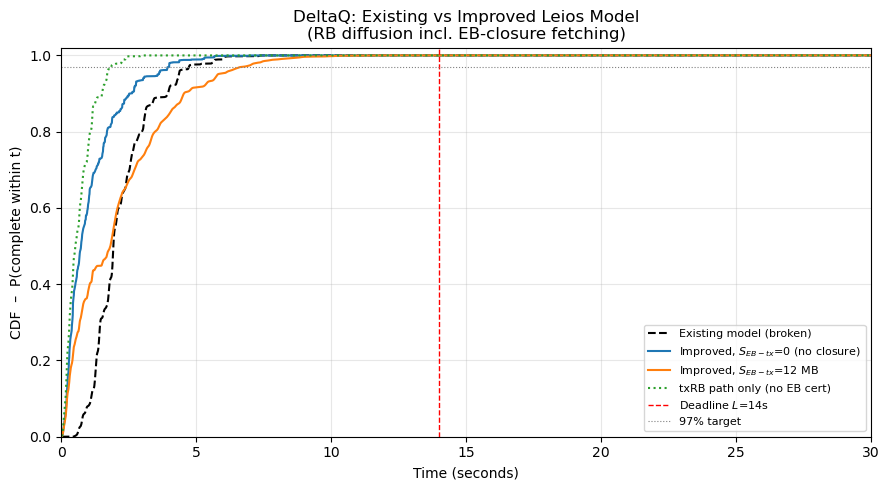

In [9]:
_N_SWEEP = 30
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))


def plot_cdf_comparison(ref_cdf, results):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(TIMES, ref_cdf, "k--", lw=1.5, label="Existing model (broken)")
    r0 = next(r for r in results if r["s_eb_tx_kb"] == 0)
    ax.plot(TIMES, r0["cdf_comb"], color="tab:blue", lw=1.5,
            label="Improved, $S_{EB-tx}$=0 (no closure)")
    r12 = next(r for r in results if r["s_eb_tx_kb"] == 12288)
    ax.plot(TIMES, r12["cdf_comb"], color="tab:orange", lw=1.5,
            label="Improved, $S_{EB-tx}$=12 MB")
    ax.plot(TIMES, r0["cdf_tx"], color="tab:green", lw=1.5, ls=":",
            label="txRB path only (no EB cert)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline $L$={int(L_DEADLINE)}s")
    ax.axhline(0.97, color="gray", ls=":", lw=0.8, label="97% target")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF  –  P(complete within t)")
    ax.set_title("DeltaQ: Existing vs Improved Leios Model\n"
                 "(RB diffusion incl. EB-closure fetching)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 30); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_cdf_comparison(ref_cdf, results_mathis)


**`compare_models`**

**What it shows.** Four CDF curves plotted on the same axis, all representing
$P(\text{RB fully processed} \leq t)$:
- *Existing model (broken)* — replicates the prior Haskell analysis.
- *Improved, $S_{EB-tx}=0$* — improved model with no EB closure (baseline).
- *Improved, $S_{EB-tx}=12\,\text{MB}$* — improved model at the CIP target size.
- *txRB path only* — the non-cert branch (RB carries transactions, no EB).

The vertical dashed red line marks the 14-second deadline; the horizontal
grey dotted line marks the 0.97 target from the prior CIP analysis.

**Why it matters.** The prior (broken) model forced *both* the certRB
and txRB paths to complete on every RB, which inflated the CDF: it
only clears the 0.97 target near ≈ 5 s under either throughput model
— read at the time as a "just-barely-feasible" ceiling at the CIP
parameters.  With the fix — mutually exclusive path choice weighted
by $P_{\text{cert}}$ — the three improved curves rise sharply and
all reach ≈ 1.0 well before the 14 s deadline: the txRB-only lower
bound by ≈ 3 s, the $S_{EB-tx}=0$ combined CDF by ≈ 7 s, and even
the 12 MB curve by ≈ 10 s.  The apparent 0.97 ceiling was therefore
an artifact of the double-path bug, not a real feasibility limit.

*Scope of this plot.* The curves show *how quickly the RB is
processed once a path is taken*, not *how often certification
succeeds*.  The Praos 50% cap ($P_{\text{cert}} \approx 0.497$)
governs whether the certRB path is chosen at all; it appears in
the `feasibility` and `certification` charts as a $P_{\text{cert}}$
plateau versus $S_{EB-tx}$, not as a CDF plateau here.


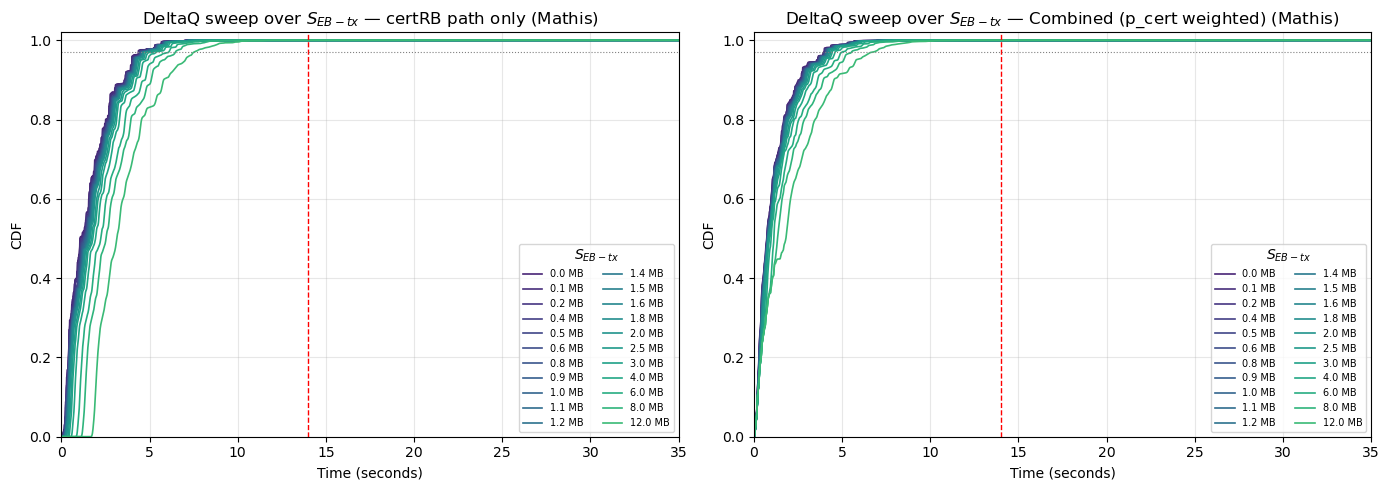

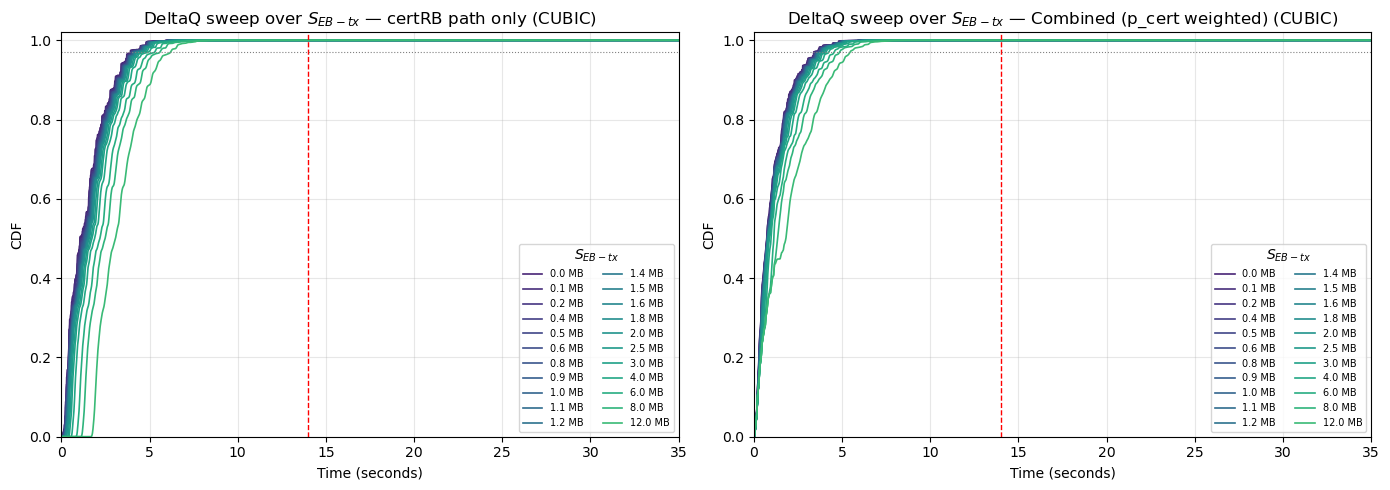

In [10]:
def plot_eb_closure_sweep(results, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1, ax2 = axes
    for i, r in enumerate(results):
        label = f"{r['s_eb_tx_kb']/1024:.1f} MB"
        ax1.plot(TIMES, r["cdf_cert"], color=COLORS[i], lw=1.2, label=label)
        ax2.plot(TIMES, r["cdf_comb"], color=COLORS[i], lw=1.2, label=label)
    for ax, title in [(ax1, "certRB path only"), (ax2, "Combined (p_cert weighted)")]:
        ax.axvline(L_DEADLINE, color="red", ls="--", lw=1)
        ax.axhline(0.97, color="gray", ls=":", lw=0.8)
        ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
        ax.set_title(f"DeltaQ sweep over $S_{{EB-tx}}$ — {title}{title_suffix}")
        ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
        ax.legend(loc="lower right", fontsize=7, title="$S_{EB-tx}$", ncol=2)
    fig.tight_layout(); plt.show()


plot_eb_closure_sweep(results_mathis, " (Mathis)")
plot_eb_closure_sweep(results_cubic, " (CUBIC)")


**`eb_closure_sweep`**

**What it shows.** A grid of CDF curves — one per simulated $S_{EB-tx}$ value
from 0 to 12 MB.  Two subplots cover (left) the certRB path CDF and (right)
the combined outcome CDF.  Curves are colour-coded by size; the vertical line
marks the 14-second deadline.

**Why it matters.** With the corrected per-tx constants and the corrected
Praos RTTs, every curve from 0 to 12 MB plateaus at $P_\text{cert} \approx
0.497$ before the 14-second deadline under both throughput models —
$P_\text{validating}$ is high enough at every CIP-target size that the
quorum is comfortably met.  No cliff appears in the plotted range under
either model.

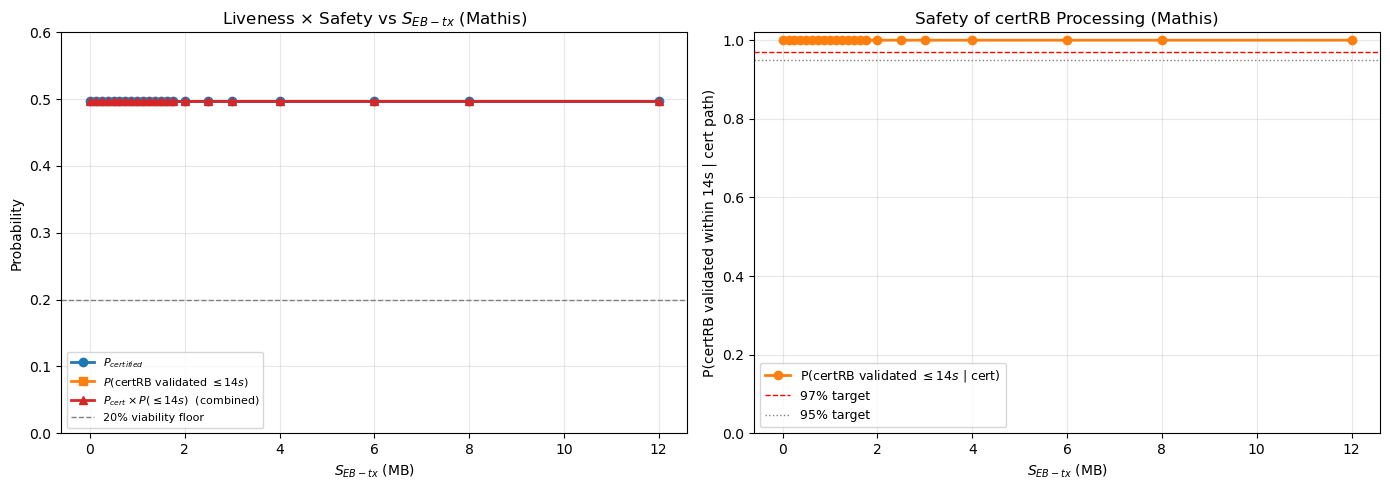

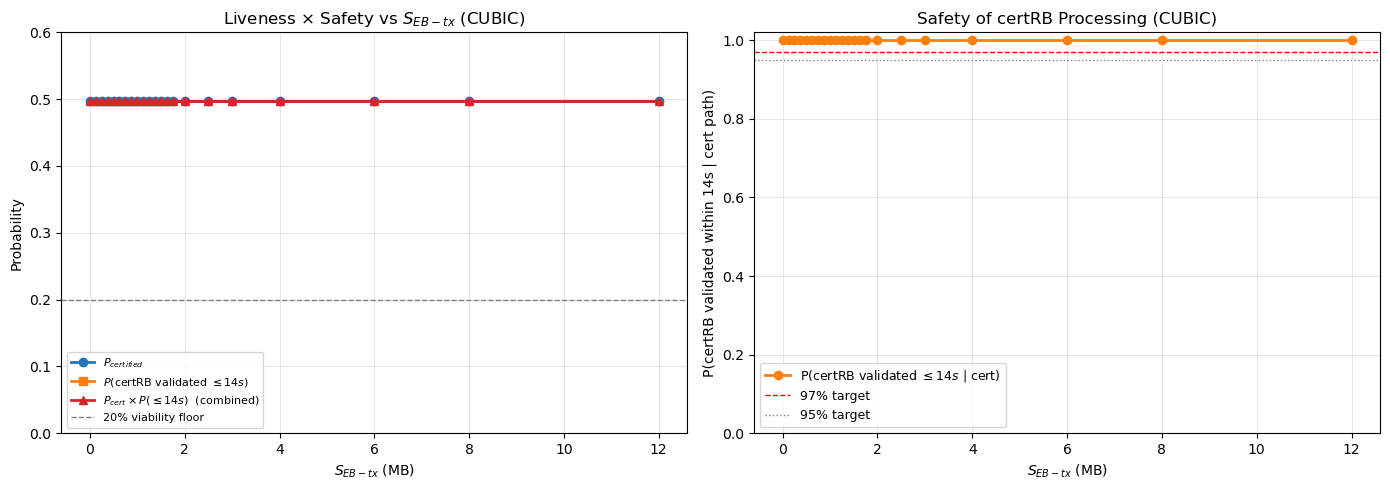

In [11]:
def plot_feasibility(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    sw_cert = [r["sw14_cert"] for r in results]
    p_c = [r["p_cert"] for r in results]
    cas = [r["p_cert_and_safe"] for r in results]
    ax1.plot(mbs, p_c, "o-", color="tab:blue", lw=2, label="$P_{certified}$")
    ax1.plot(mbs, sw_cert, "s-", color="tab:orange", lw=2,
             label="$P$(certRB validated $\\leq 14s$)")
    ax1.plot(mbs, cas, "^-", color="tab:red", lw=2,
             label="$P_{cert} \\times P(\\leq 14s)$  (combined)")
    ax1.axhline(0.20, color="gray", ls="--", lw=1, label="20% viability floor")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Liveness × Safety vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=8); ax1.set_ylim(0, 0.60); ax1.grid(True, alpha=0.3)

    ax2.plot(mbs, sw_cert, "o-", color="tab:orange", lw=2,
             label="P(certRB validated $\\leq 14s$ | cert)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.axhline(0.95, color="gray", ls=":", lw=1, label="95% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(certRB validated within 14s | cert path)")
    ax2.set_title(f"Safety of certRB Processing{title_suffix}")
    ax2.legend(fontsize=9); ax2.set_ylim(0, 1.02); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_feasibility(results_mathis, " (Mathis)")
plot_feasibility(results_cubic, " (CUBIC)")


**`feasibility`**

**What it shows.** Two subplots vs $S_{EB-tx}$:
- *Left* — three probability curves: $P_\text{cert}$ (liveness), $P(\text{certRB} \leq 14s)$ (safety), and their product $P_\text{cert} \times P(\leq 14s)$ (the combined outcome, the only quantity that matters for protocol correctness).
- *Right* — $P(\text{certRB validated} \leq 14s \mid \text{cert path})$ alone, zoomed to show whether the certRB diffusion time is a bottleneck.

**Why it matters.** Both panels stay essentially flat at $P_\text{cert}
\approx 0.497$ across the entire 0–12 MB range under either model.  The
"cert × safe" composite likewise stays at ≈ 0.497 throughout.  Confirms
the Praos cap is the only binding limit in the CIP target range — no
network-driven cliff appears under either model.

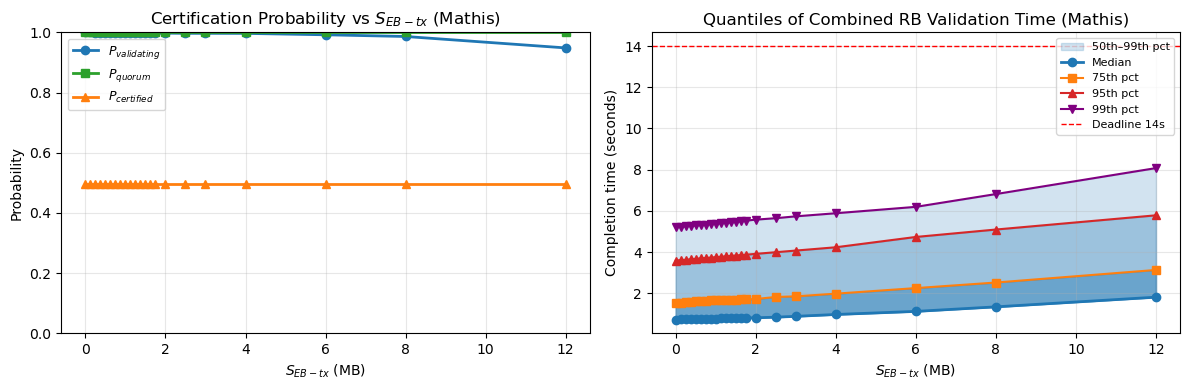

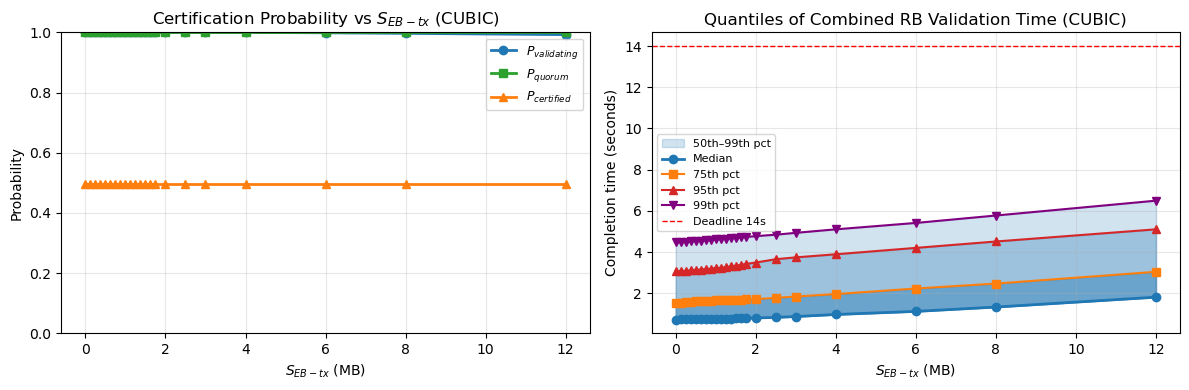

In [12]:
def plot_certification(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    p_v = [r["p_validating"] for r in results]
    p_q = [r["p_quorum"] for r in results]
    p_c = [r["p_cert"] for r in results]
    ax1.plot(mbs, p_v, "o-", color="tab:blue", lw=2, label="$P_{validating}$")
    ax1.plot(mbs, p_q, "s-", color="tab:green", lw=2, label="$P_{quorum}$")
    ax1.plot(mbs, p_c, "^-", color="tab:orange", lw=2, label="$P_{certified}$")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Certification Probability vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=9); ax1.set_ylim(0, 1.0); ax1.grid(True, alpha=0.3)

    q50 = [r["q50"] for r in results]
    q75 = [r["q75"] for r in results]
    q95 = [r["q95"] for r in results]
    q99 = [r["q99"] for r in results]
    ax2.fill_between(mbs, q50, q99, alpha=0.2, color="tab:blue", label="50th–99th pct")
    ax2.fill_between(mbs, q50, q95, alpha=0.3, color="tab:blue")
    ax2.fill_between(mbs, q50, q75, alpha=0.4, color="tab:blue")
    ax2.plot(mbs, q50, "o-", color="tab:blue", lw=2, label="Median")
    ax2.plot(mbs, q75, "s-", color="tab:orange", lw=1.5, label="75th pct")
    ax2.plot(mbs, q95, "^-", color="tab:red", lw=1.5, label="95th pct")
    ax2.plot(mbs, q99, "v-", color="purple", lw=1.5, label="99th pct")
    ax2.axhline(L_DEADLINE, color="red", ls="--", lw=1, label=f"Deadline {int(L_DEADLINE)}s")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)"); ax2.set_ylabel("Completion time (seconds)")
    ax2.set_title(f"Quantiles of Combined RB Validation Time{title_suffix}")
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_certification(results_mathis, " (Mathis)")
plot_certification(results_cubic, " (CUBIC)")


**`certification`**

**What it shows.** Two subplots vs $S_{EB-tx}$:
- *Left* — the three components of $P_\text{cert}$: $P_\text{validating}$
  (voter pipeline ≤ 7s), $P_\text{quorum}$ (stake quorum $\ge \tau$ met), and
  $P_\text{cert}$ itself.  $P_\text{interrupted}$ (≈ 0.503) is a constant cap
  annotated as a horizontal band.
- *Right* — quantiles (Q50, Q75, Q95) of the certRB completion time vs
  $S_{EB-tx}$, showing how the tail of the distribution shifts.

**Why it matters.**
- *Mathis*: $P_\text{validating}$ declines from ≈ 1.000 at 0 MB to 0.948 at
  12 MB — always well above the 0.75 quorum threshold.  $P_\text{quorum}
  \approx 1.0$ throughout; $P_\text{cert}$ stays at the Praos cap.
- *CUBIC*: $P_\text{validating}$ declines from ≈ 1.000 at 0 MB to 0.992 at
  12 MB.  Same conclusion: $P_\text{cert}$ at the Praos cap.

The right panel (Q50/Q75/Q95 quantiles) shows slowly increasing tails as
closure size grows in both models, driven by the longer voter pipeline.

### 5.2 Network Diffusion of the EB Closure

With CPU no longer the binding constraint, network diffusion is the primary
bottleneck.  Two scenarios are distinguished — both reported under each model.

**1-hop approximation** (voter path in §5.1): each cache-miss node fetches only
the missing fraction ($\pi_1 \cdot S_{EB-tx} \approx S_{EB-tx}/6$) from its
upstream peer over a single hop.

| $S_{EB-tx}$ | Missing ($\pi_1 \cdot S$) | $P_{\text{validating}}$ Mathis | $P_{\text{validating}}$ CUBIC |
|-------------|--------------------------|-------------------------|------------------------|
| 1.0 MB      | 171 kB                   | 0.998                   | 1.000                  |
| 4.0 MB      | 683 kB                   | 0.996                   | 1.000                  |
| 8.0 MB      | 1.33 MB                  | 0.986                   | 0.997                  |
| 12.0 MB     | 2.0 MB                   | **0.948**               | **0.992**              |

Both models stay well above the 0.75 quorum threshold across the full range,
so $P_{\text{quorum}} \approx 1$ and $P_{\text{cert}}$ stays at the Praos cap.

**Full blended diffusion** (worst case — transactions not pre-diffused; the
entire $S_{EB-tx}$ must traverse the blended multi-hop network):

| $S_{EB-tx}$ | P(full diffusion ≤ 14s) Mathis | P(full diffusion ≤ 14s) CUBIC |
|-------------|--------------------------------|-------------------------------|
| 1.0 MB      | 1.000                          | 1.000                         |
| 2.0 MB      | 0.957                          | 1.000                         |
| 4.0 MB      | 0.615                          | 1.000                         |
| 8.0 MB      | 0.230                          | 1.000                         |
| 12.0 MB     | **0.139**                      | **0.991**                     |

The two columns bracket the realistic operating regime.  Under Mathis the
worst-case scenario at 12 MB is still poor (network delivers within 14 s only
14% of the time); under CUBIC the network is essentially never the limiting
factor (99% deliver within 14 s).  Either way, the 1-hop approximation is
**load-bearing** for the main results: it is only justified if the raw
transactions referenced by the EB body have already diffused via
tx-submission *before* the EB is produced.  In Linear Leios (where
transactions diffuse solely via the tx-submission miniprotocol) this
typically holds under normal operation, but is not guaranteed under
adversarial conditions or heavy mempool load.  The full $P_{\text{cert}}$ under the full-blended worst case is derived in
§5.3 "Full-blended worst case"
and is ≈ 0 under both models (the bottleneck
shifts from network delivery to the tighter 7 s voter deadline and the 75%
quorum threshold).

The cells below compute and plot the per-model CDFs.


In [13]:
def run_network_diffusion():
    """
    Compute network-only diffusion time for the EB closure under two models:
      (a) 1-hop approximation: node fetches only the missing fraction (π₁·S_EB_tx)
          from its upstream peer (one hop).  Justified if the raw transactions
          referenced by the EB have already diffused via tx-submission before
          the EB is produced.  (Linear Leios has no Input Blocks; transactions
          diffuse solely via tx-submission.)
      (b) Full blended diffusion: the entire S_EB_tx must traverse the blended
          multi-hop network (worst case: transactions not pre-diffused).

    CPU reapplication is NOT included – this isolates the network constraint.
    """
    sweep_kb = [512, 1024, 1536, 2048, 4096, 8192, 12288]

    rows = []
    for s_kb in sweep_kb:
        miss_kb = TX_CACHE_MISS_RATE * s_kb  # π₁ · S_EB_tx

        # (a) 1-hop for missing fraction
        net_1hop = cdf_sequential(cdf_fetch_eb_body(), cdf_hop(miss_kb))
        # (b) blended multi-hop for missing fraction
        net_miss_blended = cdf_sequential(
            cdf_fetch_eb_body(), cdf_blended_delay(miss_kb)
        )
        # (c) full closure blended (no 1-hop shortcut)
        net_full_blended = cdf_blended_delay(s_kb)

        rows.append(
            dict(
                s_kb=s_kb,
                net_1hop=net_1hop,
                net_miss_blend=net_miss_blended,
                net_full_blend=net_full_blended,
                sw7_1hop=success_within(net_1hop, 7.0),
                sw7_miss_blend=success_within(net_miss_blended, 7.0),
                sw14_full=success_within(net_full_blended, 14.0),
                sw7_full=success_within(net_full_blended, 7.0),
            )
        )
    return rows


/tmp/nix-shell.vWLPRm/nix-shell.Do6p8f/ipykernel_170691/1540215392.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "v-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",


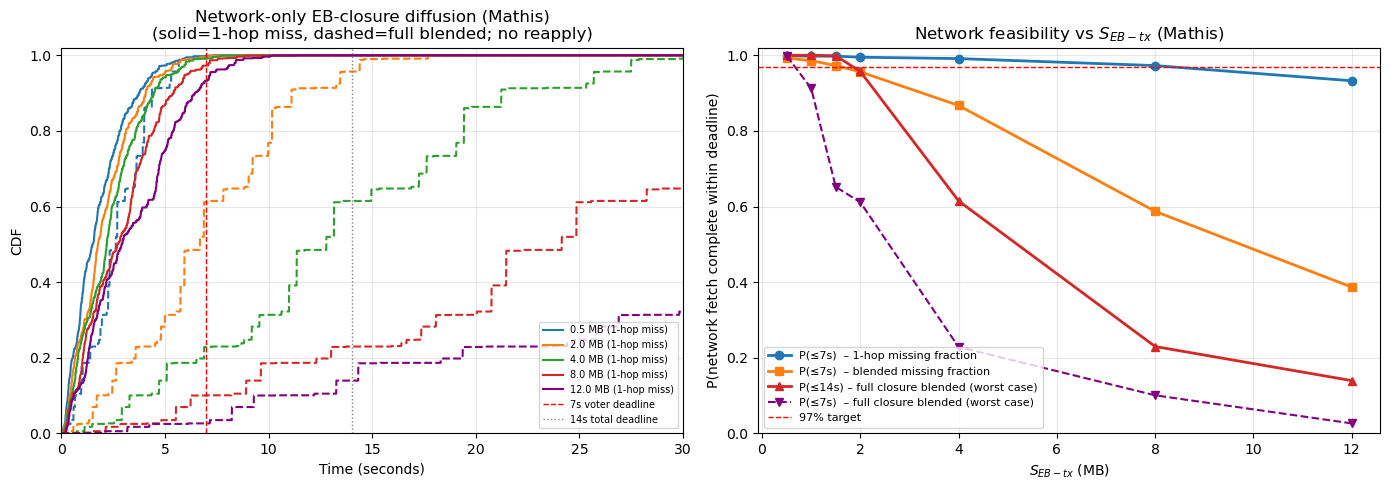

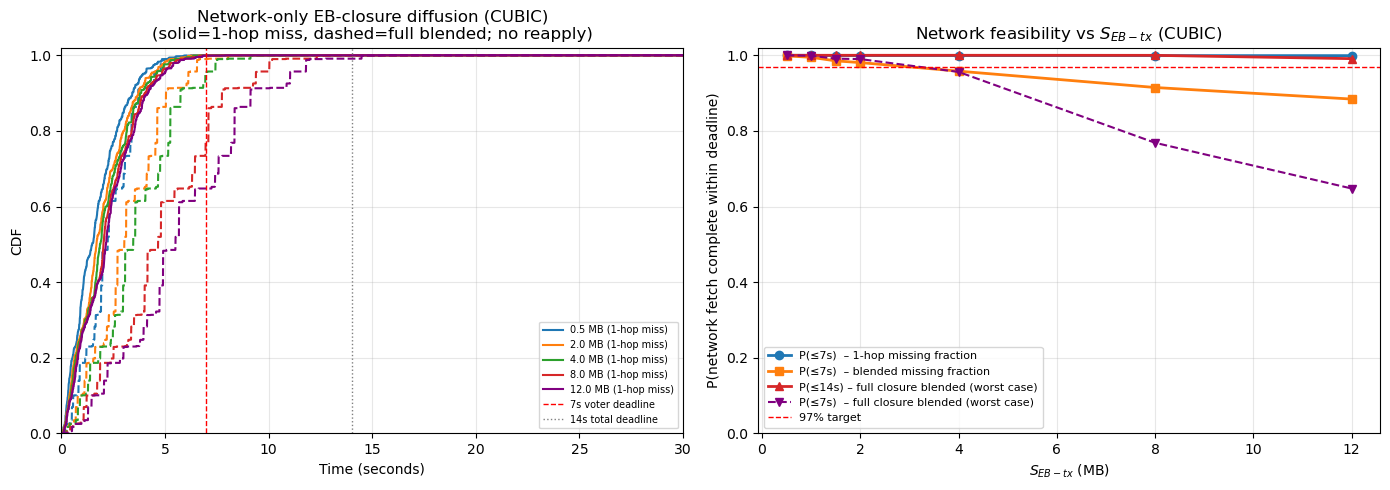

In [14]:
def plot_network_diffusion(rows, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    highlight = [512, 2048, 4096, 8192, 12288]
    colors_h = ["tab:blue", "tab:orange", "tab:green", "tab:red", "purple"]
    for row, col in zip([r for r in rows if r["s_kb"] in highlight], colors_h):
        lbl = f"{row['s_kb']/1024:.1f} MB"
        ax1.plot(TIMES, row["net_1hop"], color=col, lw=1.5, ls="-",
                 label=f"{lbl} (1-hop miss)")
        ax1.plot(TIMES, row["net_full_blend"], color=col, lw=1.5, ls="--")
    ax1.axvline(7.0, color="red", ls="--", lw=1, label="7s voter deadline")
    ax1.axvline(14.0, color="gray", ls=":", lw=1, label="14s total deadline")
    ax1.set_xlabel("Time (seconds)"); ax1.set_ylabel("CDF")
    ax1.set_title(f"Network-only EB-closure diffusion{title_suffix}\n"
                 "(solid=1-hop miss, dashed=full blended; no reapply)")
    ax1.legend(fontsize=7, loc="lower right")
    ax1.set_xlim(0, 30); ax1.set_ylim(0, 1.02); ax1.grid(True, alpha=0.3)

    mbs = [r["s_kb"] / 1024 for r in rows]
    ax2.plot(mbs, [r["sw7_1hop"] for r in rows], "o-", color="tab:blue", lw=2,
             label="P(≤7s)  – 1-hop missing fraction")
    ax2.plot(mbs, [r["sw7_miss_blend"] for r in rows], "s-", color="tab:orange",
             lw=2, label="P(≤7s)  – blended missing fraction")
    ax2.plot(mbs, [r["sw14_full"] for r in rows], "^-", color="tab:red",
             lw=2, label="P(≤14s) – full closure blended (worst case)")
    ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",
             lw=1.5, ls="--", label="P(≤7s)  – full closure blended (worst case)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(network fetch complete within deadline)")
    ax2.set_title(f"Network feasibility vs $S_{{EB-tx}}${title_suffix}")
    ax2.legend(fontsize=8, loc="lower left"); ax2.set_ylim(0, 1.02)
    ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


set_network_model("mathis"); net_mathis = run_network_diffusion()
plot_network_diffusion(net_mathis, " (Mathis)")

set_network_model("cubic"); net_cubic = run_network_diffusion()
plot_network_diffusion(net_cubic, " (CUBIC)")


**`network_diffusion`**

**What it shows.** A network-only (CPU excluded) analysis across $S_{EB-tx}$
values from 0.5 MB to 12 MB, split into two panels.

- *Left panel (per-size CDFs):* for each highlighted closure size,
  two $P(\le t)$ curves are plotted — **1-hop fetch of missing
  fraction** (EB body + 1-hop, solid) and **full blended diffusion
  of the entire closure** (dashed).  The 7 s voter deadline and
  14 s total deadline are annotated.
- *Right panel (sweep over $S_{EB-tx}$):* four aggregate trace
  lines vs closure size — $P(\le 7s)$ for 1-hop missing, $P(\le 7s)$
  for blended missing, $P(\le 14s)$ for full blended, and $P(\le 7s)$
  for full blended.  A 97% target line is overlaid.

**Why it matters.** This plot answers the question "even if the CPU
were infinitely fast, could the network deliver the closure in time?"
The curves assume *every* voter must fetch (i.e. treat all voters as
cache-miss); this is therefore strictly more conservative than the
§5.1 voter pipeline, where 5/6 of voters are cache-hits
with a near-zero lookup.
- *Mathis*: full-blended at 12 MB gives $P(\leq 14\,\text{s}) = 0.139$ —
  the network delivers only 14% of the time under the worst-case
  no-pre-diffusion assumption.  The 1-hop scenario at 12 MB gives
  $P(\leq 7\,\text{s}) \approx 0.933$ (essentially feasible).
- *CUBIC*: full-blended at 12 MB gives $P(\leq 14\,\text{s}) = 0.991$ —
  essentially feasible even without pre-diffusion.  1-hop at 12 MB gives
  $P(\leq 7\,\text{s}) \approx 0.999$.

The 1-hop scenario is feasible under either model at every CIP-target
size.  The full-blended worst case still distinguishes the models —
Mathis fails, CUBIC succeeds on the network delivery alone — but the
voter pipeline plus quorum threshold still makes the full-blended case
effectively infeasible under both models (see §5.3 "Full-blended worst
case").

### 5.3 Sensitivity: 1-hop vs Multi-hop EB Closure Fetch (voter path)

For every CIP-target size up to 12 MB, the 1-hop and blended-missing
multi-hop models both give $P_{\text{cert}}$ at the Praos cap ≈ 0.497 under
either throughput model — the missing-closure fetch ($\pi_1 \cdot S$, up to
2 MB at 12 MB for $\pi_1 = 1/6$) is small enough to complete in time even
over multi-hop paths.  At 12 MB, **with $\pi_1 = 1/6$** (the conservative
prior-Haskell default; §5.5 sweeps $\pi_1$ explicitly, and the empirical
mean $\pi_1 \approx 0.06$ would shrink the missing fraction to 0.72 MB
and push both rows higher):

| Scenario | Mathis $P_{\text{validating}}$ | Mathis $P_{\text{cert}}$ | CUBIC $P_{\text{validating}}$ | CUBIC $P_{\text{cert}}$ |
|----------|:-:|:-:|:-:|:-:|
| 1-hop missing (default) | 0.948 | 0.497 | 0.992 | 0.497 |
| Blended-missing | 0.854 | 0.497 | 0.942 | 0.497 |

The blended-missing case lowers $P_{\text{validating}}$ by ~10 percentage
points under both models, but both stay well above the 0.75 quorum threshold,
so $P_{\text{cert}}$ is unchanged — the Praos cap continues to bind, not
quorum.  The 1-hop vs blended-missing distinction is therefore *not* what
determines feasibility in the realistic-RTT regime; it would only matter
near $\pi_1 \cdot S \approx W_{\text{ss}}$ or with substantially longer RTTs.

The cell below reproduces the per-model CDF comparison at $S_{EB-tx}$ = 12 MB.


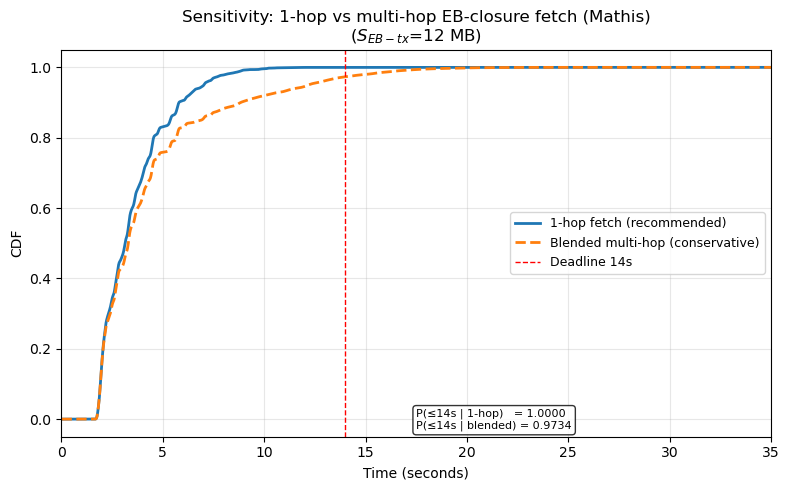

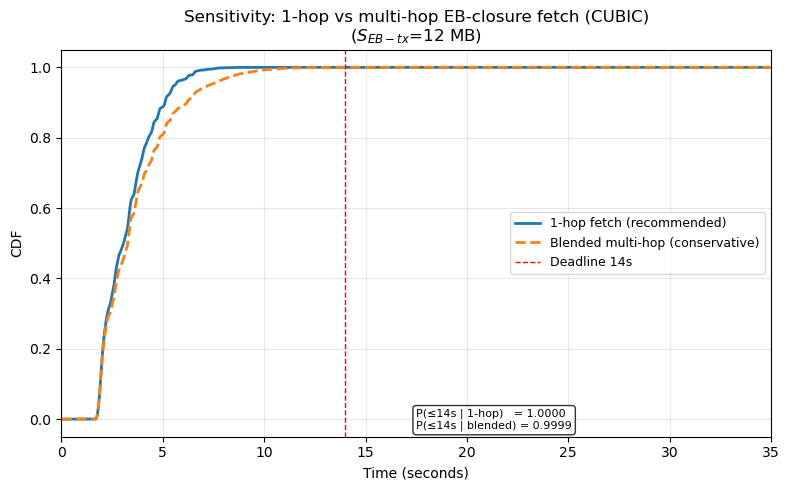

Mathis: {'1hop_sw14': 0.9999984110653873, 'blended_sw14': 0.9734374657658752}
CUBIC : {'1hop_sw14': 0.9999999999999983, 'blended_sw14': 0.9999449394092493}


In [15]:
def sensitivity_1hop_vs_blended(title_suffix=""):
    """Compare 1-hop vs blended-delay for missing EB closure fetching,
    under the eager non-voter model."""
    s_kb = 12288  # === edit: switch to a smaller closure to see the gap shrink ===

    # 1-hop (default) — non-voter pre-fetch pipeline in parallel with
    # certRB body fetch, then verify cert.
    cert_1hop = cdf_process_cert_rb(s_kb)

    # Blended-missing variant: missing-closure fetch uses blended
    # multi-hop instead of 1-hop.  Rebuild the pre-fetch pipeline with
    # the blended fetch step in place of the 1-hop step.
    eb_body = cdf_fetch_eb_body()
    missing_kb = TX_CACHE_MISS_RATE * s_kb
    blended_miss_fetch = cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001),
                                    cdf_blended_delay(missing_kb))
    pre_fetch_blended = cdf_sequential(
        cdf_sequential(eb_body, blended_miss_fetch), reapply_txs_cdf(s_kb)
    )
    cert_rb = cdf_fetch_cert_rb_body()
    cert_blended = cdf_last_to_finish(pre_fetch_blended, cert_rb)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(TIMES, cert_1hop, lw=2, label="1-hop fetch (recommended)")
    ax.plot(TIMES, cert_blended, lw=2, ls="--",
            label="Blended multi-hop (conservative)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline {int(L_DEADLINE)}s")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(f"Sensitivity: 1-hop vs multi-hop EB-closure fetch{title_suffix}\n"
                 f"($S_{{EB-tx}}$={s_kb/1024:.0f} MB)")
    ax.legend(fontsize=9); ax.set_xlim(0, 35); ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.02,
            f"P(≤14s | 1-hop)   = {success_within(cert_1hop,14):.4f}\n"
            f"P(≤14s | blended) = {success_within(cert_blended,14):.4f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    fig.tight_layout(); plt.show()
    return {"1hop_sw14": success_within(cert_1hop, 14.0),
            "blended_sw14": success_within(cert_blended, 14.0)}


set_network_model("mathis"); sens_mathis = sensitivity_1hop_vs_blended(" (Mathis)")
set_network_model("cubic"); sens_cubic = sensitivity_1hop_vs_blended(" (CUBIC)")
print("Mathis:", sens_mathis); print("CUBIC :", sens_cubic)


**`sensitivity_1hop_vs_blended`**

**What it shows.** CDF curves for the full certRB-path pipeline at
$S_{EB-tx} = 12\,\text{MB}$, under two assumptions about how missing
transactions are fetched:
- *1-hop* — each node fetches only the missing fraction ($\pi_1 \cdot S$)
  from its upstream peer (1 network hop).
- *Blended* — missing transactions must traverse the full blended multi-hop
  network model.

**Why it matters.**
- *Mathis*: 1-hop and blended both give $P_\text{cert} = 0.497$ (Praos
  cap).  $P_\text{validating}$ drops from 0.948 (1-hop) to 0.854
  (blended) but stays above the quorum threshold.
- *CUBIC*: 1-hop and blended both give $P_\text{cert} = 0.497$.
  $P_\text{validating}$ drops from 0.992 (1-hop) to 0.942 (blended).

The 1-hop vs blended-missing distinction is not feasibility-relevant in
the 0–12 MB range: both pathways succeed.  The plot confirms the
small-but-real $P_\text{validating}$ gap between 1-hop and blended
without it changing the certification outcome.

#### Full-blended worst case (catastrophic pre-diffusion failure)

The two scenarios above (1-hop and blended of the *missing fraction*
$\pi_1 \cdot S$) both assume that the voter is missing only a small fraction
of the closure — they reflect normal mempool-fragmentation dynamics.  A
strictly worse scenario is **total pre-diffusion failure**: tx-submission
hasn't worked at all, every voter is missing the *entire* closure, and the
full $S_{EB-tx}$ must traverse the blended multi-hop network.  At
$S_{EB-tx} = 12$ MB:

| Quantity | Mathis (full-blended) | CUBIC (full-blended) |
|----------|:-:|:-:|
| Network-only $P(\text{12 MB} \leq 7\text{s})$  | 2.6%   | 64.8% |
| Network-only $P(\text{12 MB} \leq 14\text{s})$ | 13.9%  | 99.1% |
| $P_{\text{validating}}$ (voter pipeline ≤ 7 s)   | 0.017  | 0.306 |
| $P_{\text{quorum}}$                              | ≈ 0    | ≈ 0   |
| $P_{\text{cert}}$                                | ≈ 0    | ≈ 0   |

CUBIC's 99% "delivers within 14 s" is misleading on its own — it doesn't
carry over to $P_{\text{cert}}$, for two compounding reasons:

1. **Voter deadline is 7 s, not 14 s.**  Only 65% of CUBIC blended
   12 MB transfers finish within 7 s (median ≈ 5.5 s), and the full
   voter pipeline (which adds EB body fetch and CPU on top) pushes
   $P_{\text{validating}}$ down to 0.31.
2. **The 75% stake-quorum threshold dwarfs $P_{\text{validating}}$.**  With
   only ≈ 31% of the committee stake weight on time versus the
   $\tau/\sigma_c \approx 0.758$ requirement, $P_{\text{quorum}}$ collapses
   to ≈ 0 even under CUBIC.

**Combining the two regimes.**  Realistic operation is a mixture, not a
strict either/or:

$$P_{\text{cert,effective}} = \alpha \cdot P_{\text{cert,1-hop}} + (1-\alpha) \cdot P_{\text{cert,full-blended}}
\approx \alpha \cdot P_{\text{cert,1-hop}}$$

where $\alpha$ is the probability that tx-submission pre-diffusion is
operating normally (i.e. *not* in a catastrophic-failure regime).  Since
$P_{\text{cert,full-blended}} \approx 0$, the effective $P_{\text{cert}}$ scales linearly
with $\alpha$.  For CUBIC at 12 MB:

| $\alpha$ | Interpretation | Effective $P_{\text{cert}}$ |
|--------|----------------|:-:|
| 0.99   | Pre-diffusion almost always works | 0.49 |
| 0.95   | One-in-twenty rounds catastrophic | 0.47 |
| 0.90   | One-in-ten rounds catastrophic    | 0.45 |
| 0.50   | Half-time catastrophic            | 0.25 |

(The 1-hop $P_{\text{cert}}$ at 12 MB is ≈ 0.497 under both Mathis and CUBIC,
so the same table applies to both models.)

**Out of scope:** estimating $\alpha$ empirically.  $\alpha$ is a
system-availability question (about the tx-submission mini-protocol's
reliability under load and adversarial conditions), not a network-model
question.  It is conceptually distinct from $\pi_1$: the empirical
$\pi_1 \approx 0.06$ measures typical per-transaction mempool divergence
during *normal* operation, while $\alpha < 1$ would represent the rate of
operationally-anomalous rounds where tx-submission has *failed* outright.
Under normal operation $\alpha \to 1$ and the headline $P_{\text{cert}}$ at the 1-hop
result (≈ 0.497 under either model) is the appropriate value; quantifying
$\alpha$ during incidents requires operational data this analysis does not
have.

#### Maximum feasible closure when 1-hop fails (per $\pi_1$)

The intermediate regime — "1-hop fails for some voters, but the producer
itself has the txs (so full-blended is not required)" — is the most
operationally relevant question: given a realistic $\pi_1$, what is the
largest closure size still feasible if each voter's missing fraction has
to come through the blended multi-hop network?

For each $\pi_1$ in 0.05 increments, find the largest closure $S$ such that
the full voter pipeline (EB body blended + missing-fraction $\pi_1 \cdot S$
blended + CPU reapply/apply) completes within 7 s with probability ≥ 0.75
(matching the quorum threshold):

| $\pi_1$ | Mathis $S_{\text{max}}$ | CUBIC $S_{\text{max}}$ | "naive" $S = X / \pi_1$ |
|--------:|----------------------:|---------------------:|-------------------------|
| 0.05    | **12.3 MB**           | **24.4 MB**          | M 25 MB / C 161 MB      |
| 0.10    | 7.1 MB                | 12.9 MB              | M 13 MB / C 81 MB       |
| 0.15    | 5.0 MB                | 10.1 MB              | M 8.3 MB / C 54 MB      |
| 0.20    | 3.9 MB                | 8.2 MB               | M 6.3 MB / C 40 MB      |
| 0.25    | 3.2 MB                | 6.9 MB               | M 5.0 MB / C 32 MB      |
| 0.30    | 2.7 MB                | 6.0 MB               | M 4.2 MB / C 27 MB      |
| 0.35    | 2.3 MB                | 5.3 MB               | M 3.6 MB / C 23 MB      |
| 0.40    | 2.0 MB                | 4.7 MB               | M 3.1 MB / C 20 MB      |
| 0.45    | 1.8 MB                | 4.3 MB               | M 2.8 MB / C 18 MB      |
| 0.50    | 1.6 MB                | 3.9 MB               | M 2.5 MB / C 16 MB      |

(where $X$ = max single-payload bytes such that blended diffusion alone
hits the 7 s deadline at the 75th percentile: $X = 1.25$ MB Mathis,
$X = 8.1$ MB CUBIC.  The CPU step uses the swept $\pi_1$ in
$\mu_{\text{eff}} = \pi_1 \mu_{\text{apply}} + (1{-}\pi_1) \mu_{\text{reapply}}$,
so per-tx cost rises with $\pi_1$.)

**The naive formula $S = X / \pi_1$ overstates feasibility by ~1.5–2×
under Mathis and ~4–7× under CUBIC** across the swept range.  It counts
only the missing-fraction fetch step; the actual voter pipeline also
spends:

- ~1–3 s on the **EB body fetch** (blended multi-hop, payload up to 512 kB
  in the generic model — a fat-tailed distribution that costs several
  seconds at the 75th percentile).
- $N \cdot \mu_{\text{eff}}$ on **CPU reapply/apply**, where
  $\mu_{\text{eff}}$ grows from 0.092 ms/tx at $\pi_1 = 0.05$ to 0.289 ms/tx
  at $\pi_1 = 0.50$.  At $\pi_1 = 0.50$ and $S = 4$ MB this CPU step alone
  is $\approx 1.15$ s.

These overheads consume a substantial fraction of the 7 s budget *before*
the missing-fraction fetch even starts, leaving much less than $X$ for the
$\pi_1 \cdot S$ transfer.  The naive-vs-realistic ratio is *largest* at
small $\pi_1$, where the larger feasible $S$ produces a heavier CPU step
and a larger absolute EB-body overhead relative to a budget that the
naive formula treats as all-fetch.

**What this means practically.**

- **At the empirical mean $\pi_1 \approx 0.06$**: under the blended-missing
  case the max feasible closure is ≈ **11 MB Mathis, 20 MB CUBIC**.  CUBIC
  comfortably exceeds the 12 MB CIP target; Mathis sits just below it.
- **At the empirical worst-pair $\pi_1 \approx 0.085$**: max feasible
  is ≈ **8 MB Mathis, 14 MB CUBIC**.  CUBIC still exceeds 12 MB;
  Mathis falls short.
- **At $\pi_1 = 1/6 \approx 0.17$ (the prior Haskell model's default)**:
  max feasible drops to ≈ **4.6 MB Mathis, 9.4 MB CUBIC** — both
  models fall short of the 12 MB target.
- **At $\pi_1 \geq 0.30$**: max feasible is ≈ **2.7 MB Mathis, 6 MB CUBIC**
  — well short of the 12 MB target under either model.

Combined with the §5.1 1-hop headline (12 MB at the Praos cap under both
models for empirical $\pi_1$), the picture is: under the **1-hop**
approximation the 12 MB CIP target is robustly feasible under both
models, but if the missing fetch falls back to **blended multi-hop**, only
CUBIC retains comfortable headroom (≈ 20 MB at $\pi_1 \approx 0.06$,
≈ 14 MB at $\pi_1 \approx 0.085$) — Mathis sits at or just below
12 MB across the empirical range, and both models fall short once
$\pi_1$ rises to the prior Haskell model's default of 1/6.
The 1-hop fetch path (the upstream peer holds the missing transactions
locally) is therefore an important operational invariant, separate from
the stronger pre-diffusion-failure scenario covered by the full-blended
case above.


### 5.4 Network Model Sensitivity (Mathis vs CUBIC vs loss rate)

Quantify how each throughput model responds to packet loss $p$, and where the
2 MB long-haul fetch crosses the 7 s voter deadline.

| Throughput model | $p$ at which 2 MB long-haul = 7 s |
|------------------|-----------------------------------|
| Mathis           | $\approx 2.8 \times 10^{-4}$      |
| CUBIC            | $\approx 4.6 \times 10^{-3}$      |

Below each $p$ value, the missing-closure fetch finishes in time and the
quorum holds at 12 MB.  Above, $P_{\text{validating}}$ drops below 0.75 and
the quorum cliff appears.  The analysis default $p = 10^{-4}$ lies **well
below both** crossings: the cliff is absent under both Mathis and CUBIC,
with substantial margin.


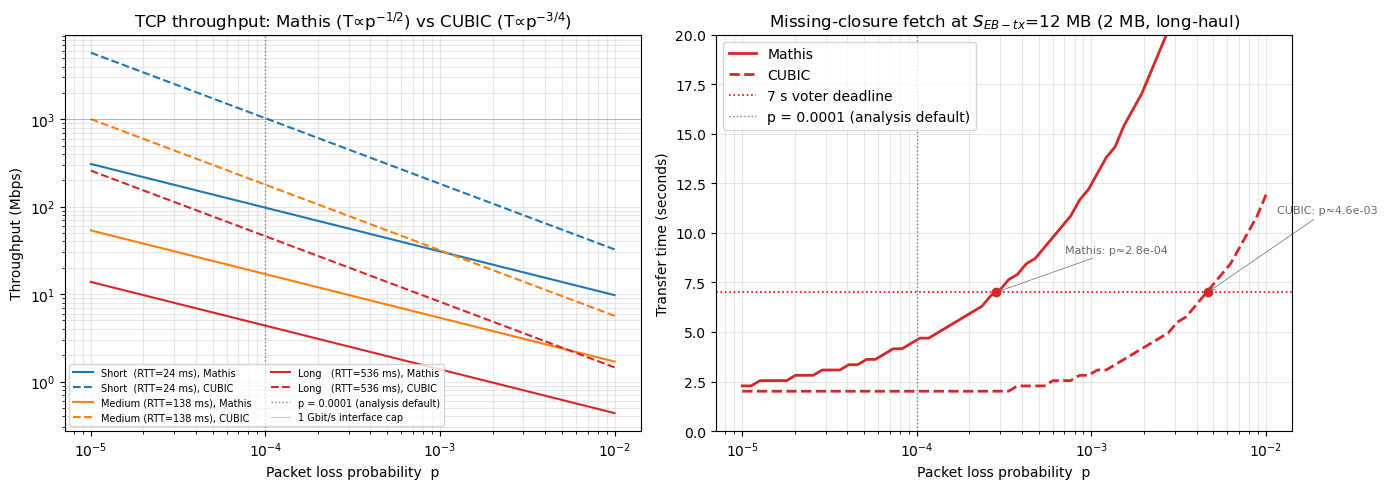

In [16]:
def plot_network_model_comparison():
    p_grid = np.logspace(-5, -2, 60)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    distances = [
        ("Short  (RTT=24 ms)",  _OWD_SHORT_S, "tab:blue"),
        ("Medium (RTT=138 ms)", _OWD_MED_S,   "tab:orange"),
        ("Long   (RTT=536 ms)", _OWD_LONG_S,  "tab:red"),
    ]
    for label, owd, color in distances:
        rtt = 2.0 * owd
        T_m = np.array([_steady_state_window("mathis", p) / rtt * 8 / 1e6 for p in p_grid])
        T_c = np.array([_steady_state_window("cubic", p)  / rtt * 8 / 1e6 for p in p_grid])
        ax1.loglog(p_grid, T_m, "-",  color=color, lw=1.5, label=f"{label}, Mathis")
        ax1.loglog(p_grid, T_c, "--", color=color, lw=1.5, label=f"{label}, CUBIC")
    ax1.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    ax1.axhline(1e3, color="black", ls="-", lw=0.5, alpha=0.3,
                label="1 Gbit/s interface cap")
    ax1.set_xlabel("Packet loss probability  p"); ax1.set_ylabel("Throughput (Mbps)")
    ax1.set_title("TCP throughput: Mathis (T∝p$^{-1/2}$) vs CUBIC (T∝p$^{-3/4}$)")
    ax1.grid(alpha=0.3, which="both"); ax1.legend(fontsize=7, loc="lower left", ncol=2)

    t_m = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "mathis", p) for p in p_grid])
    t_c = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "cubic", p)  for p in p_grid])
    ax2.semilogx(p_grid, t_m, "-",  color="tab:red", lw=2, label="Mathis")
    ax2.semilogx(p_grid, t_c, "--", color="tab:red", lw=2, label="CUBIC")
    ax2.axhline(7.0, color="red", ls=":", lw=1.2, label="7 s voter deadline")
    ax2.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    # Highlight where each model crosses the 7s deadline.  Compute the
    # crossing on a separate fine grid (so it matches §5.4's table to
    # displayed precision and isn't biased by the visible curve's
    # coarser sampling, which is intentionally undersampled to look
    # smooth despite the step structure of _tcp_transfer_time).
    p_fine = np.logspace(-5, -2, 6000)
    for fn_name, name in [("mathis", "Mathis"), ("cubic", "CUBIC")]:
        t_fine = np.array(
            [_tcp_transfer_time(2048, _OWD_LONG_S, fn_name, p) for p in p_fine]
        )
        idx = int(np.searchsorted(t_fine, 7.0))
        if 0 < idx < len(p_fine):
            t0, t1 = t_fine[idx - 1], t_fine[idx]
            p0, p1 = p_fine[idx - 1], p_fine[idx]
            if t1 > t0:
                frac = (7.0 - t0) / (t1 - t0)
                p_cross = p0 * (p1 / p0) ** frac  # log-linear interp
            else:
                p_cross = p_fine[idx]
            ax2.plot(p_cross, 7.0, "o", color="tab:red", ms=6)
            ax2.annotate(f"{name}: p≈{p_cross:.1e}",
                         xy=(p_cross, 7.0),
                         xytext=(p_cross*2.5, 9 if name=="Mathis" else 11),
                         fontsize=8, color="dimgray",
                         arrowprops=dict(arrowstyle="->", color="dimgray", lw=0.5))
    ax2.set_ylim(0, 20)
    ax2.set_xlabel("Packet loss probability  p"); ax2.set_ylabel("Transfer time (seconds)")
    ax2.set_title("Missing-closure fetch at $S_{EB-tx}$=12 MB (2 MB, long-haul)")
    ax2.grid(alpha=0.3, which="both"); ax2.legend(loc="upper left")
    fig.tight_layout(); plt.show()


plot_network_model_comparison()


**`network_model_comparison` *(top-level, both models)***

**What it shows.** Two panels, side by side:
- *Left* — steady-state TCP throughput vs packet-loss probability $p$, plotted
  on log–log axes for each of the three distance categories under both Mathis
  ($T \propto p^{-1/2}$, solid) and CUBIC ($T \propto p^{-3/4}$, dashed).
  The 1 Gbit/s interface cap and the analysis default $p = 10^{-4}$ are marked.
- *Right* — transfer time for a 2 MB long-haul (OWD = 268 ms) fetch vs $p$
  (semilog), with the 7 s voter deadline marked.  This is the
  missing-closure load at $S_{EB-tx} = 12$ MB.  Annotation arrows show
  approximately where each model crosses the deadline.

**Why it matters.** Quantifies how much loss-rate headroom each model has
before hitting the 7 s deadline.  The 2 MB fetch hits the 7 s deadline at
$p \approx 2.8 \times 10^{-4}$ under Mathis and $\approx 4.6 \times 10^{-3}$
under CUBIC — both *above* the analysis default of $10^{-4}$, so the
12 MB cliff is absent under either model at default $p$.  Mathis tolerates
~2.8× higher loss before falling off the cliff; CUBIC tolerates ~46×.

#### Caveats common to both models

Several real-world effects are *not* captured by either steady-state
throughput equation and may matter more than the Mathis-vs-CUBIC distinction:

1. **Receiver window (rwnd) and BDP.**  Effective throughput is bounded by
   $\min(W_{\text{cwnd}}, W_{\text{rwnd}})/\text{RTT}$.  Linux default rwnd is
   4–16 MB after autotuning, comfortably above either model's steady-state
   $W_{\text{cwnd}}$ at $p = 10^{-4}$ — but a freshly opened connection or a
   long-idle one may start with a much smaller rwnd that lags the
   congestion-control prediction.

2. **Slow start is modeled, but real-world TCP exhibits additional effects
   this model omits.**  The diffusion-time table *does*
   simulate slow start explicitly: cwnd starts at 10 MSS
   ($14{,}600$ B) and doubles each RTT until it hits the model-specific cap
   $W_{\text{ss}}$, identically under both Mathis and CUBIC.  The model choice
   therefore only changes the transfer time once the connection has *cleared*
   slow start.  Tracing the cwnd-doubling sequence from this starting point
   (values in bytes; kiB = 1024 B; "—" = same as Mathis column):

   | Round | Mathis cwnd | Mathis cum sent | Mathis status | CUBIC cwnd | CUBIC cum sent | CUBIC status |
   |-------|-------------|-----------------|---------------|------------|----------------|--------------|
   | 1     | 14 600      | 14 600          | slow start    | —          | —              | slow start   |
   | 2     | 29 200      | 43 800          | slow start    | —          | —              | slow start   |
   | 3     | 58 400      | 102 200         | slow start    | —          | —              | slow start   |
   | 4     | 116 800     | **219 000**     | slow start    | —          | **219 000**    | slow start   |
   | 5     | **146 000** (capped) | 365 000 | **capped**   | 233 600 (160 MSS) | 452 600 | slow start   |
   | 6     | 146 000     | 511 000         | steady state  | 467 200    | 919 800        | slow start   |
   | 7     | 146 000     | 657 000         | steady state  | 934 400    | **1 854 200**  | slow start   |
   | 8     | 146 000     | 803 000         | steady state  | **1 538 590** (capped) | 3 392 790 | **capped** |

   Mathis caps at the end of round 4 (cwnd $\to W_{\text{ss}}^M = 146$ kB);
   CUBIC caps at the end of round 7 (cwnd $\to W_{\text{ss}}^C \approx 1.54$ MB).
   The asymptotic per-RTT throughput ratio is
   $W_{\text{ss}}^C / W_{\text{ss}}^M \approx 10.5$.

   Concrete consequences for our analysis (transfer-size thresholds in
   bytes, with approximate kiB/MiB labels):

   - **Transfers $\leq 365{,}000$ B ($\approx 356$ kiB, or $0.365$ MB
     decimal) give identical times under Mathis and CUBIC.**  The flow
     ends in rounds 1–5 with the same number of rounds and the same
     final-round bytes-sent.  This covers the small EB-body fetches and
     the 1-hop missing-closure fetches at $S_{EB-tx} \leq 1$ MB, which
     is why the two models agree at low closure sizes in §5.1.

   - **Transfers $365{,}000$ B – $1{,}854{,}200$ B ($\approx 356$ kiB –
     $1.77$ MiB) diverge** because Mathis sends a fixed $146$ kB/RTT
     while CUBIC continues to double its cwnd.  Mathis needs more rounds
     than CUBIC.  This covers EB-body fetches at the upper end of the
     $\{1, 64, 256, 512\}$ kB mixture and the missing-closure fetches at
     $S_{EB-tx} \in [4, 8]$ MB.

   - **Transfers $> 1{,}854{,}200$ B ($\approx 1.77$ MiB) exercise both
     caps.**  Beyond this size, every additional MB of payload costs
     ~$1/146$ RTTs under Mathis vs ~$1/1538$ RTTs under CUBIC, so the
     transfer-time ratio approaches the asymptotic $10.5$ as size grows.  At $S_{EB-tx} = 12$ MB the missing-closure fetch is $2$ MB,
     so the per-model transfer-time gap is at its largest in the
     analysis ($\approx 4.4$ s Mathis vs $\approx 2.0$ s CUBIC) — but
     both still fit within the 7 s voter deadline, which is why
     $P_{\text{cert}}$ at 12 MB is identical (≈ 0.497, Praos cap) under
     both models in §5.1.

   Real-world slow-start effects *not* captured by either model:

   - *Idle restart (RFC 5681 §4.1).*  A TCP connection idle for more than
     one RTO resets cwnd to its initial value.  Between EB events, long-lived
     SPO connections may pay the slow-start cost each time.
   - *HyStart / HyStart++ (RFC 9406).*  Linux exits slow start before
     reaching the formal $W_{\text{ss}}$ when it detects ACK-train
     compression, giving a smaller effective cap than the model assumes.
   - *Initial RTO of 1 s (RFC 6298).*  A packet lost during the first
     1–2 RTTs triggers a 1 s timeout, far slower than the model's smooth
     doubling.  This is rare at $p = 10^{-4}$ but expected at higher loss.
   - *ACK clocking variance.*  The model treats each RTT as a discrete
     burst of `cwnd` bytes; real TCP paces transmissions across the RTT,
     which interacts with bufferbloat (caveat 3) and can stall in
     reordered or coalesced-ACK scenarios.

3. **Bufferbloat on the bottleneck link.**  A deep bottleneck queue keeps
   the RTT estimate stale and inflates the effective in-flight bytes,
   producing throughput well below either model's prediction.  This is a
   real concern for SPOs using consumer-grade uplinks.

4. **The $p = 10^{-4}$ default is generous.**  CUBIC's advantage shrinks
   rapidly with higher $p$: at $p = 10^{-2}$ the gap is ~3×, and at
   $p > 10^{-2}$ both models predict similarly poor throughput.  Reported
   end-to-end loss on intercontinental paths under load can reach the
   $10^{-3}$ to $10^{-2}$ range during bursty cross-traffic; direct
   measurements on SPO paths are not currently available.

5. **CUBIC has a TCP-friendly mode.**  At high $p$ or with competing Reno
   flows on the same path, real CUBIC implementations explicitly fall back
   to a Reno-friendly cwnd schedule to play fair.  In that regime Mathis is
   the *more* faithful model.

The recommended interpretation: **CUBIC is the Linux-kernel default and
the realistic model for well-tuned modern paths; Mathis is the
conservative Reno/AIMD bound that applies to congested, rwnd-limited, or
CUBIC-Reno-friendly-fallback regimes.  Realistic SPO performance falls
between them, weighted toward CUBIC under healthy conditions and toward
Mathis under stress.**


### 5.5 TxCache Miss Rate Sensitivity (π₁ sweep)

The default cache miss rate $\pi_1 = 1/6 \approx 0.17$ is inherited from a
two-state Markov chain in the prior Haskell ΔQ model whose parameters
$(p = 0.5,\, q = 0.9)$ were chosen without empirical derivation.  We have
since extracted an **empirical estimate from the
[mempool-measurements](https://github.com/input-output-hk/ouroboros-leios/tree/main/post-cip/mempool-measurements)
dataset** (see `pi1_derivation.ipynb`):

| Source | $\pi_1$ |
|--------|---------|
| Prior model (hand-chosen Markov) | **0.167** |
| Empirical mean (cross-region BAU) | **0.06** |
| Empirical worst-case pair | **0.085** |
| Empirical range | [0.02, 0.09] |

The prior value is **~3× the empirical mean**.  The missing-closure fetch
size scales linearly with $\pi_1$, so in principle the quorum cliff
location depends on this choice — but as the sweep below shows, every
$\pi_1$ in the empirical-and-prior range gives identical $P_{\text{cert}}$
at the Praos cap, and sensitivity to $\pi_1$ only emerges in the extreme
tail ($\pi_1 \geq 0.50$ under Mathis).

To bound the uncertainty, we sweep $\pi_1 \in \{0.05,\, 0.10,\, 1/6,\, 0.30,\, 0.50\}$
under both network models.  The sweep brackets the empirical estimate
between the 0.05 and 0.10 points; the 1/6 point corresponds to the prior
assumption; 0.30 and 0.50 represent adversarial / severe-fragmentation
scenarios.  Plot: the `pi1_sensitivity` cell below.

*Note on the scenario.* This sweep uses the **1-hop** missing-closure
fetch (the default voter pipeline, in which cache-miss voters fetch the
missing $\pi_1 \cdot S$ from their upstream peer in a single hop).  The
companion table in §5.3 (max feasible $S$ vs $\pi_1$) gives the
corresponding numbers under the **blended-missing** fall-back, where the
missing fraction must traverse the full multi-hop network — that case
is materially more restrictive (12 MB is feasible under CUBIC at the
empirical mean $\pi_1$ but not under Mathis).

**$P_{\text{cert}}$ at selected $S_{EB-tx}$, per model and π₁:**

*Mathis*

| π₁      | 1 MB      | 4 MB      | 8 MB      | 12 MB     |
|---------|-----------|-----------|-----------|-----------|
| 0.05    | 0.497     | 0.497     | 0.497     | 0.497     |
| 0.10    | 0.497     | 0.497     | 0.497     | 0.497     |
| **1/6** | **0.497** | **0.497** | **0.497** | **0.497** |
| 0.30    | 0.497     | 0.497     | 0.497     | 0.497     |
| 0.50    | 0.497     | 0.497     | 0.451     | 0.000     |

*CUBIC*

| π₁      | 1 MB      | 4 MB      | 8 MB      | 12 MB     |
|---------|-----------|-----------|-----------|-----------|
| 0.05    | 0.497     | 0.497     | 0.497     | 0.497     |
| 0.10    | 0.497     | 0.497     | 0.497     | 0.497     |
| **1/6** | **0.497** | **0.497** | **0.497** | **0.497** |
| 0.30    | 0.497     | 0.497     | 0.497     | 0.497     |
| 0.50    | 0.497     | 0.497     | 0.497     | 0.497     |

**Three observations from the sweep:**

1. **At every $\pi_1 \leq 1/6$ (covering both empirical and prior-model
   defaults), 12 MB is comfortably feasible under both models** —
   $P_{\text{cert}}$ at the Praos cap everywhere.  The 1-hop missing-fetch
   at empirical-or-conservative miss rates leaves substantial margin.

2. **At $\pi_1 = 0.30$, all sizes up to 12 MB still hit the Praos cap.**
   The missing-fetch overhead has grown but not enough to fail the 7 s
   voter deadline at any tested CIP-target size.

3. **Only at $\pi_1 = 0.50$ does Mathis fail at 12 MB**
   ($P_{\text{cert}} \to 0$).  CUBIC is robust to $\pi_1$ all the way up to 0.50 at 12 MB.

**Implication.** **Neither the throughput model nor $\pi_1$ (within the
empirical and prior-model range) is a sensitive input to the 12 MB
conclusion** — the Praos cap is the only binding limit across the entire
matrix below $\pi_1 = 0.50$.

**What this means for the CIP-0164 12 MB target.**

- **At the empirical mean ($\pi_1 \approx 0.06$):** 12 MB feasible under
  either model at the Praos cap.
- **At the empirical worst-pair ($\pi_1 \approx 0.085$):** same conclusion.
- **At the prior model's default $\pi_1 = 1/6 \approx 0.17$:** 12 MB still
  feasible under both models.
- **At a hypothetical heavy-load incident with $\pi_1 = 0.30$ or 0.50:**
  CUBIC remains feasible; Mathis only fails at $\pi_1 = 0.50$.

The empirical evidence therefore supports the 12 MB target under normal
operation with substantial margin.  The relevant residual risk is **how
high $\pi_1$ can spike during congestion incidents** (the unexplained
high-utilization outlier from the us-east-2 monitoring node, where
$\pi_1$ rose to ≈ 0.44 on blocks at > 85% utilization, is a cautionary
anecdote; see `pi1_derivation.ipynb` §3) — but even at $\pi_1 = 0.44$ CUBIC
gives $P_{\text{cert}}$ at the Praos cap.

The single most useful next measurement would be **a $\pi_1$ estimate
from a broader SPO sample** (not just three AWS regions) covering more
network topologies and a wider time window including incident periods,
ideally fitting the Markov chain $p, q$ directly from the observed
tx-arrival autocorrelation rather than just the steady-state mean.


In [17]:
PI1_SWEEP_VALUES = (0.05, 0.10, 1.0 / 6.0, 0.30, 0.50)


def run_pi1_sensitivity(pi1_values=PI1_SWEEP_VALUES):
    """
    For each (network model × π₁) combination, run the full S_EB_tx sweep
    and collect P_validating, P_cert and the safety probability.

    Returns: { model_label: { pi1: [results_dict, ...], ... }, ... }
    """
    # Cache the active state so we can restore it on exit.
    saved_model = NETWORK_MODEL
    saved_pi1 = TX_CACHE_MISS_RATE

    out = {}
    for model in ("mathis", "cubic"):
        set_network_model(model)
        out[model] = {}
        for pi1 in pi1_values:
            set_cache_miss_rate(pi1)
            print(
                f"  [π₁ sensitivity] model={model:6s}  π₁={pi1:.4f}  ...",
                end="",
                flush=True,
            )
            out[model][pi1] = run_sweep()
            r12 = next(
                (r for r in out[model][pi1] if abs(r["s_eb_tx_kb"] - 12288) < 1), None
            )
            if r12:
                print(f"  P_cert@12MB = {r12['p_cert']:.4f}")
            else:
                print()

    set_network_model(saved_model)
    set_cache_miss_rate(saved_pi1)
    return out

def print_pi1_sensitivity_summary(sens):
    """Console table: P_cert @ S_EB_tx ∈ {1, 4, 8, 12 MB} for each model × π₁."""
    print("\n" + "=" * 78)
    print("π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)")
    print("=" * 78)
    sizes_kb = [1024, 4096, 8192, 12288]
    for model in ("mathis", "cubic"):
        print(f"\n[{model.upper()}]")
        header = f"  {'π₁':>6}  " + "  ".join(f"{s/1024:>4.0f}MB" for s in sizes_kb)
        print(header)
        print("  " + "-" * (len(header) - 2))
        for pi1, rs in sorted(sens[model].items()):
            cells = []
            for s_kb in sizes_kb:
                r = next((x for x in rs if abs(x["s_eb_tx_kb"] - s_kb) < 1), None)
                cells.append(f"{r['p_cert']:.3f}" if r else "  —")
            tag = "1/6" if abs(pi1 - 1 / 6) < 1e-4 else f"{pi1:.3f}"
            print(f"  {tag:>6}  " + "  ".join(f"{c:>6s}" for c in cells))


  [π₁ sensitivity] model=mathis  π₁=0.0500  ...

   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9997    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.56    5.23
  0.125 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.55    3.57    5.24
  0.250 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.59    5.25
  0.375 MB   0.9992    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.60    5.26
  0.500 MB   0.9980    1.0000   0.4966     1.0000       0.4966    0.74    1.57    3.61    5.27


  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.58    3.63    5.28
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.59    3.64    5.30
  0.875 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.60    3.65    5.31
  1.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.61    3.67    5.32
  1.125 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.62    3.68    5.33
  1.250 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.63    3.69    5.34


  1.375 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.71    5.36
  1.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.64    3.72    5.37
  1.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.65    3.73    5.38
  1.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.65    3.74    5.39
  2.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.65    3.77    5.41
  2.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.66    3.82    5.46


  3.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.79    1.69    3.87    5.51
  4.000 MB   0.9976    1.0000   0.4966     1.0000       0.4966    0.81    1.74    3.97    5.61
  6.000 MB   0.9975    1.0000   0.4966     1.0000       0.4966    0.95    1.89    4.16    5.81
  8.000 MB   0.9974    1.0000   0.4966     1.0000       0.4966    1.03    2.07    4.35    6.00
 12.000 MB   0.9965    1.0000   0.4966     1.0000       0.4966    1.30    2.38    4.73    6.38
  P_cert@12MB = 0.4966
  [π₁ sensitivity] model=mathis  π₁=0.1000  ...

...

  2.000 MB   0.9978    1.0000   0.4966     1.0000       0.4966    1.04    2.23    4.21    5.48
  2.500 MB   0.9963    1.0000   0.4966     1.0000       0.4966    1.13    2.36    4.39    5.65


  3.000 MB   0.9955    1.0000   0.4966     1.0000       0.4966    1.17    2.49    4.55    5.84


  4.000 MB   0.9927    1.0000   0.4966     1.0000       0.4966    1.41    2.78    4.87    6.25


  6.000 MB   0.9810    1.0000   0.4966     1.0000       0.4966    1.85    3.37    5.52    6.97
  8.000 MB   0.9559    1.0000   0.4966     1.0000       0.4966    2.36    3.97    6.21    7.70


 12.000 MB   0.8443    1.0000   0.4966     1.0000       0.4966    2.40    5.17    7.57    9.11
  P_cert@12MB = 0.4966


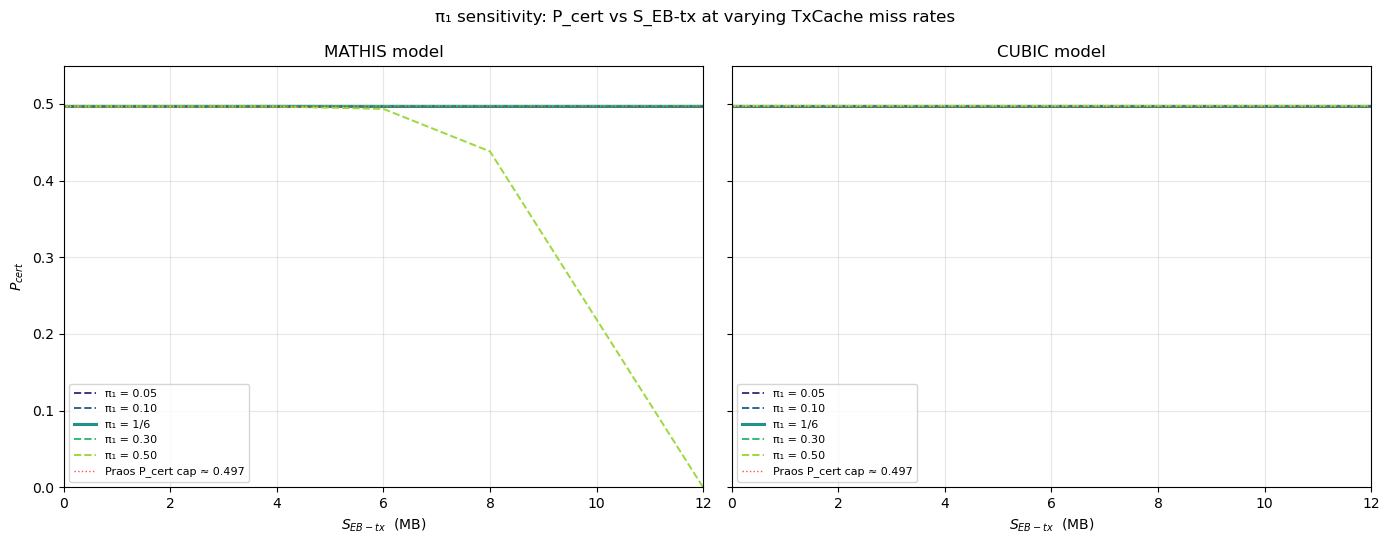


π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)

[MATHIS]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.438   0.000

[CUBIC]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.497   0.497


In [18]:
def plot_pi1_sensitivity(sens):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    pi1_values = sorted(next(iter(sens.values())).keys())
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(pi1_values)))
    for ax, model in zip(axes, ("mathis", "cubic")):
        for pi1, color in zip(pi1_values, cmap):
            rs = sens[model][pi1]
            mbs = [r["s_eb_tx_kb"]/1024 for r in rs]
            pcs = [r["p_cert"] for r in rs]
            tag = "1/6" if abs(pi1 - 1/6) < 1e-4 else f"{pi1:.2f}"
            lw = 2.2 if abs(pi1 - 1/6) < 1e-4 else 1.4
            ls = "-"  if abs(pi1 - 1/6) < 1e-4 else "--"
            ax.plot(mbs, pcs, ls, color=color, lw=lw, label=f"π₁ = {tag}")
        ax.axhline(0.497, color="red", ls=":", lw=1, alpha=0.7,
                   label="Praos P_cert cap ≈ 0.497")
        ax.set_xlabel("$S_{EB-tx}$  (MB)"); ax.set_title(f"{model.upper()} model")
        ax.set_xlim(0, 12); ax.set_ylim(0, 0.55); ax.grid(alpha=0.3)
        ax.legend(loc="lower left", fontsize=8)
    axes[0].set_ylabel("$P_{cert}$")
    fig.suptitle("π₁ sensitivity: P_cert vs S_EB-tx at varying TxCache miss rates",
                 fontsize=12)
    fig.tight_layout(); plt.show()


pi1_sens = run_pi1_sensitivity()
plot_pi1_sensitivity(pi1_sens)
print_pi1_sensitivity_summary(pi1_sens)


**`pi1_sensitivity` *(top-level, both models)***

**What it shows.** Two side-by-side panels (Mathis | CUBIC).  In each panel,
$P_\text{cert}$ vs $S_{EB-tx}$ is plotted as a family of curves, one per
TxCache miss rate $\pi_1 \in \{0.05,\, 0.10,\, 1/6,\, 0.30,\, 0.50\}$.  The
default $\pi_1 = 1/6$ curve is highlighted (thicker, solid); others are
dashed.  The horizontal red dotted line marks the Praos cap
$P_\text{cert} \approx 0.497$.

**Why it matters.** Shows how the quorum cliff (or lack thereof) shifts
with the assumed mempool-fragmentation rate.  **No cliff appears in the
0–12 MB range at any $\pi_1 \leq 1/6$** under either model.  The cliff
only appears for Mathis at $\pi_1 = 0.50$; CUBIC remains feasible at
every tested $\pi_1$ across the full sweep.

### 5.6 Monte Carlo tail validation (CUBIC)

The analytical network model in §5.1–§5.5
treats each per-hop TCP transfer as a *deterministic* function of
$(\text{size}, \text{RTT}, p)$: slow start from initial cwnd = 10 MSS,
cwnd doubles each RTT, capped at the model-specific steady-state
window $W_{\text{ss}}$.  Real TCP transfers are stochastic: random
packet losses can occur during the transfer, triggering CUBIC's
multiplicative-decrease-and-reclimb cycle and adding tail latency.
To validate the analytical model and quantify the tail, we ran a
Monte Carlo TCP CUBIC simulator (a separate companion project,
described below) at the headline parameters of this analysis.

**Setup.**  20,000 independent MC runs per (file size, model) pair
with CUBIC parameters $\beta = 0.3$, $C = 0.4$, fast convergence on;
slow-start ssthresh = BDP (≈ 33 MB at 268 ms × 1 Gbps; the analytical
model instead caps cwnd at the loss-rate-determined
$W_{ss}^C \approx 1.54$ MB, but at the transfer sizes tested here
neither cap binds before slow-start completes the transfer, so the
difference is immaterial); RTT = 268 ms (long-haul, conservative end);
Bernoulli loss at $p = 10^{-4}$; no RTT jitter.

**Results.**  For each closure size appearing in §5.1 /
§5.3,
the analytical prediction is compared with the MC mean, median, P95,
P99, and observed maximum (all times in seconds):

| Scenario                        | Size     | Analytical | MC mean | MC P50 | MC P95 | MC P99 | MC max |
|---------------------------------|----------|-----------:|--------:|-------:|-------:|-------:|-------:|
| **Missing-closure fetch (1-hop, $\pi_1 = 1/6$)** |          |            |         |        |        |        |        |
| missing @ 1 MB closure          | 171 kB   | 0.94       | 1.08    | 1.07   | 1.07   | 1.07   | 3.48   |
| missing @ 4 MB closure          | 683 kB   | 1.48       | 1.65    | 1.61   | 1.61   | 2.68   | 8.04   |
| missing @ 8 MB closure          | 1.37 MB  | 1.75       | 1.96    | 1.88   | 2.14   | 4.29   | 14.74  |
| **missing @ 12 MB closure**     | **2 MB** | **2.01**   | **2.26**| **2.14** | **2.68** | **5.63** | **13.94**|
| **Full closure (§5.3 worst case)** |          |            |         |        |        |        |        |
| full @ 1 MB                     | 1.02 MB  | 1.74       | 1.93    | 1.88   | 1.88   | 3.48   | 11.79  |
| full @ 4 MB                     | 4.10 MB  | 2.28       | 2.69    | 2.41   | 4.02   | 9.92   | 20.10  |
| full @ 8 MB                     | 8.19 MB  | 3.09       | 3.29    | 2.68   | 6.43   | 13.67  | 26.26  |
| **full @ 12 MB**                | **12.3 MB** | **3.63**| **3.77**| **2.68** | **8.84** | **16.08** | **29.48** |

**Three takeaways.**

1. **Analytical model captures the modal outcome.**  The MC median is
   essentially the analytical value at every size — confirming the
   deterministic slow-start-to-$W_{\text{ss}}$ formulation correctly
   predicts the *loss-free* trajectory, which is the typical outcome
   at $p = 10^{-4}$.  Mean alignment is within ~15% across the table.

2. **Right tails grow with payload size.**  The MC P99 / analytical
   ratio rises from 1.14× at the smallest size to 2.80× at 12 MB
   missing-fetch and 4.43× at 12 MB full-closure.  Loss events during
   long transfers compound: each loss costs ~one round-trip plus the
   CUBIC reclimb, and larger transfers carry more rounds.

3. **The §5.1 headline at 12 MB CUBIC stays robust to the tail.**
   The "≈ 2.0 s" missing-closure-fetch figure is the *typical*
   outcome; 1 in 100 transfers takes 5.6 s, and the worst observed
   was 13.9 s.  All percentiles up to P99 still complete within the
   7 s voter deadline, so §5.1's
   $P_{\text{validating}} = 0.992$ for 12 MB CUBIC is consistent with the tail behaviour the
   analytical model omits.  At the §5.3 full-blended worst case
   (12 MB full-closure), MC confirms
   $P(\text{full diffusion} \leq 14\,\text{s}) \approx 0.98$, close to the 99.1% figure cited
   in §5.2 (within MC noise).

**Caveats.**

1. **CUBIC only.**  The estimator simulates TCP CUBIC.  The §5.1a
   Mathis (Reno/AIMD) results are not yet MC-validated; adding a Reno
   branch to the estimator is a modest follow-up.
2. **Long-haul RTT only.**  The §5.1 "blended" numbers average over
   short / medium / long distance categories and path lengths 1–5.
   The MC results above all use RTT = 268 ms (the long-haul end,
   conservative).  Shorter-RTT distributions would have proportionally
   shorter tails.
3. **Single TCP connection.**  The estimator models one TCP flow with
   a single end-to-end RTT.  The §5.3 "blended multi-hop" scenario
   chains multiple per-hop transfers; here we approximate that as a
   single connection at the long-haul RTT, which overstates per-hop
   independence but is the closest direct analog.
4. **Bernoulli loss only.**  The estimator also supports
   Gilbert–Elliott (bursty) loss but we use Bernoulli here for
   apples-to-apples comparison against the analytical model.  Bursty
   loss would heighten the tails further.

**Connection to §7 Limitation 9.**  The
table above gives the first concrete tail evidence for the *network*
step (where Limit 9 previously had only qualitative claims).  P99 / mean
ratios of 2–4× confirm that per-hop transfer time has substantially
heavier tails than the analytical Gaussian-collapse implicit in our
ΔQ network module, even before adding the per-tx CPU tail.  The two
sources of tail compound in the full voter pipeline.


### 5.7 Full Closure Diffusion Conditional on Certification

The security assumptions for Linear Leios require that a *certified EB*
reaches all honest nodes by the end of $L_\text{diff}$.
We are therefore interested in the conditional CDF

$$F_{\text{full}\mid C}(t)\;:=\;P\!\left(\max_{j=1\ldots N} T_j \le t \;\bigg|\; C\right)$$

where $T_j$ is the **EB-closure completion time** at node $j$ and $C$ is the
certification event "the on-time committee votes carry at least a fraction
$\tau$ of the **total active stake** by
$t_v = 3L_\text{hdr}+L_\text{vote}=7\,\text{s}$".

#### The closure-completion CDF $G$

Unlike the body, the closure is not delivered in one transfer: a node must
receive the EB body, fetch the *missing* fraction $\pi_1\cdot S_{EB\text{-}tx}$
of referenced transactions, and re-apply the whole closure.  The per-node
arrival law is therefore the **sequential composition** of stages defined in §4,

$$G\;=\;\underbrace{\texttt{cdf\_fetch\_eb\_body()}}_{\text{body diffusion}}\;\otimes\;\underbrace{\texttt{cdf\_fetch\_missing\_eb\_closure}(S_{EB\text{-}tx})}_{\text{fetch missing txs (1-hop)}}\;\otimes\;\underbrace{\texttt{cdf\_process\_eb\_closure}(S_{EB\text{-}tx})}_{\text{process closure (CPU)}}$$

where $\otimes$ is sequential convolution (`cdf_sequential`). 

#### Stake-weighted committee

Certification is **stake-weighted**: by CIP-0164 an EB is certified once the
on-time votes carry at least a fraction $\tau$ of the **total active stake**,

$$\sum_{v\in\text{votes}}\text{stake}(v)\;\ge\;\theta,\qquad
\theta:=\tau\cdot S_\text{active},$$

where $S_\text{active}$ is the total active stake.  The committee is the
**canonical CIP-0164 voting committee**: a *deterministic* stake-based truncation
— order SPOs by active stake (descending) and select until their cumulative stake
reaches the target $\sigma_c$ (`stake_cover`; equivalently the truncation error
falls below $\varepsilon_c=1-\sigma_c$).  The set is fixed for the epoch. 
Each member of the committee votes with weight
$w_i=s_i$.  Because the
committee holds only a fraction $\sigma_c$ of the total stake,
$S_\text{active}=M/\sigma_c$ and the quorum is $\theta=\tau\,M/\sigma_c$ — the
committee must contribute $\tau/\sigma_c$ of *its own* weight (certification is
impossible if $\tau>\sigma_c$).

Because per-node closure completion $T_i$ is assumed independent of stake,
committee membership only fixes *which* nodes vote (and with what weight); each
node's completion law is still $G$.  Writing the on-time vote total, when every
committee member is independently on time with probability $p$, as a weighted sum
**over the committee**

$$V(p)\;=\;\sum_{i\in\text{cmte}} w_i\,\text{Bern}(p),\qquad
\mathbb{E}[V(p)] = M p,\qquad
\operatorname{Var}[V(p)] = M_2\,p(1-p),$$

with the committee weight and its second moment

$$M=\sum_{i\in\text{cmte}} w_i=\sum_{i\in\text{cmte}} s_i,\qquad
M_2=\sum_{i\in\text{cmte}} w_i^2=\sum_{i\in\text{cmte}} s_i^2,$$

gives a **weighted Binomial** — all committee members share the same on-time
probability $p$, so there is **no election variance** (the committee is fixed; the
only randomness is each member's on-time indicator).  (The shared
`_committee_moments` returns $(M,\,M_2,\,S_\text{active})$.)  We use the §4.6 Normal approximation for the upper
tail (Step 7) and define the **stake-weighted quorum function**

$$Q(p)\;:=\;P\!\bigl(V(p)\ge \theta\bigr),$$

the probability that the on-time votes meet the quorum $\theta$ when each member
is on time with probability $p$.  For $p=G(t_v)$ this is exactly the §4.6
`p_quorum`.  (§5.8 generalises $Q$ to a partly Byzantine committee.)

#### Closed form

Assuming the $T_j$ are i.i.d. samples from $G$ (hop-count randomness already
mixed in via `_HOP_PROBS`):

$$\boxed{\,F_{\text{full}\mid C}(t)\;=\;G(t)^{N}\cdot
\dfrac{Q\!\bigl(\min(G(t_v)/G(t),\,1)\bigr)}{Q\!\bigl(G(t_v)\bigr)}\,}$$

with $P(C) = Q(G(t_v))$ the marginal certification probability and the
$\min(\cdot,1)$ folding in the $t<t_v$ branch (an arrived node is then
necessarily fast).  The factor $G(t)^{N}$ is the probability that all $N$ 
nodes have completed the closure.  (§5.8 replaces $N$ by the honest count 
$N_h$ once a $\beta$-fraction of the committee is Byzantine.)

#### Derivation

**Notation.**  For node $i\in\{1,\dots,N\}$ let $T_i\sim G$ be its
closure-completion time and $w_i$ its stake weight; the committee is a fixed set
of nodes (written $i\in\text{cmte}$).  The only randomness is timing: the $T_i$
are independent across nodes.  Abbreviate $g_v:=G(t_v)$ and, for the fixed
evaluation time $t$, $G_t:=G(t)$.  The on-time (stake-weighted) vote total is

$$V_\text{on}\;:=\;\sum_{i\in\text{cmte}} w_i\,\mathbb 1\{T_i\le t_v\}.$$

We want $F_{\text{full}\mid C}(t)=P\big(A(t)\mid C\big)$ with

$$A(t):=\Big\{\max_j T_j\le t\Big\}=\bigcap_i\{T_i\le t\}\ \ (\text{all nodes complete by }t),
\qquad C:=\{V_\text{on}\ge\theta\},$$

so by the definition of conditional probability

$$F_{\text{full}\mid C}(t)=\frac{P\big(A(t)\cap C\big)}{P(C)}.$$

All $N$ nodes are honest here; §5.8 generalises the result to a partly
Byzantine committee.

**Step 1 — The denominator $P(C)$.**  Write
$V_\text{on}=\sum_{i\in\text{cmte}} Y_i$ with $Y_i:=w_i\,\mathbb 1\{T_i\le t_v\}$.
The $Y_i$ are independent, and each takes value $w_i$ with probability
$P(T_i\le t_v)=g_v$ (else $0$).  Hence $V_\text{on}$ is a **weighted Binomial**,
with

$$\mathbb E[V_\text{on}]=\sum_{i\in\text{cmte}} w_i\,g_v=M g_v,\qquad
\operatorname{Var}[V_\text{on}]=\sum_{i\in\text{cmte}} w_i^2\,g_v(1-g_v)=M_2\,g_v(1-g_v),$$

and $P(C)=P(V_\text{on}\ge\theta)=:Q(g_v)$ (evaluated by the Normal
approximation of Step 7).

**Step 2 — Bucketing the numerator (case $t\ge t_v$).**  Using
$\{T_i\le t_v\}\subseteq\{T_i\le t\}$, split each node into three disjoint
buckets:

$$\underbrace{\{T_i\le t_v\}}_{\text{fast, prob }g_v}\ \uplus\
\underbrace{\{t_v<T_i\le t\}}_{\text{medium, prob }G_t-g_v}\ \uplus\
\underbrace{\{T_i> t\}}_{\text{slow, prob }1-G_t}.$$

The diffusion event $A(t)=\bigcap_i\{T_i\le t\}$ is exactly "**no node is
slow**".  On $A(t)$ we have $\mathbb 1\{T_i\le t_v\}=\mathbb 1\{i\text{ fast}\}$,
so the surviving votes are the *fast* ones:

$$A(t)\cap C=\{\text{no slow node}\}\ \cap\
\Big\{\,V_\text{fast}\ge\theta\,\Big\},\qquad
V_\text{fast}:=\sum_{i\in\text{cmte}} w_i\,\mathbb 1\{i\text{ fast}\}.$$

**Step 3 — Factor out "no slow node".**  Because the $T_i$ are independent
across nodes, conditioning every node on $\{T_i\le t\}$ keeps them independent and
factorises the probability:

$$P\big(A(t)\cap C\big)
=\underbrace{P(\text{no slow node})}_{\displaystyle=\prod_i P(T_i\le t)=G_t^{\,N}}
\ \cdot\ P\big(V_\text{fast}\ge\theta\ \big|\ \text{no slow node}\big).$$

**Step 4 — Bayes re-bucketing of the conditional law.**  For $t\ge t_v$, Bayes'
rule gives the conditional fast-probability of an *arrived* node:

$$p_f:=P\big(T_i\le t_v\ \big|\ T_i\le t\big)
=\frac{P(T_i\le t_v)}{P(T_i\le t)}=\frac{g_v}{G_t}\ \le 1.$$

Membership is deterministic, so each summand
$Z_i:=w_i\,\mathbb 1\{i\text{ fast}\}$ ($i\in\text{cmte}$) takes value $w_i$ with
probability $p_f$ (else $0$), independently across $i$.
Therefore the conditioned fast-vote total is again a weighted Binomial with
on-time probability $p_f$:

$$P\big(V_\text{fast}\ge\theta\mid\text{no slow}\big)=Q(p_f).$$

(This is the multinomial-collapse trick: merging "fast" and "medium" into "not
slow" turns the three-way split into a single weighted Binomial on the
survivors.)

**Step 5 — Assemble and divide.**  Combining Steps 3–4 and dividing by
$P(C)=Q(g_v)$,

$$P\big(A(t)\cap C\big)=G_t^{\,N}\cdot Q\!\big(g_v/G_t\big)
\qquad\Longrightarrow\qquad
F_{\text{full}\mid C}(t)=\frac{G_t^{\,N}\,Q(g_v/G_t)}{Q(g_v)}\quad(t\ge t_v),$$

which is the boxed form.  (§5.8 replaces $N$ by the honest count $N_h$ and lets
$Q$ count adversarial seats.)

**Step 6 — The case $t<t_v$.**  Now $\{T_i\le t\}\subseteq\{T_i\le t_v\}$, so an
arrived node is *certainly* fast and $p_f=P(T_i\le t_v\mid T_i\le t)=1$
(equivalently $g_v/G_t>1$, **capped at 1**).  Then
$V_\text{fast}=\sum_{i\in\text{cmte}} w_i$ is the whole committee weight $M$ and

$$P\big(A(t)\cap C\big)=G_t^{\,N}\cdot P\Big(\textstyle\sum_{i\in\text{cmte}} w_i\ge\theta\Big)=G_t^{\,N}\,Q(1).$$

Since the committee is **fixed**, $\sum_{i\in\text{cmte}} w_i = M$ deterministically, so
$Q(1)=\mathbb 1\{M\ge\theta\}=\mathbb 1\{\sigma_c\ge\tau\}=1$ for the default
$\sigma_c=0.99>\tau$: once everyone votes the quorum is certain (unlike a random
committee, $t<t_v$ contributes no quorum shortfall).  Writing
$p_f=\min(g_v/G_t,\,1)$ unifies both cases, and at $t=t_v$ they agree ($p_f=1$) —
giving the single boxed formula.

**Step 7 — Normal approximation for $Q$.**  Each $Q(p)=P\big(V(p)\ge\theta\big)$
is evaluated with the §4.6 Normal approximation to the (weighted-Binomial)
vote total $V(p)$, using its mean and variance from the "Stake-weighted
committee" box above:

$$Q(p)\approx\Phi^c\!\left(\frac{\theta-M p}{\sqrt{M_2\,p(1-p)}}\right),$$

where $\Phi^c$ is the standard-normal upper tail.  This is exactly the §4.6
`p_quorum` at on-time probability $p$.  (§5.8 adds the adversary's seats to the
mean and variance.)

#### Caveats

- **Normal-approximation quorum:** $P(C)$ and the voter factor use the §4.6
  Normal approximation to the stake-weighted vote total (here a weighted
  Binomial over the fixed committee) — slightly off only in the extreme tails.
- **i.i.d. is pessimistic for "all", and more so for the closure:** real
  $T_j$'s are positively correlated, and closure completion shares *even more*
  structure across nodes than body receipt (common body diffusion **and**
  correlated TxCache hit/miss state), so the true $F_{\text{full}\mid C}$ is
  *larger* than the formula gives.
- **Delivery vs. readiness:** `include_validation=True` (default) charges the
  CPU cost (readiness); set it `False` for delivery-only.  That CPU law differs
  by role — full-validation $\mu_\text{eff}$ for the voter / certification
  factors, reapply-only $G_\text{apply}$ for the all-honest-nodes diffusion term
  (see "Two CPU laws" above).
- **1-hop missing-tx fetch:** the missing closure fraction is fetched in a
  single hop from the peer that forwarded the body; the conservative multi-hop
  variant is available via `cdf_fetch_missing_eb_closure(..., use_1hop=False)`.
- **Stake-independent completion assumed:** committee selection is stake-based,
  but $T_i$ is assumed independent of stake.  If larger SPOs are systematically
  better-connected, the (top-stake) committee is disproportionately fast and $C$
  carries less information about the slow tail, making the formula optimistic.

In [19]:
# §5.7 stake-weighted certification model.  The committee is the canonical
# CIP-0164 voting committee: a DETERMINISTIC, stake-based truncation.  Order pools
# by active stake (descending) and select until their cumulative stake reaches the
# target sigma_c (= `stake_cover`, equivalently the truncation error falls below
# eps_c = 1 - sigma_c); the set is fixed for the epoch.  No sortition, no random
# committee size.  Each member votes with weight = its stake, so the quorum is
# genuinely stake-weighted.
#
# The on-time vote total V(p) is a weighted Binomial with mean M*p and variance
# M2*p*(1-p), over the truncated committee (each member votes with weight w_i = s_i):
#   M  = Sum_{cmte} w_i   (committee weight),
#   M2 = Sum_{cmte} w_i^2 (second moment; committee fixed -> no election variance).
# The CIP-0164 quorum threshold is tau * (TOTAL active stake), S_active, NOT tau*M:
# the committee holds only a fraction sigma_c of total active stake, so
# S_active = M/sigma_c and the truncated committee must contribute tau/sigma_c of
# its own weight (certification is impossible if tau > sigma_c).  Weights are
# renormalised so Sum w = K (the committee node count), putting M in
# member-equivalent units; the quorum probability is scale-invariant in the
# weights, so this changes no probability.  `_committee_moments` is defined in
# §4.6 (shared with compute_p_certified) and reused here.


def _committee_label(n_nodes: int = 2500, stake_cover: float = 0.99) -> str:
    """Human-readable committee description, incl. the effective number of
    equal-weight votes M_eff = M^2/M2 (inverse Herfindahl: < M when a few large
    SPOs dominate the stake-weighted vote)."""
    M, M2, _ = _committee_moments(n_nodes, stake_cover)
    m_eff = M * M / M2
    stakes = _stake_distribution(n_nodes)
    s = np.sort(stakes)[::-1]
    K = int(np.searchsorted(np.cumsum(s), stake_cover * float(np.sum(s)),
                            side="left")) + 1
    return (f"CIP top-stake cover sigma_c={stake_cover:.0%} "
            f"(K={K} of {n_nodes} nodes, M_eff={m_eff:.0f})")


def _quorum_sf(mu, var, threshold):
    """Normal-approx upper tail P(votes >= threshold) for a stake-weighted vote
    count with mean `mu` and variance `var` (== §4.6 p_quorum).  Vectorised over
    array-valued mu / var."""
    mu = np.asarray(mu, dtype=float)
    sig = np.sqrt(np.clip(np.asarray(var, dtype=float), 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        p = stats.norm.sf((threshold - mu) / sig)
    # sigma ~ 0 -> degenerate vote count: step function at the mean.
    return np.where(sig < 1e-12, (mu >= threshold).astype(float), p)


def _quorum_given_honest_ontime(p, n_nodes, tau, beta, adversary, stake_cover=0.99):
    """Q(p): P(certify) when each honest committee member is on time with
    probability `p`.  Honest weight is a (1-beta) fraction of the committee; an
    *active* adversary adds its beta-fraction of committee weight as always-on-time
    (p=1) votes, a *silent* adversary adds none.  The CIP-0164 quorum threshold is
    tau * total active stake (tau*S_active = tau*M/sigma_c).  Vectorised over `p`."""
    M, M2, S_active = _committee_moments(n_nodes, stake_cover)
    f_h = 1.0 - beta
    if adversary == "active":
        mu_a, var_a = beta * M, 0.0                      # beta*M deterministic seats (p=1)
    elif adversary == "silent":
        mu_a = var_a = 0.0                               # votes withheld
    else:
        raise ValueError("adversary must be 'active' or 'silent'")
    p = np.asarray(p, dtype=float)
    mu = f_h * (M * p) + mu_a
    var = f_h * (M2 * p * (1.0 - p)) + var_a
    return _quorum_sf(mu, var, tau * S_active)


def _full_diffusion_given_cert_from_G(
    G: np.ndarray,
    G_apply: np.ndarray = None,
    n_nodes: int = 2500,
    tau: float = 0.75,
    t_vote: float = 7.0,
    beta: float = 0.0,
    adversary: str = "active",
    stake_cover: float = 0.99,
) -> np.ndarray:
    """
    Core §5.7 conditional CDF for an *arbitrary* per-node arrival CDF G on the
    global TIMES grid.  The committee / quorum argument never touches G, so the
    same engine serves §5.7 (beta = 0) and the adversarial §5.8 treatment
    (beta > 0) -- only the stake-weighted quorum Q changes.  See the §5.7 / §5.8
    markdown for the derivation:

        F_{full|C}(t) = G_apply(t)^{N_h} * Q(min(G(t_v)/G(t), 1)) / Q(G(t_v))

    where Q(p) is the stake-weighted quorum probability given honest on-time
    probability p, and N_h is the honest node count (all honest nodes -- the
    diffusion target).

    G is the VOTER / certification arrival law (full-validation CPU): it feeds
    g_tv = G(t_v), P(C) and the voter factor.  G_apply is the APPLY arrival law
    (reapply-only CPU) used for the all-honest-nodes diffusion power term; it
    defaults to G.  Mixing two laws in a closed form derived for one is a
    first-order approximation -- the coupling ratio min(G(t_v)/G(t),1) keeps the
    validation law G.
    """
    if G_apply is None:
        G_apply = G
    g_tv = success_within(G, t_vote)
    N_h = int(round((1.0 - beta) * n_nodes))

    def Q(p):
        return _quorum_given_honest_ontime(
            p, n_nodes, tau, beta, adversary, stake_cover=stake_cover,
        )

    # P(C): marginal certification probability (honest on-time prob = G(t_v)).
    pC = float(Q(g_tv))
    if pC <= 0.0:
        return np.zeros_like(G)

    # G_apply(t)^N_h in log space to avoid underflow for large N_h: all honest
    # nodes APPLY the already-certified closure (reapply-only CPU law).
    with np.errstate(divide="ignore"):
        log_G = np.where(G_apply > 0, np.log(np.clip(G_apply, 1e-300, 1.0)), -np.inf)
    G_pow_N = np.exp(N_h * log_G)

    # Voter factor: quorum given "no slow honest node", i.e. honest on-time prob
    # P(T <= t_v | T <= t) = min(G(t_v)/G(t), 1).
    safe_G = np.where(G > 0, G, 1.0)
    p_fast_given_arrived = np.clip(g_tv / safe_G, 0.0, 1.0)
    voter_factor = Q(p_fast_given_arrived)

    out = G_pow_N * voter_factor / pC
    return np.clip(out, 0.0, 1.0)


def cdf_closure_completion(
    s_eb_tx_kb: float, include_validation: bool = True, reapply_only: bool = False
) -> np.ndarray:
    """
    Per-node EB-CLOSURE completion CDF G(t): the time for a node to receive the
    EB body, fetch the missing closure transactions (1-hop), and -- when
    include_validation=True -- process the whole closure (CPU).

      include_validation=True  -> readiness   (body + missing-tx fetch + CPU)
      include_validation=False -> delivery only (body + missing-tx fetch)

    The CPU stage depends on the role (see cdf_process_eb_closure):
      reapply_only=False -> committee-VOTER validation law (applyTx on cache
                            misses); identical to cdf_validate_eb_for_voter.
      reapply_only=True  -> already-certified-EB APPLY law (reapplyTx for every
                            tx, scripts skipped) -- the all-honest-nodes
                            diffusion term in section 5.6.
    """
    if include_validation:
        return cdf_sequential(
            cdf_sequential(
                cdf_fetch_eb_body(),
                cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=True),
            ),
            cdf_process_eb_closure(s_eb_tx_kb, reapply_only=reapply_only),
        )
    return cdf_sequential(
        cdf_fetch_eb_body(),
        cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=False),
    )


def cdf_full_closure_diffusion_given_cert(
    s_eb_tx_kb: float,
    n_nodes: int = 2500,
    tau: float = 0.75,
    t_vote: float = 7.0,
    beta: float = 0.0,
    adversary: str = "active",
    stake_cover: float = 0.99,
    include_validation: bool = True,
) -> np.ndarray:
    """
    §5.7: conditional CDF F_{full|C}(t) = P(all honest nodes hold the validated EB
    CLOSURE by t | EB certified).  The per-node arrival law is the closure-completion
    CDF G = cdf_closure_completion(s_eb_tx_kb); the stake-weighted quorum (CIP-0164
    stake-truncated committee) is derived in the §5.7 markdown.  Parameterised by
    the closure size S_EB_tx (kB).  See §5.8 for the adversarial (beta > 0)
    treatment.
    """
    G = cdf_closure_completion(s_eb_tx_kb, include_validation=include_validation)
    # All-honest-nodes diffusion term G_apply(t)^N_h: those nodes APPLY the
    # already-certified closure (reapplyTx throughout, scripts skipped); the
    # voter / certification factors keep the full-validation law G.
    G_apply = cdf_closure_completion(
        s_eb_tx_kb, include_validation=include_validation, reapply_only=True
    )
    return _full_diffusion_given_cert_from_G(
        G, G_apply, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=beta,
        adversary=adversary, stake_cover=stake_cover,
    )


def cdf_full_closure_diffusion_unconditional(
    s_eb_tx_kb: float, n_nodes: int = 2500, include_validation: bool = True
) -> np.ndarray:
    """Unconditional baseline for max_j T_j under the closure model: G(t)^N."""
    G = cdf_closure_completion(s_eb_tx_kb, include_validation=include_validation)
    with np.errstate(divide="ignore"):
        log_G = np.where(G > 0, np.log(np.clip(G, 1e-300, 1.0)), -np.inf)
    return np.exp(n_nodes * log_G)


  committee: CIP top-stake cover sigma_c=99% (K=923 of 2500 nodes, M_eff=466)
  quorum threshold = tau * total active stake = 699 (committee weight M = 923)
  S_EB_tx   G(t_v)  G(t_f)  P(C)     F_{full|C}(t_f)  G(t_f)^N
  ----------------------------------------------------------------------


      1 MB  0.9978     1.0000     1.0000   1.0000            1.000e+00
      4 MB  0.9965     1.0000     1.0000   1.0000            1.000e+00
     12 MB  0.9482     1.0000     1.0000   0.9990            9.960e-01


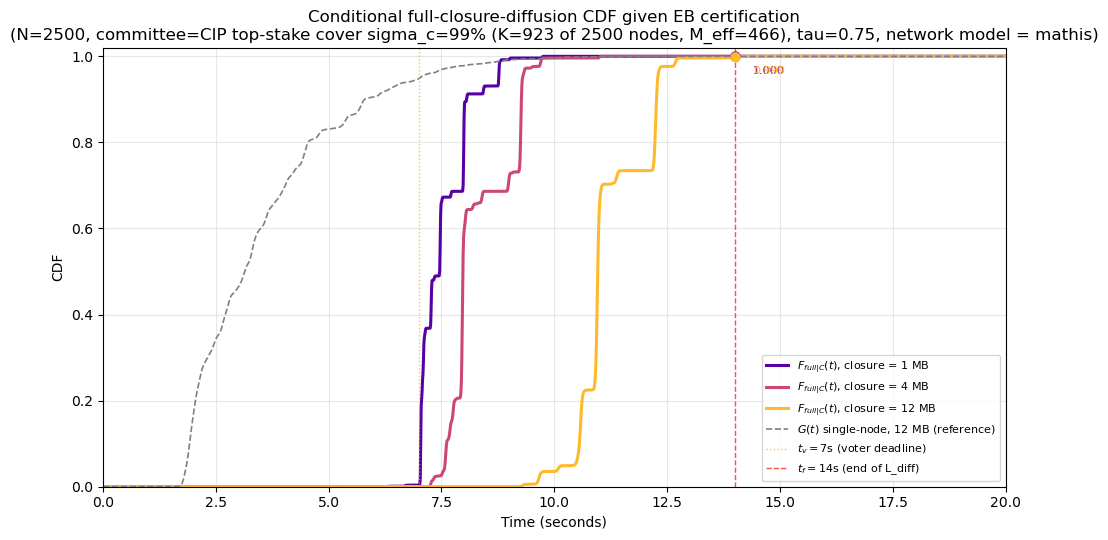

In [20]:
def plot_full_closure_diffusion_given_cert(
    sizes_kb=(1024, 4096, 12288),
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
    include_validation=True,
):
    """
    §5.7: F_{full|C}(t) under the closure model for several S_EB_tx sizes, with the
    single-node closure CDF G(t) at the largest size as a lower-bound reference.
    Annotates F_{full|C}(t_diff_end) at the L_diff deadline.
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(sizes_kb)))

    for s_kb, color in zip(sizes_kb, cmap):
        cdf_cond = cdf_full_closure_diffusion_given_cert(
            s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, stake_cover=stake_cover,
            include_validation=include_validation,
        )
        ax.plot(TIMES, cdf_cond, lw=2.2, color=color,
                label=f"$F_{{full|C}}(t)$, closure = {s_kb / 1024:.0f} MB")

        f_at_deadline = success_within(cdf_cond, t_diff_end)
        ax.scatter([t_diff_end], [f_at_deadline], color=color, zorder=5, s=40)
        ax.annotate(
            f"{f_at_deadline:.3f}",
            xy=(t_diff_end, f_at_deadline),
            xytext=(t_diff_end + 0.4, f_at_deadline - 0.04),
            fontsize=8, color=color,
        )

    # Reference: single-node closure-completion CDF at the largest size (optimistic
    # lower bound on "any single node by t").
    ax.plot(TIMES, cdf_closure_completion(max(sizes_kb), include_validation),
            ls="--", lw=1.2, color="gray",
            label=f"$G(t)$ single-node, {max(sizes_kb) / 1024:.0f} MB (reference)")

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v = {t_vote:g}$s (voter deadline)")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f = {t_diff_end:g}$s (end of L_diff)")

    ax.set_xlim(0, 20); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(
        "Conditional full-closure-diffusion CDF given EB certification\n"
        f"(N={n_nodes}, "
        f"committee={_committee_label(n_nodes, stake_cover)}, "
        f"tau={tau}, network model = {NETWORK_MODEL})"
    )
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout(); plt.show()


def print_full_closure_diffusion_summary(
    sizes_kb=(1024, 4096, 12288),
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
    include_validation=True,
):
    M, _, S_active = _committee_moments(n_nodes, stake_cover)
    print(f"  committee: {_committee_label(n_nodes, stake_cover)}")
    print(f"  quorum threshold = tau * total active stake = {tau * S_active:.0f} "
          f"(committee weight M = {M:.0f})")
    print(f"  S_EB_tx   G(t_v)  G(t_f)  P(C)     F_{{full|C}}(t_f)  G(t_f)^N")
    print("  " + "-" * 70)
    for s_kb in sizes_kb:
        G = cdf_closure_completion(s_kb, include_validation)
        g_tv = success_within(G, t_vote)
        g_tf = success_within(G, t_diff_end)
        pC = float(_quorum_given_honest_ontime(
            g_tv, n_nodes, tau, 0.0, "active", stake_cover=stake_cover))
        f_cl = success_within(
            cdf_full_closure_diffusion_given_cert(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, stake_cover=stake_cover,
                include_validation=include_validation),
            t_diff_end)
        f_uncond = g_tf ** n_nodes
        print(f"  {s_kb / 1024:>5.0f} MB  {g_tv:.4f}     {g_tf:.4f}     {pC:.4f}   "
              f"{f_cl:.4f}            {f_uncond:.3e}")


# Conservative reference network model.
set_network_model("mathis")
print_full_closure_diffusion_summary()
plot_full_closure_diffusion_given_cert()


#### 5.7.1 Hop-count reach lower bound given certification *(Panagiotakos)*

The conditional CDF $F_{\text{full}\mid C}$ above is a statement about the
**timing tail**: assuming i.i.d. per-node completion times $T_j\sim G$, it bounds
$P(\max_j T_j\le t\mid C)$.  The note *"Linear Leios — Optimizing delivery of certified EBs"*
(G. Panagiotakos; supersedes the earlier *"Fetching certified EBs"* note) gives a
**complementary, topological lower bound** that does not
depend on the timing law at all: a certificate *guarantees* that a floor of the
stake already holds the EB at $L_\text{vote}$, and stake-weighted peer sampling
then spreads it to (almost) all honest, reachable nodes within a *few hops*.

**Design augmentation.**  The bound relies on a small change to fetching: once
$L_\text{vote}$ slots have passed since an EB was generated, a node requests the
**full EB from every randomly-sampled big-ledger peer (BLP) that has advertised
it** (rather than from a single upstream).  Each node keeps $s=3$ recently-sampled
BLPs, drawn *independently in proportion to stake*.

**Assumptions (relative stake units).**

| symbol | meaning |
|--------|---------|
| $h_v$  | honest **and voting** stake |
| $h_r$  | honest, voting, **and reachable/responsive** stake ($h_r\le h_v$) |
| $a$    | malicious stake |
| $\tau$ | certificate threshold (`th`) |

*Real-world calibration (Panagiotakos).*  Current network measurements put the
honest-reachable stake at $h_r\lesssim 77\%$; the worked example below uses the
conservative $h_r=60\%$.

**Certification stake floor.**  Let $h_c$ be the honest, voting, reachable stake
that has *received the full EB* by the end of $L_\text{vote}$.  A certificate
carries $\ge\tau$ of the stake; in the worst case those votes include **all**
malicious stake $a$ and **all** voting-but-unreachable stake $h_v-h_r$, so the
honest-reachable contribution must make up the remainder:

$$\boxed{\,h_c\;\ge\;\tau-a-(h_v-h_r)\,}$$

*Example* ($\tau=0.75,\ a=0.25,\ h_r=0.60,\ h_v=0.75$): $h_c\ge 0.35$.

**Stake-weighted sampling recurrence.**  A node fails to contact an EB holder on
its first hop only if *none* of its $s$ stake-sampled peers holds it; propagating
outward from the certified floor $e_0:=h_c$,

$$p_k\;:=\;1-(1-e_{k-1})^{\,s},\qquad
e_k\;:=\;e_{k-1}+(h_r-e_{k-1})\,p_k,$$

where $e_k$ is the reached fraction of the honest-reachable set after $k$ hops
(so $p_1\ge 1-(1-h_c)^s$ and $e_1\ge h_c+(h_r-h_c)\,p_1$).  The sequence is
monotone and converges to $h_r$.  For the example above (reproduced by the code
cell):

| hop $k$ | $p_k$ | $e_k$ |
|--------:|------:|------:|
| 1 | 72.5% | 53.1% |
| 2 | 89.7% | 59.3% |
| 3 | 93.3% | 59.9% |
| 4 | 93.6% | 60.0% |

So **2–3 hops suffice** to reach essentially all of the honest, reachable stake
($h_r=60\%$) — independent of the timing model.

**Connection to the timing budget.**  The recurrence bounds the *number of hops*;
the §4.2 network model converts that to wall-clock time.  After certification at
$t_v$, the residual window to the end of $L_\text{diff}$ is $t_f-t_v$; reaching
the honest-reachable set in $k^\star$ hops is feasible whenever $k^\star$
sequential EB hops complete inside that window (`cdf_hops`).  The code cell
reports the $p50/p99$ time of $k^\star$ hops against that budget.

**Caveats.**

- *Lower bound, worst case.*  $h_c$ assumes the certificate is filled first by
  adversarial and unreachable stake; the true reached fraction is larger.
- *Only reaches $h_r$.*  This bounds coverage of the **reachable** honest set, not
  100% of nodes — it complements (does not replace) the $G(t)^N$ tail of
  $F_{\text{full}\mid C}$, which charges the slow, hard-to-reach nodes.
- *Independent stake samples.*  The $(1-\cdot)^s$ step assumes the $s$ BLP samples
  are independent; correlated peer sets weaken the per-hop gain.
- *Feasibility ($h_c>0$).*  The floor is informative only when
  $\tau> a+(h_v-h_r)$; otherwise certification gives no guaranteed holder stake.

  assumptions: th=75%  a=25%  h_r=60%  h_v=75%  (s=3 stake-sampled BLPs)
  certification stake floor h_c >= th - a - (h_v - h_r) = 35.00%
   hop k      p_k      e_k
  ------------------------
       1  72.54%  53.13%
       2  89.71%  59.29%
       3  93.25%  59.95%
       4  93.58%  60.00%
       5  93.60%  60.00%
  -> converges to h_r = 60%


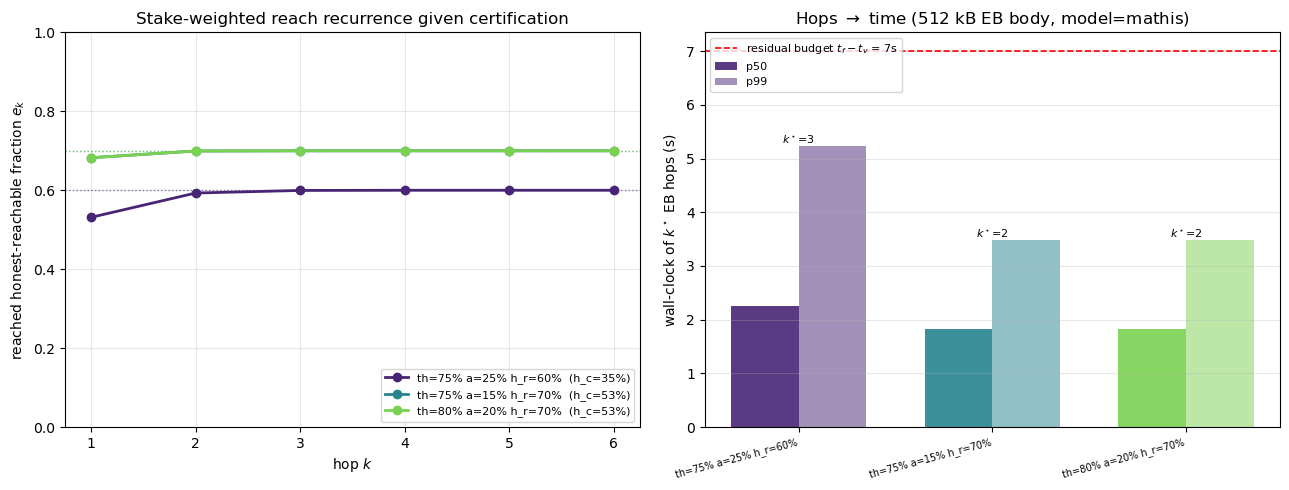

In [21]:
# §5.7.1 Panagiotakos hop-count reach lower bound given certification.
# Complements F_{full|C}: a topological (timing-independent) bound showing that a
# certificate guarantees a stake floor h_c of EB holders, which stake-weighted BLP
# sampling then spreads to the honest-reachable set h_r within a few hops.


def certification_stake_floor(th=0.75, a=0.25, h_r=0.60, h_v=0.75):
    """Worst-case honest+reachable stake holding the full EB at L_vote given a
    certificate: h_c >= th - a - (h_v - h_r), clipped to [0, h_r]."""
    return float(np.clip(th - a - (h_v - h_r), 0.0, h_r))


def hop_reach_recurrence(th=0.75, a=0.25, h_r=0.60, h_v=0.75,
                         n_samples=3, max_hops=6):
    """Stake-weighted sampling recurrence (Panagiotakos), seeded by the certified
    floor e_0 = h_c.  Returns (h_c, ps, es) where es[k-1] is the reached fraction
    of the honest-reachable set after k hops and ps[k-1] the per-hop contact
    probability 1 - (1 - e_{k-1})^s."""
    h_c = certification_stake_floor(th, a, h_r, h_v)
    e = h_c
    ps, es = [], []
    for _ in range(max_hops):
        p = 1.0 - (1.0 - e) ** n_samples
        e = e + (h_r - e) * p
        ps.append(p)
        es.append(e)
    return h_c, ps, es


def hops_to_reach(target_frac, **kw):
    """Smallest hop count k with e_k >= target_frac (None if not within max_hops)."""
    _, _, es = hop_reach_recurrence(**kw)
    for k, e in enumerate(es, start=1):
        if e >= target_frac:
            return k
    return None


def _cdf_quantile(cdf, q):
    """Smallest t on the TIMES grid with cdf(t) >= q (last grid point if none)."""
    idx = min(int(np.searchsorted(cdf, q)), len(TIMES) - 1)
    return float(TIMES[idx])


def print_hop_reach_table(th=0.75, a=0.25, h_r=0.60, h_v=0.75, n_samples=3,
                          max_hops=5):
    """Reproduce the Panagiotakos worked example: certified stake floor h_c and the
    per-hop (p_k, e_k) reach table."""
    h_c, ps, es = hop_reach_recurrence(th, a, h_r, h_v, n_samples, max_hops)
    print(f"  assumptions: th={th:.0%}  a={a:.0%}  h_r={h_r:.0%}  h_v={h_v:.0%}"
          f"  (s={n_samples} stake-sampled BLPs)")
    print(f"  certification stake floor h_c >= th - a - (h_v - h_r) = {h_c:.2%}")
    print(f"  {'hop k':>6}  {'p_k':>7}  {'e_k':>7}")
    print("  " + "-" * 24)
    for k, (p, e) in enumerate(zip(ps, es), start=1):
        print(f"  {k:>6}  {p:>6.2%}  {e:>6.2%}")
    print(f"  -> converges to h_r = {h_r:.0%}")


def plot_hop_reach(scenarios=None, n_samples=3, max_hops=6,
                   eb_body_kb=512, t_vote=7.0, t_diff_end=14.0,
                   reach_eps=0.001):
    """Left: reached honest-reachable fraction e_k vs hop for one or more
    (label, th, a, h_r, h_v) scenarios, with each h_r ceiling.  Right: hops->time,
    the p50/p99 wall-clock of k* sequential EB-body hops (k* = hops to within
    reach_eps of h_r) against the residual L_diff budget (t_diff_end - t_vote)."""
    if scenarios is None:
        scenarios = [
            ("th=75% a=25% h_r=60%", 0.75, 0.25, 0.60, 0.75),
            ("th=75% a=15% h_r=70%", 0.75, 0.15, 0.70, 0.77),
            ("th=80% a=20% h_r=70%", 0.80, 0.20, 0.70, 0.77),
        ]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
    cmap = plt.cm.viridis(np.linspace(0.1, 0.8, len(scenarios)))
    hops = np.arange(1, max_hops + 1)

    budget = t_diff_end - t_vote
    rows = []
    for (label, th, a, h_r, h_v), color in zip(scenarios, cmap):
        h_c, ps, es = hop_reach_recurrence(th, a, h_r, h_v, n_samples, max_hops)
        axL.plot(hops, es, "o-", color=color, lw=2,
                 label=f"{label}  (h_c={h_c:.0%})")
        axL.axhline(h_r, color=color, ls=":", lw=1, alpha=0.6)
        kstar = hops_to_reach(h_r - reach_eps, th=th, a=a, h_r=h_r, h_v=h_v,
                              n_samples=n_samples, max_hops=max_hops)
        rows.append((label, color, h_c, kstar))

    axL.set_xlabel("hop $k$")
    axL.set_ylabel("reached honest-reachable fraction $e_k$")
    axL.set_ylim(0, 1.0)
    axL.set_xticks(hops)
    axL.grid(alpha=0.3)
    axL.set_title("Stake-weighted reach recurrence given certification")
    axL.legend(loc="lower right", fontsize=8)

    # hops -> time: p50/p99 of k* sequential EB-body hops vs the residual budget.
    width = 0.35
    for j, (label, color, h_c, kstar) in enumerate(rows):
        if kstar is None:
            continue
        cdf_k = cdf_hops(kstar, eb_body_kb)
        t50 = _cdf_quantile(cdf_k, 0.50)
        t99 = _cdf_quantile(cdf_k, 0.99)
        axR.bar(j - width / 2, t50, width, color=color, alpha=0.9,
                label="p50" if j == 0 else None)
        axR.bar(j + width / 2, t99, width, color=color, alpha=0.5,
                label="p99" if j == 0 else None)
        axR.annotate(f"$k^\\star$={kstar}", (j, max(t50, t99)), ha="center",
                     va="bottom", fontsize=8)

    axR.axhline(budget, color="red", ls="--", lw=1.2,
                label=f"residual budget $t_f-t_v$ = {budget:g}s")
    axR.set_xticks(range(len(rows)))
    axR.set_xticklabels([r[0] for r in rows], rotation=15, ha="right", fontsize=7)
    axR.set_ylabel("wall-clock of $k^\\star$ EB hops (s)")
    axR.set_title(f"Hops $\\to$ time ({eb_body_kb} kB EB body, model={NETWORK_MODEL})")
    axR.grid(alpha=0.3, axis="y")
    axR.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()


# Conservative reference network model; reproduce the worked example and plot.
set_network_model("mathis")
print_hop_reach_table()
plot_hop_reach()

**Feeding the EB-body diffusion CDF.**  The recurrence is equivalently a statement
about the gossip **distance to the nearest certified holder**, so it yields a
*conditional* hop-count distribution

$$P(\text{dist}=0)=h_c,\qquad P(\text{dist}=k)=e_k-e_{k-1}\quad(k\ge 1),$$

normalised over the reached set.  Conditional on certification this **replaces the
producer-rooted Praos path lengths** (`_HOP_PROBS`, centred at 3–4 hops) that the
unconditional `cdf_fetch_eb_body` blends over with a much shorter
distance-to-holder distribution — giving a faster EB-body diffusion CDF
`cdf_fetch_eb_body_given_cert`.  Two deliberate scoping choices:

- It is a **parallel** conditional model, *not* a drop-in for $G$ inside
  $F_{\text{full}\mid C}$: that closed form's only certification conditioning is the
  $Q(\cdot)$ ratio and its derivation assumes an *unconditional* per-node $G$, so
  substituting a certification-conditional $G$ would condition on $C$ twice.
- It covers the **honest-reachable set $h_r$ only**.  The unreachable $(1-h_r)$
  tail — exactly what the i.i.d. $G(t)^N$ factor of $F_{\text{full}\mid C}$
  charges — is out of scope here.

The cell below compares the two body-diffusion CDFs and their hop-count
distributions.

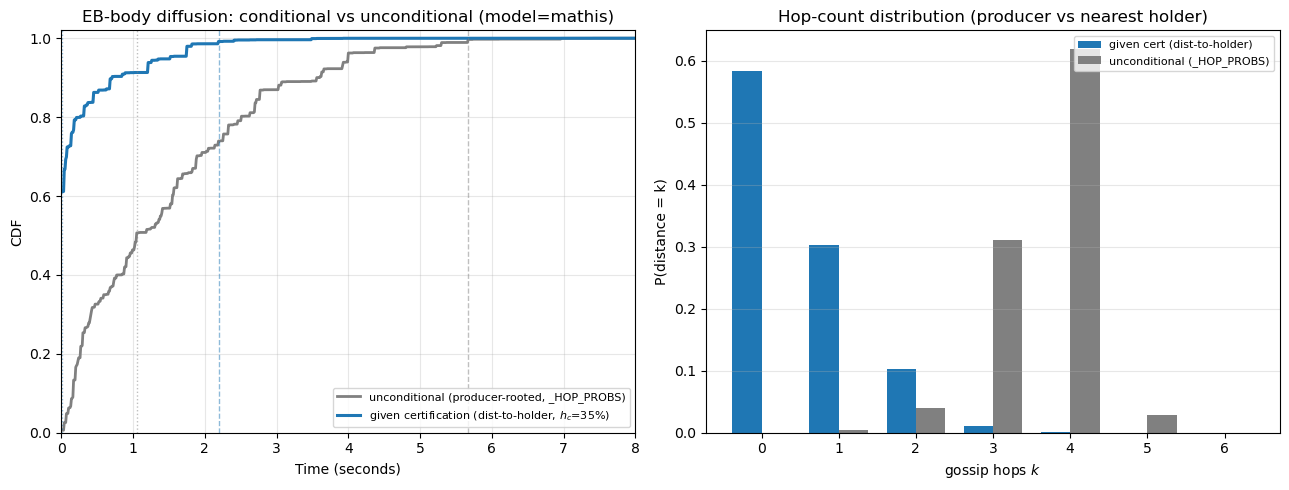

  certified floor h_c = 35.0%  ->  dist-to-holder hop pmf [5.833e-01 3.022e-01 1.026e-01 1.098e-02 7.435e-04 4.776e-05 3.058e-06]
  unconditional: p50=1.05s  p99=5.67s
     given cert: p50=0.01s  p99=2.19s


In [22]:
# §5.7.1 (cont.) Certification-conditional EB-body diffusion CDF.
# The reach recurrence is equivalently a statement about the gossip DISTANCE (in
# hops) from a random honest-reachable node to the NEAREST certified holder:
#   P(0 hops) = h_c,  P(k hops) = e_k - e_{k-1}   (normalised over the reached set).
# Conditional on certification this REPLACES the producer-rooted Praos path-length
# distribution (_HOP_PROBS, ~3-4 hops) that the unconditional cdf_fetch_eb_body
# blends over, with a much shorter distance-to-holder distribution -> a faster
# EB-body diffusion CDF.  It is a PARALLEL conditional model covering only the
# honest-reachable set h_r; it is NOT substituted into F_{full|C} (whose i.i.d.
# G(t)^N tail still charges the slow, unreachable nodes, and whose closed form
# assumes an unconditional per-node G).


def hop_count_distribution_given_cert(th=0.75, a=0.25, h_r=0.60, h_v=0.75,
                                      n_samples=3, max_hops=6):
    """Conditional pmf of the gossip distance (hops) from a random honest-reachable
    node to the nearest certified EB holder: probs[k] = P(distance = k), from the
    reach recurrence (probs[0]=h_c, probs[k]=e_k-e_{k-1}), normalised over the mass
    reached within max_hops."""
    h_c, _, es = hop_reach_recurrence(th, a, h_r, h_v, n_samples, max_hops)
    edges = np.concatenate(([h_c], es))                  # cumulative reach by k hops
    mass = np.concatenate(([edges[0]], np.diff(edges)))  # [h_c, e1-h_c, e2-e1, ...]
    return mass / edges[-1]                              # normalise over reached set


def cdf_fetch_eb_body_given_cert(th=0.75, a=0.25, h_r=0.60, h_v=0.75,
                                 n_samples=3, max_hops=6):
    """EB-body diffusion CDF for a random honest-reachable node CONDITIONAL on
    certification.  Parallels cdf_fetch_eb_body (uniform over EB_BODY_SIZES_KB) but
    blends over the distance-to-holder hop distribution instead of _HOP_PROBS; a
    node at distance 0 already holds the body (zero delay)."""
    probs = hop_count_distribution_given_cert(th, a, h_r, h_v, n_samples, max_hops)
    choices = []
    for s in EB_BODY_SIZES_KB:
        for k, pk in enumerate(probs):
            if pk <= 0.0:
                continue
            leg = cdf_wait(0.0) if k == 0 else cdf_hops(k, s)
            choices.append((pk, leg))   # equal weight per size (cdf_choices renorms)
    return cdf_choices(choices)


def plot_eb_body_diffusion_conditional(th=0.75, a=0.25, h_r=0.60, h_v=0.75,
                                       n_samples=3, max_hops=6):
    """Compare the unconditional EB-body diffusion CDF (producer-rooted _HOP_PROBS)
    with the certification-conditional one (distance-to-holder), and show the
    underlying hop-count distributions."""
    set_network_model("mathis")
    cdf_unc = cdf_fetch_eb_body()
    cdf_cond = cdf_fetch_eb_body_given_cert(th, a, h_r, h_v, n_samples, max_hops)
    h_c = certification_stake_floor(th, a, h_r, h_v)
    probs = hop_count_distribution_given_cert(th, a, h_r, h_v, n_samples, max_hops)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

    axL.plot(TIMES, cdf_unc, lw=2, color="gray",
             label="unconditional (producer-rooted, _HOP_PROBS)")
    axL.plot(TIMES, cdf_cond, lw=2.2, color="C0",
             label=f"given certification (dist-to-holder, $h_c$={h_c:.0%})")
    for cdf, col in [(cdf_unc, "gray"), (cdf_cond, "C0")]:
        for q, ls in [(0.50, ":"), (0.99, "--")]:
            axL.axvline(_cdf_quantile(cdf, q), color=col, ls=ls, lw=1, alpha=0.5)
    axL.set_xlim(0, 8)
    axL.set_ylim(0, 1.02)
    axL.grid(alpha=0.3)
    axL.set_xlabel("Time (seconds)")
    axL.set_ylabel("CDF")
    axL.set_title(f"EB-body diffusion: conditional vs unconditional (model={NETWORK_MODEL})")
    axL.legend(loc="lower right", fontsize=8)

    hops = np.arange(len(probs))
    unc = np.zeros(len(probs))
    for n, pct in _HOP_PROBS:
        if n < len(unc):
            unc[n] = pct / 100.0
    width = 0.38
    axR.bar(hops - width / 2, probs, width, color="C0",
            label="given cert (dist-to-holder)")
    axR.bar(hops + width / 2, unc, width, color="gray",
            label="unconditional (_HOP_PROBS)")
    axR.set_xlabel("gossip hops $k$")
    axR.set_ylabel("P(distance = k)")
    axR.set_xticks(hops)
    axR.grid(alpha=0.3, axis="y")
    axR.set_title("Hop-count distribution (producer vs nearest holder)")
    axR.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()

    print(f"  certified floor h_c = {h_c:.1%}  ->  dist-to-holder hop pmf "
          f"{np.array2string(probs, precision=3, floatmode='fixed')}")
    for label, cdf in [("unconditional", cdf_unc), ("given cert", cdf_cond)]:
        print(f"  {label:>13}: p50={_cdf_quantile(cdf, 0.50):.2f}s  "
              f"p99={_cdf_quantile(cdf, 0.99):.2f}s")


plot_eb_body_diffusion_conditional()

  closure-completion G(t): unconditional vs given-cert (h_c=35%, h_r=60%, model=mathis)
   S_EB_tx   p50 unc  p50 cert   p99 unc  p99 cert  G_unc(t_f) G_cert(t_f)
  ----------------------------------------------------------------------------
      1 MB     1.40s     0.09s     5.80s     2.47s      1.0000      1.0000
      4 MB     1.94s     0.32s     6.27s     2.99s      1.0000      1.0000
     12 MB     3.15s     0.90s     8.87s     5.61s      1.0000      1.0000


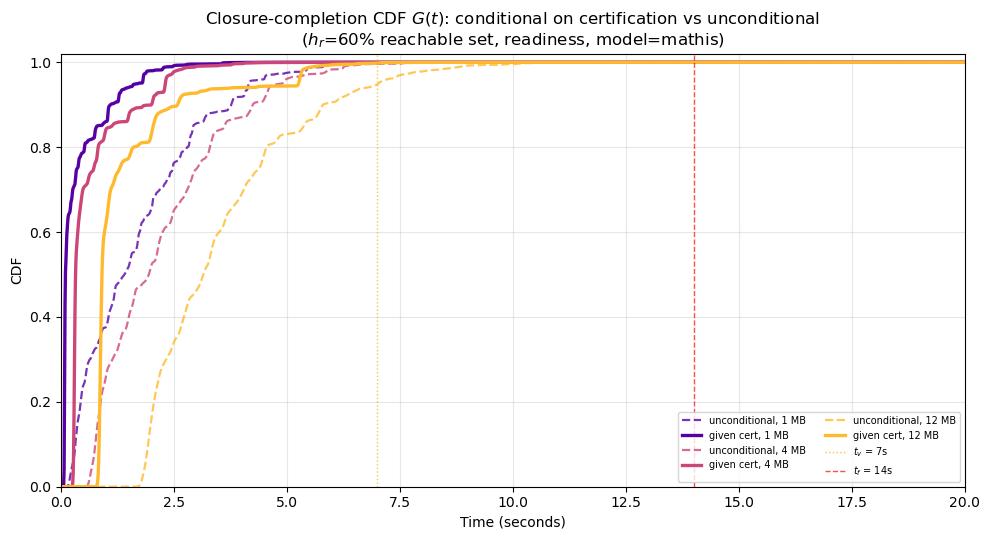

In [23]:
# §5.7.1 (cont.) Certification-conditional closure-completion CDF.
# Same pipeline as cdf_closure_completion (body diffusion -> fetch missing closure
# txs -> CPU), but the EB-body stage uses the distance-to-holder
# cdf_fetch_eb_body_given_cert instead of the producer-rooted cdf_fetch_eb_body.
# Being conditional on certification, the CPU stage uses the APPLY law by default
# (reapply_only=True): these nodes apply an already-certified EB, so reapplyTx
# suffices (scripts skipped) -- unlike the unconditional baseline, which has no
# certificate to trust and keeps the full-validation law.
# This is the closure-level analogue of the conditional body CDF above: it covers
# the honest-reachable set h_r and is a PARALLEL conditional model -- not the G
# substituted into F_{full|C} (see the scoping note above).


def cdf_closure_completion_given_cert(
    s_eb_tx_kb: float,
    include_validation: bool = True,
    th: float = 0.75,
    a: float = 0.25,
    h_r: float = 0.60,
    h_v: float = 0.75,
    n_samples: int = 3,
    max_hops: int = 6,
    reapply_only: bool = True,
) -> np.ndarray:
    """Certification-conditional closure-completion CDF G_cert(t): P(a random
    honest-reachable node holds the validated EB closure by t | EB certified).
    Mirrors cdf_closure_completion but replaces the body-diffusion stage with the
    conditional distance-to-holder cdf_fetch_eb_body_given_cert.

      include_validation=True  -> readiness     (body[1-hop closure] + CPU)
      include_validation=False -> delivery only (body + multi-hop closure fetch)

    reapply_only=True (default): the node applies an already-certified EB, so the
    CPU stage uses the apply law (reapplyTx for every tx, scripts skipped).  Set
    False to charge the full-validation law (mu_eff) instead -- e.g. for an
    apples-to-apples CPU comparison against the unconditional baseline.
    """
    body = cdf_fetch_eb_body_given_cert(th, a, h_r, h_v, n_samples, max_hops)
    if include_validation:
        return cdf_sequential(
            cdf_sequential(
                body, cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=True)
            ),
            cdf_process_eb_closure(s_eb_tx_kb, reapply_only=reapply_only),
        )
    return cdf_sequential(
        body, cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=False)
    )


def plot_closure_completion_conditional(
    sizes_kb=(1024, 4096, 12288),
    th=0.75, a=0.25, h_r=0.60, h_v=0.75,
    n_samples=3, max_hops=6,
    t_vote=7.0, t_diff_end=14.0, include_validation=True,
):
    """Compare the conditional closure-completion CDF G_cert(t) against the
    unconditional G = cdf_closure_completion across EB-closure sizes, with the
    p50/p99 completion times and the reach at the L_diff deadline."""
    set_network_model("mathis")
    h_c = certification_stake_floor(th, a, h_r, h_v)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(sizes_kb)))

    print(f"  closure-completion G(t): unconditional vs given-cert "
          f"(h_c={h_c:.0%}, h_r={h_r:.0%}, model={NETWORK_MODEL})")
    print(f"  {'S_EB_tx':>8}  {'p50 unc':>8} {'p50 cert':>9}  "
          f"{'p99 unc':>8} {'p99 cert':>9}  {'G_unc(t_f)':>10} {'G_cert(t_f)':>11}")
    print("  " + "-" * 76)
    for s_kb, color in zip(sizes_kb, cmap):
        g_unc = cdf_closure_completion(s_kb, include_validation)
        g_cert = cdf_closure_completion_given_cert(
            s_kb, include_validation, th, a, h_r, h_v, n_samples, max_hops)
        ax.plot(TIMES, g_unc, lw=1.6, ls="--", color=color, alpha=0.8,
                label=f"unconditional, {s_kb / 1024:.0f} MB")
        ax.plot(TIMES, g_cert, lw=2.4, color=color,
                label=f"given cert, {s_kb / 1024:.0f} MB")
        print(f"  {s_kb / 1024:>5.0f} MB  "
              f"{_cdf_quantile(g_unc, 0.50):>7.2f}s {_cdf_quantile(g_cert, 0.50):>8.2f}s  "
              f"{_cdf_quantile(g_unc, 0.99):>7.2f}s {_cdf_quantile(g_cert, 0.99):>8.2f}s  "
              f"{success_within(g_unc, t_diff_end):>10.4f} "
              f"{success_within(g_cert, t_diff_end):>11.4f}")

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v$ = {t_vote:g}s")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f$ = {t_diff_end:g}s")
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("CDF")
    ax.set_title(
        "Closure-completion CDF $G(t)$: conditional on certification vs unconditional\n"
        f"($h_r$={h_r:.0%} reachable set, "
        f"{'readiness' if include_validation else 'delivery-only'}, "
        f"model={NETWORK_MODEL})")
    ax.legend(loc="lower right", fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()


plot_closure_completion_conditional()

### 5.7.2 Bounded resource waste per EB (fine-grained fetching) *(Panagiotakos)*

Block #2 of the optimisation note asks for a *second* guarantee on top of the
2-hop reach of §5.7.1: that the **resources wasted per EB generation
opportunity are bounded**, despite (a) EBs being **equivocable** (one generation
opportunity, two validly-signed bodies) and (b) speeding up delivery meaning the
body is pulled from several peers at once without double-downloading it.

**Equivocation (Leios paper).**  Download only **one** body per generation
opportunity — the one whose *header* arrived first — and delay voting until the
equivocation-detection window has passed.  Worst case: **1 body + 2 headers**.

**Stake-based sampling (§5.7.1).**  Past $L_\text{vote}$ a node pulls the full
EB from each of its $s=3$ sampled BLP advertisers → **3 bodies**.  With the
equivocation cost the floor is **4 bodies + 2 headers** per opportunity.

**Fine-grained fetching.**  The producer splits the body into $k$ parts and
publishes the **Merkle root in the header**; a node fetches *different* parts
from *different* peers, each part self-verified by its inclusion proof.  This
(i) caps the resource commitment per peer and (ii) requests from all peers in
parallel so one slow/malicious peer cannot stall delivery.  Nearing completion
the node re-requests the last few parts from several of its $m$ peers; the tail
waste is bounded by $m^2\,|EB|/k$ (each of the last $m$ parts may, worst case,
be delivered by all $m$ peers).

**Total worst-case cost per EB opportunity** (note's result):

$$\Bigl(4+\tfrac{m^2}{k}\Bigr)\;\text{EB bodies}\;+\;2\;\text{EB headers}\;+\;(k+m^2)\;\text{Merkle inclusion proofs.}$$

In bytes, with body size $B$, header size $H$, and a binary-Merkle path of
$\lceil\log_2 k\rceil$ sibling hashes of $h=32$ B,

$$\text{cost}(k)\;=\;\Bigl(4+\tfrac{m^2}{k}\Bigr)B\;+\;2H\;+\;(k+m^2)\,\lceil\log_2 k\rceil\,h.$$

The body-waste term $m^2B/k$ **falls** with $k$ while the proof overhead grows
with $k$, so there is an optimal split $k^\star$ (roughly $k^\star\sim m\sqrt{B/h}$).
The cell below minimises $\text{cost}(k)$ for representative $m$ and EB-body sizes.

*Caveats.*  Worst-case accounting; $k$ is governance-tunable and the realistic
optimum depends on network details not modelled here.  The 4-body floor assumes
all 3 sampled BLPs both advertise and are pulled in full.

  EB body = 512 kB, header = 1024 B, hash = 32 B
     m     k*       total  bodies-eq       body    proofs
  ------------------------------------------------------------


     5    224    2170.9 kB      4.24x   2105.1kB    63.7kB


    10    422    2321.7 kB      4.53x   2169.3kB   150.3kB
    20    800    2690.0 kB      5.25x   2304.0kB   384.0kB


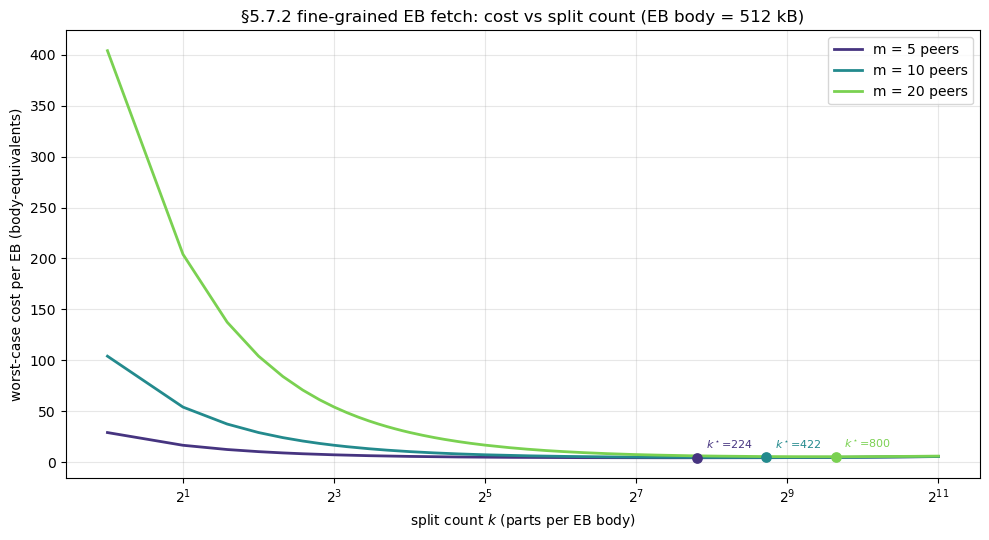

In [24]:
# §5.7.2 Bounded resource waste per EB opportunity (Panagiotakos, block #2).
# Worst-case download cost (note's formula):
#   (4 + m^2/k) EB bodies + 2 EB headers + (k + m^2) Merkle inclusion proofs.
# In bytes, body B, header H, binary-Merkle sibling hash h=32 B, depth ceil(log2 k):
#   cost(k) = (4 + m^2/k)*B + 2*H + (k + m^2)*ceil(log2 k)*h.
# Body-waste term m^2*B/k falls with k; proof overhead grows with k -> optimum k*.

MERKLE_HASH_BYTES = 32          # one sibling hash on the inclusion path
EB_HEADER_BYTES = 1024          # small, constant (Assumption 2)


def _merkle_depth(k: int) -> int:
    """Inclusion-path length for a binary Merkle tree over k parts."""
    return max(1, int(np.ceil(np.log2(max(k, 2)))))


def eb_fetch_cost(k: int, m: int, body_bytes: float,
                  header_bytes: float = EB_HEADER_BYTES,
                  hash_bytes: int = MERKLE_HASH_BYTES) -> dict:
    """Worst-case per-EB download cost (bytes) for a k-part fine-grained fetch over
    m peers; returns total, the body/header/proof components, and the cost in
    EB-body-equivalents."""
    body = (4.0 + m * m / k) * body_bytes
    header = 2.0 * header_bytes
    proofs = (k + m * m) * _merkle_depth(k) * hash_bytes
    total = body + header + proofs
    return dict(k=k, total=total, body=body, header=header, proofs=proofs,
                bodies_equiv=total / body_bytes)


def optimal_k(m: int, body_bytes: float, k_max: int = 2048, **kw) -> dict:
    """Argmin over k in [1, k_max] of eb_fetch_cost."""
    return min((eb_fetch_cost(k, m, body_bytes, **kw) for k in range(1, k_max + 1)),
               key=lambda d: d["total"])


def plot_eb_fetch_cost(body_kb=512, peers=(5, 10, 20), k_max=2048):
    """Worst-case per-EB cost (in body-equivalents) vs split count k, optimum k*
    marked, for several peer counts m."""
    B = body_kb * 1000.0
    ks = np.arange(1, k_max + 1)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.8, len(peers)))

    print(f"  EB body = {body_kb} kB, header = {EB_HEADER_BYTES} B, "
          f"hash = {MERKLE_HASH_BYTES} B")
    print(f"  {'m':>4}  {'k*':>5}  {'total':>10}  {'bodies-eq':>9}  "
          f"{'body':>9} {'proofs':>9}")
    print("  " + "-" * 60)
    for m, color in zip(peers, cmap):
        totals = np.array([eb_fetch_cost(int(k), m, B)["total"] for k in ks])
        ax.plot(ks, totals / B, color=color, lw=2, label=f"m = {m} peers")
        best = optimal_k(m, B, k_max=k_max)
        ax.scatter([best["k"]], [best["total"] / B], color=color, zorder=5, s=45)
        ax.annotate(f"$k^\\star$={best['k']}", (best["k"], best["total"] / B),
                    textcoords="offset points", xytext=(6, 6), fontsize=8, color=color)
        print(f"  {m:>4}  {best['k']:>5}  {best['total']/1e3:>8.1f} kB  "
              f"{best['bodies_equiv']:>8.2f}x  "
              f"{best['body']/1e3:>7.1f}kB {best['proofs']/1e3:>7.1f}kB")

    ax.set_xscale("log", base=2)
    ax.set_xlabel("split count $k$ (parts per EB body)")
    ax.set_ylabel("worst-case cost per EB (body-equivalents)")
    ax.set_title(f"§5.7.2 fine-grained EB fetch: cost vs split count "
                 f"(EB body = {body_kb} kB)")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()
    plt.show()


plot_eb_fetch_cost()

### 5.7.3 Protocol-storm & message-burst mitigation *(Panagiotakos)*

Block #3 targets the freshest-first policy's worst weakness: because it reverses
the natural oldest-first order, **higher-priority blocks generated *after* a
certified EB can keep inhibiting its diffusion** through the critical window.
Bursts arise two ways — benign **protocol storms** (random honest block clusters)
and **adversarial late release**.

**Notation.**  $p(k,t)$ = probability exactly $k$ honest blocks are produced in
$t$ slots $=$ Poisson$(f\,t)$, $f$ the active-slot rate; and
$L:=3L_\text{hdr}+L_\text{vote}+L_\text{diff}$ (= 14 slots here).

**Original protocol.**  Every block produced in the $L$ slots after the target
EB outranks it (freshest-first), so the count of higher-priority honest blocks
before the end of $L_\text{diff}$ is distributed as $p(k,L)$.

**Mitigation.**  Reverse to **oldest-first inside the critical window** (so
storms are observable before voting) and keep **freshest-first after** it:

- *New diffusion-priority rule #1* (threshold $T$): (i) two blocks both older
  than $T$ → the fresher wins; (ii) two blocks both within the last $T$ slots →
  the **older** wins; (iii) one of each → the one in the last $T$ slots wins.
  So the *recent* bucket outranks the *old* bucket, oldest-first within recent,
  freshest-first within old.
- *New voting rule* $(S,I,W)$: if a party sees **more than $S$** valid headers
  produced in the most recent $I$ slots, it **abstains** for the next $W$ slots.

**Storm bound** (for $I:=3L_\text{hdr}+L_\text{diff}$, $T:=L$, $W:=L_\text{vote}$).
For a *certified* EB the number of higher-priority honest blocks inhibiting it
during $L_\text{diff}$ is at most

$$\begin{cases}p(k,L_\text{diff}), & k\le S,\\[2pt] 0, & k>S.\end{cases}$$

Two wins: the interference window **shrinks $L\to L_\text{diff}$** (here $14\to7$
slots, halving the expected count $fL\to fL_\text{diff}$), and **storms above $S$
are eliminated** — more than $S$ blocks would have made every honest party
abstain, so the EB could not have been certified.  *(The note flags the
$p(k,L_\text{diff})$ form as "[TODO: check]"; reproduced here as stated.)*

**Adversarial EBs.**  *New diffusion-priority rule #2*: if a node first sees an
EB header $\ge 2L_\text{hdr}$ slots after its generation slot it **deprioritises**
that EB until it is older than $L$ (no honest party will vote for it, by
equivocation detection).  Combined with the storm rule the same bound holds with
$p(k,L)$ now covering **honest *and* adversarial** higher-priority blocks.

**The cost — abstention.**  An honest EB may fail to be upvoted with probability
at most $1-\sum_{i=0}^{S}p(i,L)$.  Choosing $S$ trades storm robustness against
this optimistic-case loss: too small ⇒ frequent abstention, too large ⇒ weaker
storm protection.

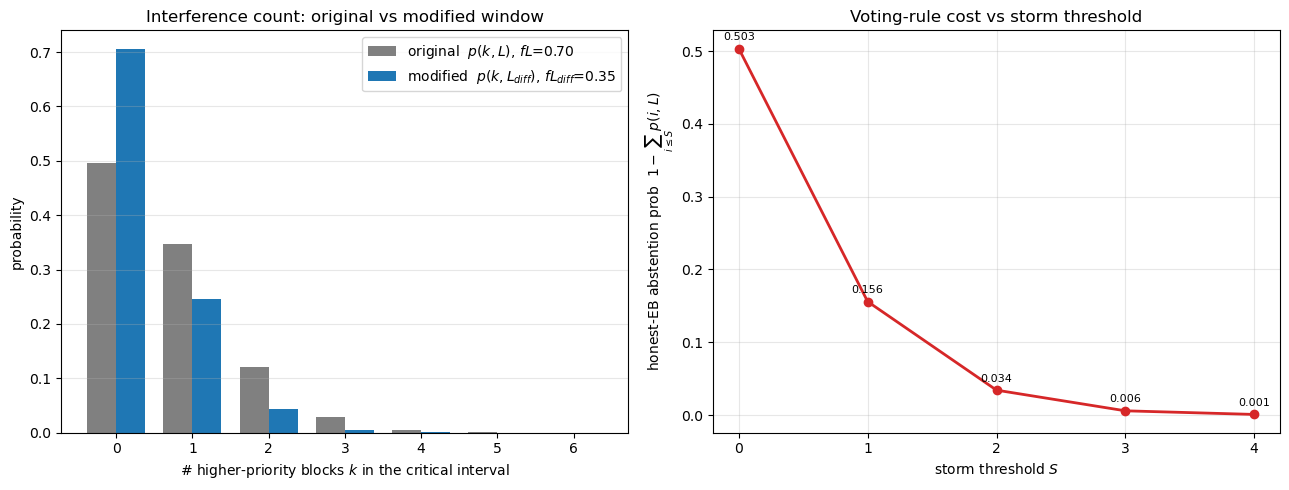

  f=0.0500/slot   L=14 slots (fL=0.700)   L_diff=7 slots (fL_diff=0.350)
  P(>=1 interfering block): original 0.503  ->  modified 0.295
    S   abstention 1-sum p(i,L)     storms>S
    0                    0.5034   eliminated
    1                    0.1558   eliminated
    2                    0.0341   eliminated
    3                    0.0058   eliminated
    4                    0.0008   eliminated


In [25]:
# §5.7.3 Protocol-storm mitigation (Panagiotakos, block #3).
# p(k,t) = Pr[exactly k honest blocks in t slots] = Poisson(f*t); f = active-slot
# rate (1/20, the same coefficient used for p_interrupted in §4.6).
# Original protocol: #higher-priority blocks before end of L_diff ~ p(k, L),
#   L = 3*l_hdr + l_vote + l_diff.
# Modified protocol (I=3l_hdr+l_diff, T=L, W=l_vote): bound p(k, L_diff) for k<=S,
#   0 for k>S -> window shrinks L -> L_diff and storms above S vanish.
# Abstention cost of the voting rule: <= 1 - sum_{i<=S} p(i, L).

from scipy.stats import poisson as _poisson

F_SLOT = 1.0 / 20.0                      # honest block / active-slot rate
L_HDR, L_VOTE, L_DIFF = 1, 4, 7
L_CRIT = 3 * L_HDR + L_VOTE + L_DIFF     # = 14 slots


def storm_pmf(t_slots, f=F_SLOT, k_max=8):
    """p(k, t) = Poisson(f*t) over k = 0..k_max."""
    ks = np.arange(0, k_max + 1)
    return ks, _poisson.pmf(ks, f * t_slots)


def abstention_prob(S, t_slots=L_CRIT, f=F_SLOT):
    """1 - sum_{i=0}^{S} p(i, t): prob an honest EB is suppressed by the (S,I,W)
    voting rule (interval length t = L for the W=L_vote variant)."""
    return float(1.0 - _poisson.cdf(S, f * t_slots))


def plot_protocol_storm(f=F_SLOT, k_max=6, S_grid=range(0, 5)):
    """Left: interference pmf, original p(k,L) vs modified p(k,L_diff) (window
    L -> L_diff).  Right: honest-EB abstention prob 1 - sum_{i<=S} p(i,L) vs S."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

    ks, p_orig = storm_pmf(L_CRIT, f, k_max)
    _, p_mod = storm_pmf(L_DIFF, f, k_max)
    width = 0.38
    axL.bar(ks - width / 2, p_orig, width, color="gray",
            label=f"original  $p(k,L)$, $fL$={f*L_CRIT:.2f}")
    axL.bar(ks + width / 2, p_mod, width, color="C0",
            label=f"modified  $p(k,L_{{diff}})$, $fL_{{diff}}$={f*L_DIFF:.2f}")
    axL.set_xlabel("# higher-priority blocks $k$ in the critical interval")
    axL.set_ylabel("probability")
    axL.set_xticks(ks)
    axL.set_title("Interference count: original vs modified window")
    axL.grid(alpha=0.3, axis="y")
    axL.legend()

    Ss = list(S_grid)
    abst = [abstention_prob(S) for S in Ss]
    axR.plot(Ss, abst, "o-", color="C3", lw=2)
    for S, a in zip(Ss, abst):
        axR.annotate(f"{a:.3f}", (S, a), textcoords="offset points",
                     xytext=(0, 6), ha="center", fontsize=8)
    axR.set_xlabel("storm threshold $S$")
    axR.set_ylabel(r"honest-EB abstention prob  $1-\sum_{i\leq S}p(i,L)$")
    axR.set_xticks(Ss)
    axR.set_title("Voting-rule cost vs storm threshold")
    axR.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(f"  f={f:.4f}/slot   L={L_CRIT} slots (fL={f*L_CRIT:.3f})   "
          f"L_diff={L_DIFF} slots (fL_diff={f*L_DIFF:.3f})")
    print(f"  P(>=1 interfering block): original {1-_poisson.pmf(0, f*L_CRIT):.3f}"
          f"  ->  modified {1-_poisson.pmf(0, f*L_DIFF):.3f}")
    print(f"  {'S':>3}  {'abstention 1-sum p(i,L)':>24}  {'storms>S':>11}")
    for S in Ss:
        print(f"  {S:>3}  {abstention_prob(S):>24.4f}  {'eliminated':>11}")


plot_protocol_storm()

### 5.8 Adversarial committee

§5.7 with $\beta=0$ assumed an all-honest committee.  Suppose instead a fraction
$\beta$ of the committee **stake** is Byzantine (say $\beta = 0.25$): the
adversary controls $\beta M$ of the fixed committee's weight $M$ and the honest
SPOs the remaining $(1-\beta)M$; the honest node population shrinks to
$N_h = (1-\beta)N$.  The §5.7 derivation goes through unchanged — the
committee / quorum argument never touches the per-node arrival law $G$ — except
for the composition of the stake-weighted quorum function $Q$.  In both threat
models

$$F_{\text{full}\mid C}(t)\;=\;G(t)^{N_h}\cdot
\dfrac{Q\!\bigl(\min(G(t_v)/G(t),1)\bigr)}{Q\!\bigl(G(t_v)\bigr)}\qquad,$$

with $P(C)=Q(G(t_v))$, and the two models differ **only** in how the adversary's
$\beta M$ seats enter $Q$.  $\beta=0$ recovers §5.7.  Concretely, at honest
on-time probability $p$ the honest votes contribute mean $(1-\beta)Mp$ and
variance $(1-\beta)M_2\,p(1-p)$ to the vote total $V_\text{cert}$; the quorum
is $\theta=\tau\,S_\text{active}=\tau M/\sigma_c$ throughout ($\tau$ of the total
active stake).

#### (a) Active adversaries — vote without diffusing  *(the case that matters)*

This is the threat model that actually stresses **Security Assumption 1**.  The
adversaries cast their $\beta M$ stake-weighted votes *regardless* of whether
honest diffusion reached them — they may be the EB producer, or collude to obtain
the EB out-of-band — and the protocol cannot tell their votes from honest ones.
They are always "on time" ($p=1$), adding mean $\beta M$ and **zero added
variance** (their $\beta M$ seats are deterministic) to $V_\text{cert}$.
The honest seats then only need to top the quorum up to $\theta$, i.e. an
**expected $(\tau/\sigma_c-\beta)M$** honest on-time votes instead of
$(\tau/\sigma_c)M$.  This **weakens the conditioning** — an EB can certify while
*fewer honest nodes have actually completed it* — so $F_{\text{full}\mid C}$
drops **below** the honest baseline: the certificate becomes a *weaker* witness
that closure diffusion has occurred.

As $\beta \uparrow \tau/\sigma_c$ the honest requirement
$(\tau/\sigma_c-\beta)M \to 0$: certification becomes certain ($Q\to 1$),
$F_{\text{full}\mid C}(t)\to G(t)^{N_h}$, and the certificate carries **no
information whatsoever** about honest diffusion.  The conditional guarantee
therefore degrades smoothly from the honest baseline at $\beta=0$ to the
*unconditional* honest-max curve as $\beta\uparrow\tau/\sigma_c$.

This is the practically important reading: **under an active adversary holding up
to a fraction $\tau/\sigma_c$ of the committee stake, certification provides
progressively less assurance that the EB closure has actually reached the honest
network**, and the §5.7 conditional curve is optimistic by a margin that grows
with $\beta$.

#### (b) Silent adversaries — withhold votes  *(benign reference)*

If the same $\beta$ adversaries instead simply **withhold** their votes, the
honest seats alone must meet the absolute quorum $\theta=\tau M/\sigma_c$ (the
adversary contributes nothing to $V_\text{cert}$).  Since honest stake tops out
at $(1-\beta)M$, this is feasible only if $(1-\beta)\ge\tau/\sigma_c$, i.e.
$\beta \le 1-\tau/\sigma_c \approx 0.24$ at $\tau=0.75,\ \sigma_c=0.99$ — so the
default $\beta=0.25$ sits *just past* the boundary and the silent quorum is
effectively unreachable ($P(C)\to 0$).  Withholding only makes certification
**rarer**, while each surviving certificate is *stronger* evidence, so
$F_{\text{full}\mid C}$ rises *above* the honest baseline.  Because this
direction *helps* Security Assumption 1, it is the benign case, included only as
the opposite bound.

#### Summary

| Model            | adversary seats in $V_\text{cert}$ | honest votes needed (mean) | Feasible when | Effect on $F_{\text{full}\mid C}$ |
|------------------|------------------------------------|----------------------------|---------------|-----------------------------------|
| **Active** (vote w/o diffusing) | $+\beta M$ always-on-time (zero added variance) | $(\tau/\sigma_c-\beta)M$ | $\beta < \tau/\sigma_c$ (info-free at $\beta\ge\tau/\sigma_c$) | **lower — erodes the guarantee** |
| Honest ($\beta=0$) | —                                | $(\tau/\sigma_c)M$        | always        | baseline                          |
| Silent (withhold) | —                                 | $(\tau/\sigma_c)M$ (from $\le(1-\beta)M$) | $\beta\le 1-\tau/\sigma_c$ | higher (benign)               |

The active curve is the security-relevant lower bound; the honest baseline and
the silent curve sit above it.  Because closure completion is strictly slower
than body receipt, these curves already sit lower than a body-only model would,
and the gap widens with $S_{EB\text{-}tx}$ — so the active-adversary curve at
large closure sizes is the binding case against Security Assumption 1.


  committee: CIP top-stake cover sigma_c=99% (K=923 of 2500 nodes, M_eff=466)
  M=923, tau=0.75, beta=0.25, t_f=14.0s, network=mathis
  quorum threshold = tau * total active stake = 699; active adversary adds ~beta*M = 231 votes
  S_EB_tx  model    P(C)        F_full|C(t_f)
  --------------------------------------------------
     1MB  active  1.000e+00   1.0000
     1MB  honest  1.000e+00   1.0000
     1MB  silent  5.345e-07   1.0000

     4MB  active  1.000e+00   1.0000
     4MB  honest  1.000e+00   1.0000
     4MB  silent  8.476e-06   1.0000

    12MB  active  1.000e+00   0.9993
    12MB  honest  1.000e+00   0.9990
    12MB  silent  8.994e-08   0.9996



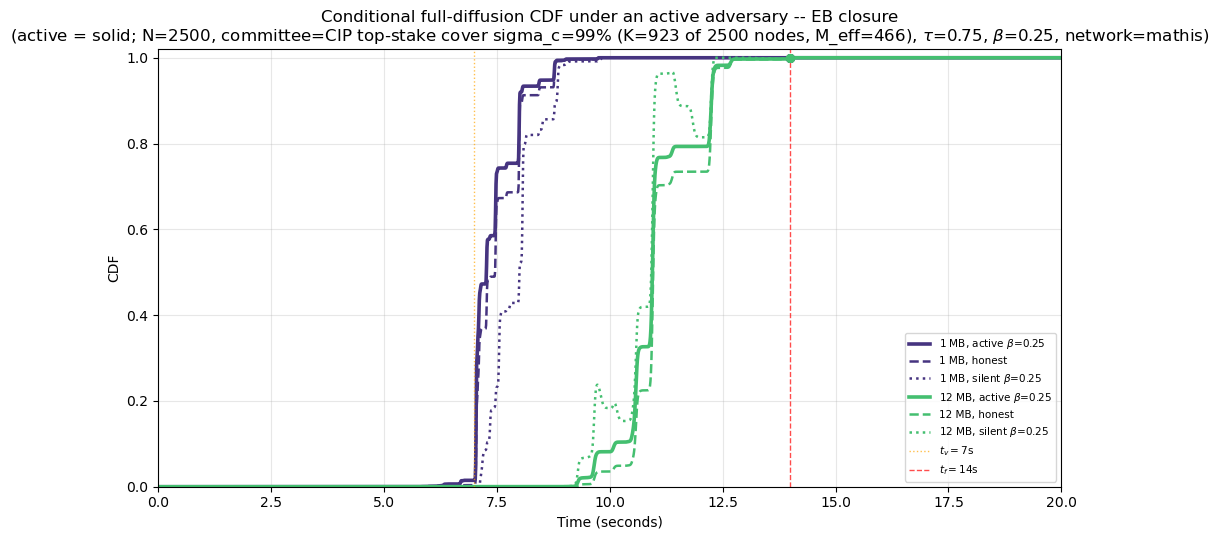

In [26]:
# §5.8: the adversarial-committee analysis reuses the §5.7 closure model -- the
# committee / quorum argument is independent of the per-node arrival law, so only
# the stake-weighted quorum (and N_h) change with beta.  The helpers are generic
# in the conditional-CDF function `cdf_fn` and default to the closure model, and
# accept the same `stake_cover` (sigma_c) parameter as §5.7.

def _adv_configs(beta):
    """(plot-label, beta, adversary, linestyle); active first to emphasise it."""
    return [
        ("active " + r"$\beta$=" + f"{beta:g}", beta, "active", "-"),
        ("honest", 0.0, "active", "--"),
        ("silent " + r"$\beta$=" + f"{beta:g}", beta, "silent", ":"),
    ]


def plot_full_diffusion_adversarial(
    cdf_fn=cdf_full_closure_diffusion_given_cert,
    sizes_kb=(1024, 12288),
    fmt_size=lambda s: f"{s / 1024:.0f} MB",
    model_label="EB closure",
    beta=0.25,
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
):
    """
    5.7: overlay F_{full|C}(t) for the security-relevant ACTIVE adversary against
    the honest baseline and the benign silent-adversary case, for several closure
    sizes.

    Active adversaries vote without diffusing (their beta*M stake-weighted seats
    lower the honest quorum requirement) -> curve sits BELOW honest: the
    certificate is a weaker witness of honest diffusion.
    Silent adversaries withhold votes (honest stake alone must reach the quorum
    tau*S_active, feasible only while (1-beta) >= tau/sigma_c) -> curve sits ABOVE
    honest (benign).
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.7, len(sizes_kb)))

    for s_kb, color in zip(sizes_kb, cmap):
        for label, b, adv, ls in _adv_configs(beta):
            cdf_cond = cdf_fn(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=b, adversary=adv,
                stake_cover=stake_cover,
            )
            lw = 2.6 if label.startswith("active") else 1.8
            ax.plot(TIMES, cdf_cond, lw=lw, color=color, ls=ls,
                    label=f"{fmt_size(s_kb)}, {label}")
            f_at = success_within(cdf_cond, t_diff_end)
            ax.scatter([t_diff_end], [f_at], color=color, zorder=5, s=30)

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v={t_vote:g}$s")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f={t_diff_end:g}$s")
    ax.set_xlim(0, 20); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(
        f"Conditional full-diffusion CDF under an active adversary -- {model_label}\n"
        f"(active = solid; N={n_nodes}, "
        f"committee={_committee_label(n_nodes, stake_cover)}, "
        + r"$\tau$=" + f"{tau}, " + r"$\beta$=" + f"{beta:g}, "
        f"network={NETWORK_MODEL})"
    )
    ax.legend(loc="lower right", fontsize=7.5)
    fig.tight_layout(); plt.show()


def print_full_diffusion_adversarial_summary(
    cdf_fn=cdf_full_closure_diffusion_given_cert,
    g_fn=cdf_closure_completion,
    sizes_kb=(1024, 4096, 12288),
    fmt_size=lambda s: f"{s / 1024:>4.0f}MB",
    size_col="S_EB_tx",
    beta=0.25,
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
):
    # active listed first (security-relevant); honest and silent as references.
    configs = [("active", beta, "active"),
               ("honest", 0.0, "active"),
               ("silent", beta, "silent")]
    M, _, S_active = _committee_moments(n_nodes, stake_cover)
    print(f"  committee: {_committee_label(n_nodes, stake_cover)}")
    print(f"  M={M:.0f}, tau={tau}, beta={beta}, t_f={t_diff_end}s, "
          f"network={NETWORK_MODEL}")
    print(f"  quorum threshold = tau * total active stake = {tau * S_active:.0f}; "
          f"active adversary adds ~beta*M = {beta * M:.0f} votes")
    print(f"  {size_col:<6s}  model    P(C)        F_full|C(t_f)")
    print("  " + "-" * 50)
    for s_kb in sizes_kb:
        G = g_fn(s_kb)
        g_tv = success_within(G, t_vote)
        for label, b, adv in configs:
            pC = float(_quorum_given_honest_ontime(
                g_tv, n_nodes, tau, b, adv, stake_cover=stake_cover))
            cdf_cond = cdf_fn(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=b, adversary=adv,
                stake_cover=stake_cover,
            )
            f_cond = success_within(cdf_cond, t_diff_end)
            print(f"  {fmt_size(s_kb)}  {label:<6s}  "
                  f"{pC:.3e}   {f_cond:.4f}")
        print()


# Conservative reference network model, matching the §5.7 baseline plot.
set_network_model("mathis")
print_full_diffusion_adversarial_summary()
plot_full_diffusion_adversarial()


### 5.9 Size-aware *dynamic* $L_\text{diff}$ — design sketch *(idea)*

The §5.7 deadline $L_\text{diff}$ is a single protocol constant, so it must be
sized for the **worst-case** EB closure.  But the conditional reach
$F_{\text{full}\mid C}(t)$ completes far sooner for small closures than for
large ones, so a fixed $L_\text{diff}$ makes every sub-maximal EB wait longer
than it needs to.  Inverting $F_{\text{full}\mid C}$ — the smallest diffusion
deadline $t_f$ (hence $L_\text{diff}=t_f-t_v$) at which a certified EB reaches
**all** honest nodes with probability $\ge$ target — shows the requirement is
essentially **affine in closure size** (mathis, target $0.999$, with the §5.7.x
reapply-only apply law):

| closure | min $L_\text{diff}$ (→ 0.999) |
|--------|------|
| 0.5 MB | 2.5 s |
| 2 MB   | 3.2 s |
| 4 MB   | 4.0 s |
| 8 MB   | 5.5 s |
| 12 MB  | **7.0 s** |
| 16 MB (cap) | 8.5 s |

The current fixed $L_\text{diff}=7$ is exactly the **12 MB** requirement: smaller
EBs overpay by up to $\approx4.5$ s, and the 16 MB hard cap (16,000 tx-refs) is
actually **under**-served by 7 s.

#### The idea

Carry the **exact closure size** as a new signed field in the **EB header**, and
make the diffusion window a deterministic protocol function of it,
$L_\text{diff}=f(\text{size})$, evaluated identically by every node.

**Why the size belongs in the header (and is trustworthy).**  The EB producer
builds its proposal from transactions it has **already validated** out of its
mempool, so it knows every referenced tx and its exact byte length — it can
declare the precise closure size.  Crucially the claim is **pinned by the body,
not independently forgeable**: each reference is a *hash*, which commits to the
exact bytes of its preimage, so the true closure size is a deterministic
function of the committed reference set.  A producer cannot misrepresent the size
of any individual referenced tx — it can only choose *which* txs to include
(i.e. how big its own EB is, which is not an attack).  The header field is thus
an **early, binding announcement** of a quantity the body already fixes.

**Verification is a-posteriori but free, and misdeclaration is
self-defeating.**  A node fetches the closure anyway to validate / apply it; at
that point it checks declared $=$ actual and **rejects on mismatch** (same
posture as the §5.7.2 equivocation handling).  Hence:

- **Under-declare** (claim small → grab a short window): every node that
  actually receives the closure detects the lie and refuses to vote on / relay
  it, so the EB fails to gather on-time votes and does not certify — a liveness
  self-harm for the producer, **no safety break**.
- **Over-declare**: merely wastes the producer's own latency.

So honest declaration is the only self-consistent strategy.  The one operational
subtlety is *ordering*: nodes **act on** the declared window before they can
**confirm** it — acceptable precisely because cheating is self-defeating.

#### Bucket schedule

Use a small set of discrete **size classes** rather than a continuous per-byte
function: it keeps the grinding surface tiny, keeps the security analysis
tractable (one $F_{\text{full}\mid C}$ curve per class), and lets the **top
class equal the true worst-case** $L_\text{diff}$.  Then dynamic $L_\text{diff}$
is *strictly a latency win* for sub-maximal EBs and **never weaker** for the
largest.  The code below derives each class's slot budget by $\lceil\cdot\rceil$
of the requirement at the class's upper bound.

#### Caveats / open points

- **$L_\text{vote}$ — analysed separately below.** Validation must also
  finish by the *voting* deadline $t_v=3L_\text{hdr}+L_\text{vote}$; large
  closures do lower the on-time fraction $p_\text{validating}$, but the
  stake-weighted quorum absorbs it, so — perhaps surprisingly — $L_\text{vote}$
  need *not* grow with size for certification.  See "**Dynamic $L_\text{vote}$**"
  below.
- **Slot accounting.** The protocol currently treats $3+4+7=14$ slots as a fixed
  cadence; per-EB validity windows mean RB scheduling and "when may a cert be
  referenced" logic must tolerate variable deadlines — the main integration cost.
- **Conservative.** The $F_{\text{full}\mid C}$ curve is the i.i.d. model, which
  §5.7 flags as *pessimistic* (real per-node times are positively correlated),
  so these minimum windows are safe upper bounds; the true requirement is
  somewhat shorter.


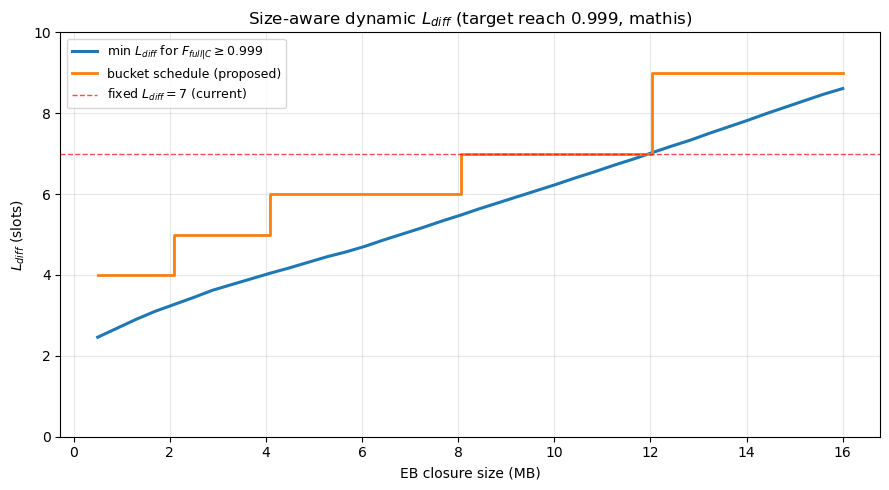

  bucket classes (MB upper bound -> L_diff slots): {2: 4, 4: 5, 8: 6, 12: 7, 16: 9}
   closure  min L_diff   bucket  vs fixed-7
  ------------------------------------------
      1 MB        2.7s       4s         -3s
      2 MB        3.2s       4s         -3s
      4 MB        4.0s       5s         -2s
      8 MB        5.5s       6s         -1s
     12 MB        7.0s       7s         +0s
     16 MB        8.6s       9s         +2s


In [27]:
# §5.9 (idea) Size-aware dynamic L_diff: minimum diffusion window per closure size.
# Inverts the §5.7 conditional reach F_{full|C}(t): for each closure size, find the
# smallest diffusion deadline t_f (hence L_diff = t_f - t_v) at which a certified EB
# reaches ALL honest nodes with probability >= target.  Reuses the reapply-only apply
# law baked into cdf_full_closure_diffusion_given_cert (§5.7).


def l_diff_required(s_eb_tx_kb, target=0.999, t_vote=7.0, **kw):
    """Smallest L_diff = t_f - t_vote with F_{full|C}(t_f) >= target for a closure
    of size s_eb_tx_kb (np.inf if unreached on the TIMES grid)."""
    cdf = cdf_full_closure_diffusion_given_cert(s_eb_tx_kb, t_vote=t_vote, **kw)
    i = np.searchsorted(cdf, target)
    if i >= len(TIMES):
        return float("inf")
    return float(TIMES[i]) - t_vote


# Protocol bucket schedule: discrete closure-size classes (upper bounds, MB).  Each
# class's L_diff is ceil(requirement at its upper bound) -> the smallest whole-slot
# budget that still meets the target for everything in the class.  The top class is
# the genuine worst case, so the scheme never weakens the largest EBs.
L_DIFF_BUCKETS_MB = (2, 4, 8, 12, 16)


def _derive_bucket_slots(target=0.999, t_vote=7.0):
    return tuple(
        int(np.ceil(l_diff_required(ub * 1024, target, t_vote)))
        for ub in L_DIFF_BUCKETS_MB
    )


def l_diff_for_size(s_eb_tx_kb, bucket_slots):
    """Deterministic L_diff = f(committed closure size): smallest class covering it."""
    mb = s_eb_tx_kb / 1024
    for ub, slots in zip(L_DIFF_BUCKETS_MB, bucket_slots):
        if mb <= ub:
            return slots
    return bucket_slots[-1]


def plot_dynamic_l_diff(target=0.999, t_vote=7.0):
    set_network_model("mathis")
    bucket_slots = _derive_bucket_slots(target, t_vote)

    sizes = np.linspace(0.5, 16.0, 40)  # MB
    req = [l_diff_required(s * 1024, target, t_vote) for s in sizes]
    step = [l_diff_for_size(s * 1024, bucket_slots) for s in sizes]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(sizes, req, lw=2.2, color="C0",
            label=f"min $L_{{diff}}$ for $F_{{full|C}} \\geq {target}$")
    ax.step(sizes, step, where="post", lw=2.0, color="C1",
            label="bucket schedule (proposed)")
    ax.axhline(7, color="red", ls="--", lw=1, alpha=0.7,
               label="fixed $L_{diff}=7$ (current)")
    ax.set_xlabel("EB closure size (MB)")
    ax.set_ylabel("$L_{diff}$ (slots)")
    ax.set_title(f"Size-aware dynamic $L_{{diff}}$ (target reach {target}, mathis)")
    ax.set_ylim(0, 10)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    print(f"  bucket classes (MB upper bound -> L_diff slots): "
          f"{dict(zip(L_DIFF_BUCKETS_MB, bucket_slots))}")
    print(f"  {'closure':>8} {'min L_diff':>11} {'bucket':>8} {'vs fixed-7':>11}")
    print("  " + "-" * 42)
    for s in (1, 2, 4, 8, 12, 16):
        req_s = l_diff_required(s * 1024, target, t_vote)
        b = l_diff_for_size(s * 1024, bucket_slots)
        print(f"  {s:>5} MB {req_s:>10.1f}s {b:>7}s {b - 7:>+10}s")


plot_dynamic_l_diff()


#### Dynamic $L_\text{vote}$ — and why it barely helps

The same lever applies to the *voting* deadline $t_v=3L_\text{hdr}+L_\text{vote}$:
a committee member casts an on-time vote only once it has **validated** the
closure (full-validation voter law, §5.7) by $t_v$.  Larger closures validate
slower, so the on-time fraction $p_\text{validating}=G_\text{voter}(t_v)$ falls —
from $0.998$ (1 MB) to $0.917$ (16 MB) at the current $t_v=7$.  The natural move
is to grow $L_\text{vote}$ with size.

**But the stake-weighted quorum already absorbs the lag.**  Certification needs
the on-time votes to carry $\tau/\sigma_c\approx0.758$ of committee weight; at
$p_\text{validating}=0.917$ the on-time mean $0.917\,M$ sits $\approx10\sigma$
above that threshold, so $p_\text{quorum}=Q(p_\text{validating})\approx1.0000$
across the **entire** $\le16$ MB range.  Inverting `compute_p_certified` (§4.6)
confirms the certification requirement is flat — and *below* the current value:

| closure | min $L_\text{vote}$ for $p_\text{quorum}\ge0.999$ | min $L_\text{vote}$ for $p_\text{validating}\ge0.99$ |
|--------|------|------|
| 1–4 MB | 1 | 3–4 |
| 8 MB   | 2 | 5 |
| 12 MB  | 2 | 6 |
| 16 MB  | 3 | 8 |

Two readings:

- **Certification target ($p_\text{quorum}$).**  $L_\text{vote}$ need **not** grow
  with size; even the 16 MB cap certifies with $t_v$ as low as $6$ (vs the current
  $7$).  Keyed here, a size-dependent $L_\text{vote}$ would only ever *shrink*.
- **Participation target ($p_\text{validating}$).**  If you instead require nearly
  *all* committee members to vote on time (robustness/margin, not certification),
  $L_\text{vote}$ *is* genuinely size-dependent, growing $3\to8$ slots
  ($t_v:6\to11$) — but that is over-provisioning relative to what certification
  needs.

**The interruption tension makes growth actively costly.**  Recall
$p_\text{cert}=(1-p_\text{interrupted})\,p_\text{quorum}$ with
$p_\text{interrupted}=1-e^{-f_\text{slot}L_\text{total}}$ and
$L_\text{total}=3L_\text{hdr}+L_\text{vote}+L_\text{diff}$.  Since
$p_\text{quorum}\approx1$, certification is dominated by interruption, which
*grows* with every extra slot:

| $L_\text{vote}$ (at $L_\text{diff}=7$) | $L_\text{total}$ | $p_\text{cert}$ (max) |
|----|----|----|
| 2 | 12 | 0.549 |
| 4 (current) | 14 | 0.497 |
| 6 | 16 | 0.449 |
| 8 | 18 | 0.407 |

**Guidance.**  For certification, $L_\text{vote}$ should be kept **tight**, not
grown — the dominant lever is minimising $L_\text{total}$, and quorum robustness
means small EBs could even use a *shorter* voting window.  Make $L_\text{vote}$
size-dependent only if high vote *participation* is a goal in itself; otherwise
the size-aware effort belongs in $L_\text{diff}$ (which genuinely must grow),
while $L_\text{vote}$ stays small.  The same interruption trade-off applies to
the $L_\text{diff}$ schedule above: every slot bought for diffusion costs a
little certification probability — so the buckets should be no larger than the
reach target actually requires.


#### Cutoff depends on $L_\text{total}$ alone — the split is irrelevant

A tempting next step is to *combine* a tightened $L_\text{vote}$ with the
$L_\text{diff}$ buckets to cut the Praos interruption ("cutoff") probability
$p_\text{interrupted}=1-e^{-f_\text{slot}L_\text{total}}$ further.  It does
**not** work, and the reason is worth recording so nobody re-proposes it.

Cutoff is a function of $L_\text{total}=t_v+L_\text{diff}=t_f$ **only** — the
whole window from EB generation to the end of diffusion.  But $t_f$ is the
*absolute* deadline by which all honest nodes must hold the closure, and the
reach requirement $F_{\text{full}\mid C}(t_f)\ge\text{target}$ — which for a
near-complete diffusion reduces to $G_\text{apply}(t_f)^N$ — pins $t_f$
**independently of where $t_v$ sits**.  Tightening $L_\text{vote}$ therefore does
not shrink the window; it just moves slots from the voting phase into the
diffusion phase, and $L_\text{diff}$ grows by the same amount to preserve $t_f$:

| $\le$MB | tightened $L_\text{vote}/L_\text{diff}$ | bucket-only $4/L_\text{diff}$ | $L_\text{total}$ | cutoff |
|----|----|----|----|----|
| 2  | 1 / 7  | 4 / 4 | 11 | 0.423 |
| 4  | 1 / 8  | 4 / 5 | 12 | 0.451 |
| 8  | 2 / 8  | 4 / 6 | 13 | 0.478 |
| 12 | 2 / 9  | 4 / 7 | 14 | 0.503 |
| 16 | 3 / 10 | 4 / 9 | 16 | 0.551 |

Both schedules give the **same** $L_\text{total}$, hence the same cutoff.  The
$L_\text{diff}$ buckets already sit on $\lceil t_f^{\text{reach}}\rceil$, so no
slack remains for an $L_\text{vote}$ tightening to reclaim
(`report_split_neutrality()` below reproduces this).

**Consequences.**

- The $L_\text{vote}/L_\text{diff}$ split is **cutoff-neutral** — only their sum
  matters.  Do not re-tune the split hoping to reduce interruption.
- The *only* lever that lowers cutoff is shrinking the absolute reach deadline
  $t_f$ itself, i.e. genuinely faster diffusion: the §5.7.1 stake-weighted BLP
  sampling, the reapply-only CPU law (already applied), faster-network
  assumptions, or smaller closures.  The §5.9 buckets capture this by *not
  over-provisioning* $t_f$ for small EBs ($0.503\to0.423$ at 2 MB) — that is the
  whole reduction available.
- Tightening $L_\text{vote}$ remains worthwhile for an unrelated reason: it pulls
  the *certification moment* $t_v$ earlier, so a valid certificate exists sooner
  (useful for downstream referencing) — it just does nothing for cutoff.


In [28]:
# §5.9 (cont.) Size-aware dynamic L_vote.  The voting deadline t_v = 3*L_hdr + L_vote
# bounds when a committee member can cast an ON-TIME vote: it must have validated the
# closure under the full-validation (voter) law by t_v.  Invert compute_p_certified
# (§4.6) for L_vote under two targets:
#   p_quorum     -- does the EB actually certify (what matters);
#   p_validating -- fraction of committee on-time (a stricter participation target).
# Finding: p_quorum is ~1.0 across the whole <=16 MB range (the stake-weighted quorum
# absorbs late voters), so L_vote keyed on certification need NOT grow with size --
# and enlarging any window raises L_total, hence p_interrupted, LOWERING p_cert.


def l_vote_required(s_eb_tx_kb, key="p_quorum", target=0.999, l_hdr=1,
                    l_vote_max=40, **kw):
    """Smallest integer L_vote with compute_p_certified[key] >= target (None if
    unreached).  key='p_quorum' = certification target; key='p_validating' =
    committee on-time participation target."""
    for lv in range(1, l_vote_max + 1):
        if compute_p_certified(s_eb_tx_kb, l_hdr=l_hdr, l_vote=lv, **kw)[key] >= target:
            return lv
    return None


def report_dynamic_l_vote(l_hdr=1, l_vote_now=4, f_slot=1.0 / 20.0):
    set_network_model("mathis")
    print(f"  Dynamic L_vote (l_hdr={l_hdr}; current L_vote={l_vote_now}, "
          f"t_v={3 * l_hdr + l_vote_now}).  At the current t_v:")
    print(f"  {'closure':>8} {'p_valid':>8} {'p_quorum':>9} | "
          f"{'Lvote(pq>=.999)':>16} {'Lvote(pv>=.99)':>15}")
    print("  " + "-" * 62)
    for s in (1, 2, 4, 8, 12, 16):
        d = compute_p_certified(s * 1024, l_hdr=l_hdr, l_vote=l_vote_now)
        a = l_vote_required(s * 1024, "p_quorum", 0.999, l_hdr)
        b = l_vote_required(s * 1024, "p_validating", 0.99, l_hdr)
        print(f"  {s:>5} MB {d['p_validating']:>8.4f} {d['p_quorum']:>9.4f} | "
              f"{str(a):>16} {str(b):>15}")

    print("\n  Interruption tension -- enlarging any window lowers p_cert "
          f"(p_quorum~1, L_diff=7):")
    print(f"  {'L_vote':>7} {'L_total':>8} {'p_interrupted':>14} {'p_cert(max)':>12}")
    for lv in (2, 4, 6, 8):
        L_total = 3 * l_hdr + lv + 7
        p_int = 1.0 - np.exp(-f_slot * L_total)
        print(f"  {lv:>7} {L_total:>8} {p_int:>14.4f} {1 - p_int:>12.4f}")


report_dynamic_l_vote()


def report_split_neutrality(reach_target=0.999, quorum_target=0.999, l_hdr=1,
                            f_slot=1.0 / 20.0):
    """Cutoff depends on L_total = t_v + L_diff = t_f only: tightening L_vote merely
    shifts slots into L_diff, conserving L_total.  Compares the tightened-L_vote
    schedule (L_diff re-derived against F_{full|C} at the tighter t_v) against the
    L_vote=4 bucket-only schedule -- identical L_total / cutoff."""
    set_network_model("mathis")
    bucket_only = {2: 4, 4: 5, 8: 6, 12: 7, 16: 9}  # §5.9 L_diff buckets (at L_vote=4)
    print(f"  {'<=MB':>5} | {'Lvote*':>6} {'Ldiff*':>6} {'Ltot':>5} {'cutoff':>7} || "
          f"{'Lvote':>5} {'Ldiff':>5} {'Ltot':>5} {'cutoff':>7}")
    print("  " + "-" * 66)
    for mb, ld_b in bucket_only.items():
        s = mb * 1024
        lv = l_vote_required(s, "p_quorum", quorum_target, l_hdr)
        t_v = 3 * l_hdr + lv
        cdf = cdf_full_closure_diffusion_given_cert(s, t_vote=float(t_v))
        ld = next(d for d in range(1, 21)
                  if success_within(cdf, t_v + d) >= reach_target)
        Lt, Lt_b = t_v + ld, 3 * l_hdr + 4 + ld_b
        cut = 1.0 - np.exp(-f_slot * Lt)
        cut_b = 1.0 - np.exp(-f_slot * Lt_b)
        print(f"  {mb:>5} | {lv:>6} {ld:>6} {Lt:>5} {cut:>7.4f} || "
              f"{4:>5} {ld_b:>5} {Lt_b:>5} {cut_b:>7.4f}")
    print("  -> identical L_total / cutoff: the L_vote/L_diff split is cutoff-neutral.")


report_split_neutrality()


  Dynamic L_vote (l_hdr=1; current L_vote=4, t_v=7).  At the current t_v:
   closure  p_valid  p_quorum |  Lvote(pq>=.999)  Lvote(pv>=.99)
  --------------------------------------------------------------
      1 MB   0.9978    1.0000 |                1               3
      2 MB   0.9973    1.0000 |                1               3


      4 MB   0.9965    1.0000 |                1               4
      8 MB   0.9862    1.0000 |                2               5


     12 MB   0.9482    1.0000 |                2               6


     16 MB   0.9170    1.0000 |                3               8

  Interruption tension -- enlarging any window lowers p_cert (p_quorum~1, L_diff=7):
   L_vote  L_total  p_interrupted  p_cert(max)
        2       12         0.4512       0.5488
        4       14         0.5034       0.4966
        6       16         0.5507       0.4493
        8       18         0.5934       0.4066
   <=MB | Lvote* Ldiff*  Ltot  cutoff || Lvote Ldiff  Ltot  cutoff
  ------------------------------------------------------------------
      2 |      1      7    11  0.4231 ||     4     4    11  0.4231
      4 |      1      8    12  0.4512 ||     4     5    12  0.4512
      8 |      2      8    13  0.4780 ||     4     6    13  0.4780


     12 |      2      9    14  0.5034 ||     4     7    14  0.5034
     16 |      3     10    16  0.5507 ||     4     9    16  0.5507
  -> identical L_total / cutoff: the L_vote/L_diff split is cutoff-neutral.


### Outcome diagram (schematic)

Visual flow of the two mutually exclusive RB validation paths after the bug
fix in §3.1.  This is the schematic referenced in §3 and §4.5.


In [29]:
def plot_outcome_diagram():
    """
    Schematic outcome diagram for the improved Linear Leios model.
    Two paths depending on whether the EB was certified.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(-0.5, 6.5)
    ax.axis("off")
    ax.set_title(
        "Improved Linear Leios – RB Validation Outcome Diagram\n"
        "(fixing the 'cert XOR txs' RB structure)",
        fontsize=12,
        pad=10,
    )

    props_box = dict(boxstyle="round,pad=0.4", facecolor="#e8f4fd", edgecolor="#2980b9")
    props_op = dict(boxstyle="circle,pad=0.3", facecolor="#fdebd0", edgecolor="#e67e22")
    props_start = dict(
        boxstyle="round,pad=0.4", facecolor="#d5f5e3", edgecolor="#27ae60"
    )
    props_end = dict(boxstyle="round,pad=0.4", facecolor="#fdedec", edgecolor="#e74c3c")
    props_choice = dict(
        boxstyle="round,pad=0.3", facecolor="#f9ebea", edgecolor="#c0392b"
    )

    def box(ax, x, y, txt, props, fontsize=8, width=1.8, ha="center"):
        ax.text(x, y, txt, ha=ha, va="center", fontsize=fontsize, bbox=props, wrap=True)

    # Start
    box(ax, 1.0, 3.0, "RB header\nreceived", props_start, fontsize=8)
    ax.annotate(
        "",
        xy=(2.2, 3.0),
        xytext=(1.9, 3.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Choice diamond
    box(ax, 2.8, 3.0, "cert?\np_cert", props_choice, fontsize=7)

    # Upper branch: CERT path
    ax.annotate(
        "",
        xy=(4.0, 5.0),
        xytext=(2.8, 3.5),
        arrowprops=dict(arrowstyle="->", color="#27ae60"),
    )
    ax.text(3.1, 4.5, "yes", fontsize=7, color="#27ae60")

    box(ax, 5.0, 5.5, "Fetch\ncertRB body\n(~8 kB, blended)", props_box, fontsize=7)
    box(ax, 5.0, 4.5, "Fetch EB body\n(≤512kB, blended)", props_box, fontsize=7)
    box(
        ax,
        7.0,
        4.5,
        "Fetch missing\nEB-closure txs\n(π₁·S_EB-tx, 1-hop)",
        props_box,
        fontsize=7,
    )

    ax.annotate(
        "",
        xy=(6.1, 4.5),
        xytext=(5.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # last-to-finish of cert_rb and eb_closure
    box(ax, 8.3, 5.0, "last\nto\nfinish", props_op, fontsize=7)
    ax.annotate(
        "",
        xy=(8.0, 5.3),
        xytext=(6.0, 5.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(8.0, 4.8),
        xytext=(7.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # then reapply
    box(ax, 9.5, 5.0, "Reapply EB\ntxs (≤16k tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(9.0, 5.0),
        xytext=(8.6, 5.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Lower branch: TX path
    ax.annotate(
        "",
        xy=(4.0, 1.0),
        xytext=(2.8, 2.5),
        arrowprops=dict(arrowstyle="->", color="#c0392b"),
    )
    ax.text(3.1, 1.5, "no", fontsize=7, color="#c0392b")

    box(ax, 5.0, 1.0, "Fetch txRB body\n(≤90kB, blended)", props_box, fontsize=7)
    box(ax, 7.5, 1.0, "Apply txs\n(≤100 tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(6.5, 1.0),
        xytext=(6.0, 1.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # End
    box(ax, 10.8, 3.0, "RB\nvalidated", props_end, fontsize=8)
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(9.5, 3.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(8.5, 1.2),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Annotations
    ax.text(
        0.1,
        6.2,
        "Key: cert path = RB holds EB certificate.  "
        "tx path = RB holds transactions.",
        fontsize=7,
        style="italic",
    )
    ax.text(
        0.1,
        5.9,
        "In the existing model these paths were incorrectly forced in parallel.",
        fontsize=7,
        color="red",
    )

    fig.tight_layout(); plt.show()


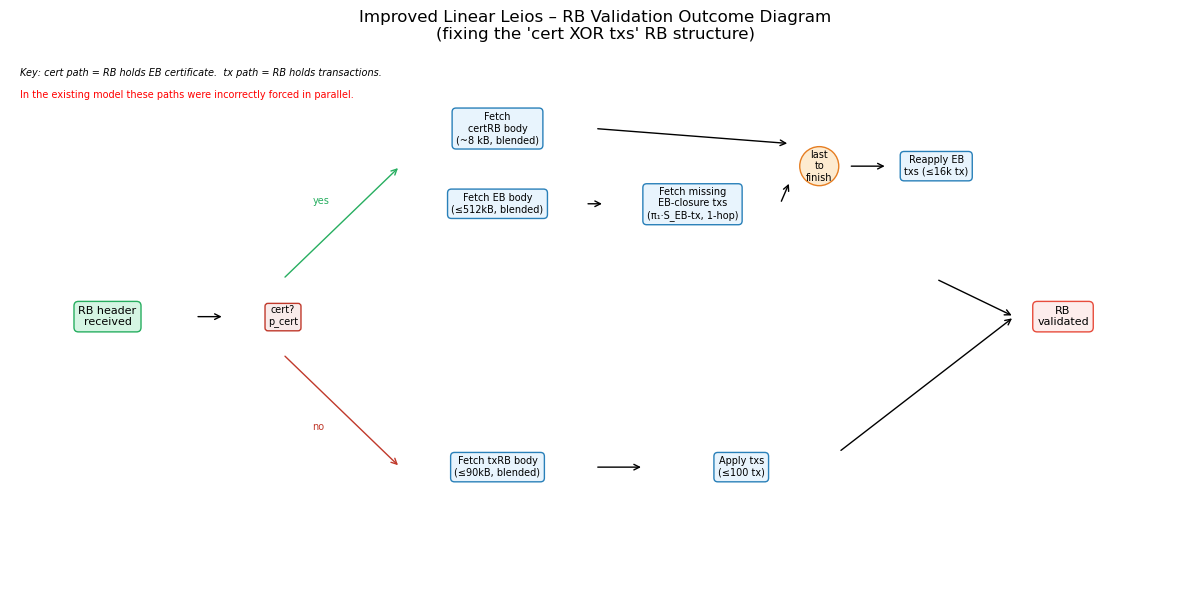

In [30]:
plot_outcome_diagram()


**`outcome_diagram`**

**What it shows.** A schematic (non-data) flow diagram of the two mutually
exclusive RB validation paths.  With probability $p_\text{cert}$ the RB is a
*certRB*: the node downloads the small RB header, fetches the EB body, applies
(or reapplies) the EB closure transactions, and verifies the certificate.  With
probability $1 - p_\text{cert}$ the RB is a *txRB*: the node downloads the
header and a ≤ 90 kB transaction payload and applies those transactions
directly.

**Why it matters.** This diagram is the visual summary of §3.1's bug fix.
The prior model forced *both* paths to run in parallel on every RB; this
diagram illustrates why that was wrong and what the correct probabilistic
choice model looks like.

## 6. Comparison with Prior Analysis

| Aspect                      | Prior model                         | Improved model              |
|-----------------------------|-------------------------------------|-----------------------------|
| RB structure                | Both tx + cert paths forced always  | Probabilistic choice p_cert |
| EB closure size (model)     | Implicit; N=2500 hardcoded          | Explicit sweep 0–12 MB      |
| Reapply distribution        | Scale mixture U(1,N): mean N/2 txs  | Fixed-N CLT: exactly N txs  |
| EB closure fetch            | Not modelled (TxCache only)         | 1-hop bulk transfer         |
| Certification probability   | Not computed; assumed fixed         | Computed from quorum model  |
| Per-tx apply time           | 10.60 ms (per-block mean)           | 0.507 ms/tx (tx-weighted)   |
| Per-tx reapply time         | 2.71 ms (per-block mean)            | 0.070 ms/tx (tx-weighted)   |
| Network transfer model      | Empirical Praos table (≤2 MB data)  | TCP slow-start + selectable steady-state (Mathis / CUBIC) |
| P(≤14s) in prior model      | 0.9740 (single point)               | Not directly comparable (different RB structure) |
| P_cert at 12 MB (Mathis)    | Not computed                        | 0.497 (at Praos cap)        |
| P_cert at 12 MB (CUBIC)     | Not computed                        | 0.497 (at Praos cap)        |

The prior analysis reported P(≤14s) = 0.974 for its (incorrect)
single-scenario model, which was cited as validation of the CIP parameters.
That figure was inflated by three independent errors: (a) the scale mixture
underestimating reapply time by 2×; (b) the RB structure bug mixing
mutually exclusive paths; and (c) the per-tx timing constants being
per-block means rather than per-tx costs (≈ 20–40× overstatement).

Under fully corrected assumptions, the CIP target of 12 MB is **robustly
feasible under both Mathis and CUBIC** at $\pi_1 = 1/6$ and below: CPU is
non-binding (single-core ceiling ≈ 38 MB); the 2 MB missing-closure fetch
over 268 ms RTT (long-haul) takes ≈ 4.4 s under Mathis and ≈ 2.0 s under
CUBIC — both within the 7 s voter deadline.  $P_\text{validating} \geq 0.95$
under either model, $P_\text{quorum} \approx 1.0$, and $P_\text{cert}$
stays at the Praos cap of $\approx 0.497$.

## 7. Limitations and Assumptions

1. **1-hop approximation for EB closure fetch.** The model assumes each node
   can obtain missing transactions from its upstream peer in a single hop.
   If the raw transactions making up the closure have *not* pre-diffused via
   tx-submission (e.g., under adversarial withholding or heavy load), the full
   closure must traverse the blended multi-hop network.  At 12 MB this
   full-blended diffusion succeeds within 14 s only **14%** of the time under
   Mathis and **99%** under CUBIC (§5.2).  The corresponding voter pipeline
   still yields $P_\text{cert} \approx 0$ under either model — the 7 s voter
   deadline and 75% quorum threshold are both tighter than the 14 s network
   delivery alone, so even CUBIC's near-100% network-delivery rate doesn't
   prevent the quorum failure.  See **§5.3 "Full-blended worst case"** for
   the full derivation and the $\alpha$-mixture formulation.  The 1-hop
   model is only valid when pre-diffusion via tx-submission is effective.

2. **Average transaction size = 1 kB.** The CIP uses 2 kB in some places. At
   2 kB/tx, a 12 MB closure has half as many tx hashes (so a smaller EB
   body) and half the missing-closure-fetch size for cache misses.  Since
   12 MB is already feasible at 1 kB/tx, the 2 kB/tx case
   would only widen the feasibility margin.

3. **Single scalar $\pi_1$ rather than a Markov chain fit.**  §5.5 and
   `pi1_derivation.ipynb` now provide an empirically-derived steady-state
   value ($\pi_1 \approx 0.06$ cross-region BAU mean, 0.085 worst-pair),
   replacing the prior model's hand-chosen $p = 0.5,\, q = 0.9$ Markov
   parameters (which yielded $\pi_1 = 1/6$).  What remains a limitation is
   that we use the steady-state mean only, without re-fitting the
   underlying $(p, q)$ to the tx-arrival time series — temporal
   stickiness in mempool divergence is therefore not captured.  §5.5
   sweeps $\pi_1$ to bound the residual uncertainty.

4. **Fixed binary miss fraction — no heterogeneity across nodes.**
   The TxCache model collapses to a single constant: each node is either a
   *cache hit* (probability $\pi_2 = 5/6$, holds the full closure, 1 ms lookup)
   or a *cache miss* (probability $\pi_1 = 1/6$, must fetch exactly
   $\pi_1 \cdot S_{EB-tx}$ from one hop).  There is no state in between.
   In reality, nodes have a continuous distribution of miss fractions depending
   on network position, uptime, and mempool composition; in particular, a node
   with a cold or empty mempool could be missing the **entire** closure.

   For the CIP-0164 target $S_{EB-tx} = 12$ MB, the assumed cache-miss
   fetch is $\pi_1 \times 12\,\text{MB} \approx 2\,\text{MB}$.  A node
   missing 100% of the closure would instead need to fetch the full
   12 MB — approximately 6× more data.  Over a long-haul link this 1-hop
   transfer takes ≈ 3.6 s under CUBIC and ≈ 23.7 s under Mathis;
   combined with the EB body fetch (~1 s blended) and CPU reapply
   (~1.8 s), a cold-mempool node sits at ~6.5 s total under CUBIC
   (tight but inside the 7 s deadline) and well over the deadline under
   Mathis.  The fixed-fraction assumption therefore overstates
   feasibility for cold-mempool nodes under Mathis; under CUBIC the
   margin is narrower but the cold-node case is still mostly
   recoverable.

5. **No adversarial behaviour.** The model assumes honest nodes that always
   diffuse transactions promptly via tx-submission before the EB is produced.
   An adversary that deliberately withholds transactions from tx-submission
   invalidates the 1-hop approximation and could force the full multi-hop
   diffusion scenario, reducing the feasible range significantly.

6. **TCP throughput model assumptions.**
   The transfer-time model uses TCP slow start from an initial cwnd of 10 MSS
   (14 600 B), capped at a model-specific steady-state window $W_\text{ss}$
   (Mathis: 146 000 B; CUBIC: 1 538 590 B at $p = 10^{-4}$).  Common
   assumptions:

   - *MSS = 1460 B, cwnd₀ = 10 MSS.*  Modern Linux kernels use IW10 (RFC 6928);
     TLS adds a 5-byte record header reducing effective MSS slightly.  Idle-
     restart and connection reuse can lower the effective cwnd₀.
   - *One-way delays.*  Short (6 ms), medium (34.5 ms), and long (134 ms),
     derived from Table 1 of the Praos paper (`PraosModel.pdf`) which gives
     RTTs of 12 / 69 / 268 ms for these distance categories (we halve to
     get OWDs).  The long RTT (268 ms) reflects typical intercontinental
     paths; true 95th-percentile South America–Asia-Pacific paths (which
     have no direct undersea cable) may reach 300–400 ms RTT, so the long
     category is mildly optimistic for that specific worst case.  A higher
     OWD increases the number of slow-start RTTs before reaching
     $W_\text{ss}$ and dominates transfer time for large sizes.
   - *1 Gbit/s interface cap.*  Applies only if the interface is the
     bottleneck; SPO nodes with lower-bandwidth connections would see worse
     numbers.  The bandwidth-delay product $\text{BDP} = 125\,\text{MB/s}
     \times \text{RTT}$ is well above either model's $W_\text{ss}$ at
     $p = 10^{-4}$ on every distance category, so the BDP cap is inactive.
   - *Persistent TCP, no handshake.*  Each fetch is assumed to use an existing
     long-lived TLS connection; cold-start RTTs (TCP 3-way + TLS handshake)
     are not included.

   Both throughput models share these assumptions; they differ only in the
   functional form of $W_\text{ss}$ (Mathis: $\propto p^{-1/2}$; CUBIC:
   $\propto p^{-3/4}$).  See §5.4 for the loss-rate sensitivity and the
   five real-world caveats (rwnd lag, short-flow slow-start dominance,
   bufferbloat, $p$ at high-traffic SPO paths, CUBIC's Reno-friendly fallback)
   that further blur the boundary between the two models.

   The full-blended diffusion results at $S_{EB-tx} > 4$ MB are the most
   model-sensitive: at 12 MB, $P(\leq 14\,\text{s})$ is 14% under Mathis
   and 99% under CUBIC.

7. **No FFD (Freshest First Delivery).** Following the prior report, FFD is
   not modelled; in practice it can delay older EBs in favour of newer ones.

8. **The voting deadline computation uses `3·L_hdr + L_vote = 7s`.** This
   implies three pipeline stages each requiring L_hdr = 1 slot before the voter
   can start. If the actual voter deadline is shorter (e.g., `L_hdr + L_vote =
   5s`), the feasible S_EB_tx is correspondingly smaller.

9. **Normality (CLT) assumption on per-tx and vote-count distributions.**
   The model uses Normal-CDF approximations in two places: the total per-EB
   CPU validation time is treated as
   $T_{\text{CPU}} \sim \mathcal{N}(N \mu_{\text{eff}}, N \sigma^2_{\text{eff}})$
   (Fixed-N CLT, §4.5), and the
   committee vote count is treated as
   $V \sim \mathcal{N}(\mu_V, \sigma_V^2)$ (CLT over the committee's
   independent on-time indicators, §4.6).  Both rely on the underlying distributions being
   well-behaved enough that the CLT converges well at the tested $N$.  We
   have only limited per-transaction telemetry to judge this: `block-edf.csv`
   provides per-bin *mean* apply/reapply times rather than individual tx
   times.  The evidence we *do* have — from
   `timing_derivation.ipynb` §4 (sanity-check table)
   and §3.1 — is suggestive of substantially heavier tails than Gaussian:

   - **Per-bin mean range.**  Aggregating across mainnet blocks by
     tx-count bucket, observed Apply/n ranges from $\approx 0.11$ ms/tx
     (201–385 tx blocks) at the low end to $\approx 3.43$ ms/tx (1–5 tx
     blocks) at the high end — a 30× spread *between bin means*.
   - **Individual Plutus-heavy outliers.**  Unweighted across all bins,
     individual Plutus-heavy 1-tx bins reach Apply/n $\approx 999$ ms/tx
     (a single Plutus transaction approaching one second of validation
     time).  Such bins are rare in the tx-weighted mean (they contain
     only one transaction each) but represent a real and substantial
     right-tail population.

   Both observations point to a per-tx cost distribution that is right-
   skewed with extreme outliers — not the symmetric tails the Normal
   CLT presumes.  The same likely applies to per-hop network delays
   (bufferbloat, retransmission storms) and per-voter pipeline
   completion times (correlated cache states across voters).  §4.5's σ
   sensitivity check bounds the impact on the CPU side (q99 of 1.85 s
   rises to ~3.4 s under the most pessimistic σ — still well inside the
   7 s voter deadline), so the qualitative conclusions are robust;
   tighter per-tx telemetry would let us replace the Normal CLT with
   an empirically-fitted heavy-tailed distribution and quantify the
   margin of error more precisely.

## 8. Recommendations

1. **The CIP-0164 target of 12 MB is robustly feasible under realistic
   mainnet conditions.**  At the empirical $\pi_1 \approx 0.06$ (§5.5,
   `pi1_derivation.ipynb`) and the Praos paper's RTT values, $P_\text{cert}
   \approx 0.497$ at 12 MB under *both* Mathis and CUBIC.  The 2 MB
   missing-closure fetch over long-haul (268 ms RTT) takes ≈ 4.4 s under
   Mathis and ≈ 2.0 s under CUBIC — both well within the 7 s voter deadline.
   The throughput-model uncertainty is immaterial in this regime; both
   models reach the Praos cap at every CIP-target size, and even at
   $\pi_1 = 1/6$ (the prior Haskell model's default), 12 MB remains
   feasible.

2. **CPU is not the binding constraint at any closure size ≤ 12 MB.**  With
   corrected per-tx costs ($\mu_\text{eff} = 0.143$ ms/tx), the single-core
   CPU ceiling is ≈ 38 MB on commodity hardware.  No special CPU provisioning
   is required for EB closure validation in this model (multi-core
   parallelism is out of scope).

3. **Ensure effective tx-submission pre-diffusion.**  The model's main
   remaining load-bearing assumption is the 1-hop approximation: transactions
   have already diffused via tx-submission before the EB is produced.  Under
   total pre-diffusion failure the effective $P_\text{cert}$ collapses to
   ≈ 0 under either throughput model at 12 MB (the 7 s voter deadline and
   75% quorum threshold both fail, regardless of whether the network
   delivers within 14 s; see §5.3 "Full-blended worst case" and the
   $\alpha$-mixture formula $P_\text{cert,effective} \approx \alpha \cdot
   P_\text{cert,1-hop}$).  Protocol parameters and node implementation
   must ensure pre-diffusion holds under normal operation.

4. **The Praos interruption probability (≈ 50%) is a hard ceiling.**
   No tuning of $S_{EB-tx}$, throughput model, or network topology
   can push $P_\text{cert}$ above ≈ 0.497 whenever quorum is met.  If higher
   certification rates are desired, the relationship between the Leios round
   length and the Praos slot rate needs revisiting.

5. **Measure the actual network conditions on the SPO mesh.**  The Mathis-vs-
   CUBIC gap is a useful proxy for our uncertainty about real-world TCP
   throughput.  Three measurements would narrow the band:
   - 95th-percentile SPO-to-SPO one-way delays (currently assumed 268 ms long-haul).
   - End-to-end packet loss on intercontinental SPO paths (currently $p = 10^{-4}$).
   - Effective receive-window autotuning state for typical SPO connections.
   See §5.4 for the corresponding loss-rate sensitivity.

6. **Adopt the empirical $\pi_1$ estimate.**  An empirical extraction from
   `post-cip/mempool-measurements/` (see `pi1_derivation.ipynb`) gives
   $\pi_1 \approx 0.06$ (cross-region mean, BAU window) with a worst-pair
   value of 0.085.  The prior model's $\pi_1 = 1/6$ is **~3× too high**.
   At the empirical value, §5.5 shows 12 MB is feasible under either
   throughput model.  Two outstanding tasks:
   - Confirm whether the unexplained high-utilization outlier from the
     us-east-2 monitoring node ($\pi_1 \approx 0.44$ on blocks at > 85%
     utilization) reflects a real incident or a measurement artifact.
   - Broaden the measurement beyond three AWS regions; SPOs on
     consumer-grade uplinks or at mesh-edge positions may have higher
     miss rates than the well-connected datacentre instrumentation.

7. **Verify the average transaction size assumption.**  At 2 kB/tx rather
   than 1 kB/tx, the missing-closure fetch at 12 MB halves to 1 MB.  Since
   12 MB is already feasible at 1 kB/tx, the 2 kB/tx case
   only widens the margin.

8. **Re-examine the per-tx timing constants with a richer dataset.**  The
   corrected values are transaction-weighted means from mainnet blocks with at
   most 385 transactions.  Extrapolating to EB closures of thousands of
   transactions assumes the same per-tx cost distribution, which may not hold
   if closure composition differs from mainnet blocks.

9. **Fit a heavy-tailed per-tx cost distribution from regression
   residuals.**  Limitation 9 (§7) notes
   that the Normal CLT used for $T_{\text{CPU}}$ likely understates the
   q99 / q99.9 of CPU validation time because the per-tx cost
   distribution has heavier tails than Gaussian.  Without per-transaction
   telemetry we cannot fit a tail distribution directly, but we *can*
   approximate one from regression residuals, using only data that is
   already available:

   - **Data source.**  The multivariate regression in
     `post-cip/apply-reapply/ReadMe.md` (`timing_derivation.ipynb` §3.5)
     regresses Apply[ms] on (block size, tx count, transaction inputs,
     Plutus steps).  The residuals from that fit capture the
     unexplained per-block variance after controlling for the obvious
     drivers — i.e. the *random* component of per-tx cost.

   - **Procedure.**  (a) Re-run the multivariate regression and save
     residuals, normalised by tx count to per-tx units.  (b) Fit a
     candidate heavy-tailed family — lognormal and Pareto are the
     natural first attempts — using maximum likelihood or method of
     moments.  (c) Use the fitted distribution to compute the
     $T_{\text{CPU}}$ tail (sum of $N$ iid samples) via simulation or
     a saddle-point approximation rather than the CLT.

   - **Deliverable.**  An updated q99 / q99.9 estimate for $T_{\text{CPU}}$
     at $S_{EB-tx} = 12$ MB with explicit tail parameters, replacing
     the current $\sigma$-bound interval (1.85 s – 3.44 s) with a tighter
     empirically-fitted figure.

   - **Caveats.**  Regression residuals are *per-block* not *per-tx*, so
     the tail estimate is still a smoothed version of the true per-tx
     tail.  Plutus-heavy outliers that don't fall inside an explanatory
     bin will leak into the residual.  This is a step toward, not a
     substitute for, true per-transaction telemetry (recommendation 8).


## 9. Artifact Index

| File                      | Description                                                             |
|---------------------------|-------------------------------------------------------------------------|
| `analysis.ipynb`          | This notebook — the full ΔQ analysis (code + prose, dual network model) |
| `timing_derivation.ipynb` | Derivation of the per-tx apply/reapply timing constants (with reproducing code) |
| `pi1_derivation.ipynb`    | Empirical derivation of the TxCache miss rate π₁ (with reproducing code) |

All three are standalone, self-contained notebooks; figures and numbers are produced inline when run (no SVG or JSON files are written).

**References for the throughput models:**
- Mathis et al. (1997), "The macroscopic behavior of the TCP congestion
  avoidance algorithm", ACM SIGCOMM CCR.
- Ha, Rhee, Xu (2008), "CUBIC: A new TCP-friendly high-speed TCP variant",
  ACM SIGOPS Operating Systems Review.  RFC 8312 standardises the
  Linux-kernel default.

## Interactive exploration

Edit the parameters in the cells below and re-run to explore the numbers.
The full sweep (`run_sweep`) re-evaluates the model at the parameters set by
`set_network_model(...)` and `set_cache_miss_rate(...)`.


At model=cubic, π₁=0.06, S_EB_tx=12.00 MB:
  P_validating  = 0.9974
  P_quorum      = 1.0000
  P_interrupted = 0.5034
  P_cert        = 0.4966
  P(≤7s)        = 0.9987
  P(≤14s)       = 1.0000
  Q50           = 1.34 s
  Q95           = 4.27 s
  Q99           = 5.65 s


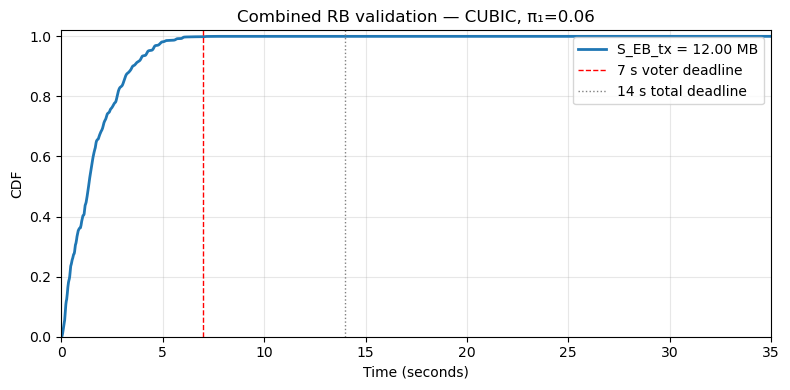

In [31]:
# === edit these and re-run the cell ============================
model = "cubic"   # 'mathis' or 'cubic'
pi1   = 0.06      # TxCache miss rate
s_kb  = 12288     # closure size in kB (use 1024 for 1 MB, 12288 for 12 MB)
# ================================================================

set_network_model(model)
set_cache_miss_rate(pi1)

info = compute_p_certified(s_kb)
cdf  = cdf_validate_rb(info["p_cert"], s_kb)
print(f"At model={model}, π₁={pi1}, S_EB_tx={s_kb/1024:.2f} MB:")
print(f"  P_validating  = {info['p_validating']:.4f}")
print(f"  P_quorum      = {info['p_quorum']:.4f}")
print(f"  P_interrupted = {info['p_interrupted']:.4f}")
print(f"  P_cert        = {info['p_cert']:.4f}")
print(f"  P(≤7s)        = {success_within(cdf, 7.0):.4f}")
print(f"  P(≤14s)       = {success_within(cdf, 14.0):.4f}")
print(f"  Q50           = {quantile_of(cdf, 0.50):.2f} s")
print(f"  Q95           = {quantile_of(cdf, 0.95):.2f} s")
print(f"  Q99           = {quantile_of(cdf, 0.99):.2f} s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TIMES, cdf, lw=2, label=f"S_EB_tx = {s_kb/1024:.2f} MB")
ax.axvline(7.0,  color="red",  ls="--", lw=1, label="7 s voter deadline")
ax.axvline(14.0, color="gray", ls=":",  lw=1, label="14 s total deadline")
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(f"Combined RB validation — {model.upper()}, π₁={pi1}")
ax.legend(); fig.tight_layout(); plt.show()

# Reset to defaults for any downstream cells.
set_network_model("mathis"); set_cache_miss_rate(1/6)


## References

- [CIP-0164 – Ouroboros Leios](https://github.com/cardano-foundation/CIPs/tree/master/CIP-0164)
- `analysis/deltaq/linear-leios/docs/report.md` – Prior ΔQ analysis
- `post-cip/apply-reapply/ReadMe.md` – Ledger apply/reapply timing measurements
- `docs/deltaq_PraosModel.pdf` – Praos ΔQ analysis
- Mathis et al. (1997), *The macroscopic behavior of the TCP congestion
  avoidance algorithm*, ACM SIGCOMM CCR.
- Ha, Rhee, Xu (2008), *CUBIC: A new TCP-friendly high-speed TCP variant*,
  ACM SIGOPS Operating Systems Review.  Standardised by RFC 8312.
- `docs/deltaq_complexity_management_strategy.pdf` – Backend complexity discussion
- `docs/Praos Performance Model.pdf` – Praos performance model (p_interrupted derivation)
